## Algoritmos supervisados

In [3]:
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
# Seaborn is a Python data visualization library based on matplotlib
import seaborn as sns
%matplotlib inline

####  0. Cargamos los datos

##### El set de datos proviene de aquí: https://www.kaggle.com/datasets/saurabhbadole/bank-customer-churn-prediction-dataset

**RowNumber**: The sequential number assigned to each row in the dataset.  
**CustomerId**: A unique identifier for each customer.  
**Surname**: The surname of the customer.  
**CreditScore**: The credit score of the customer.  
**Geography**: The geographical location of the customer (e.g., country or region).  
**Gender**: The gender of the customer.  
**Age**: The age of the customer.  
**Tenure**: The number of years the customer has been with the bank.  
**Balance**: The account balance of the customer.  
**NumOfProducts**: The number of bank products the customer has.  
**HasCrCard**: Indicates whether the customer has a credit card (binary: yes/no).  
**IsActiveMember**: Indicates whether the customer is an active member (binary: yes/no).  
**EstimatedSalary**: The estimated salary of the customer.  
**Exited**: Indicates whether the customer has exited the bank (binary: yes/no).  

In [4]:
os.getcwd()

'c:\\Users\\Oscar\\OneDrive - FM4\\Escritorio\\EVOLVE\\Data Science\\EVOLVE\\Tomas_Arteaga_ML\\Notebooks_Clase'

In [5]:
file='../Datasets/Churn_Modelling.csv'
df = pd.read_csv(file, delimiter=',', low_memory=False)
df.shape
#os.getcwd()
print(df.head())

   RowNumber  CustomerId   Surname  CreditScore Geography  Gender  Age  \
0          1    15634602  Hargrave          619    France  Female   42   
1          2    15647311      Hill          608     Spain  Female   41   
2          3    15619304      Onio          502    France  Female   42   
3          4    15701354      Boni          699    France  Female   39   
4          5    15737888  Mitchell          850     Spain  Female   43   

   Tenure    Balance  NumOfProducts  HasCrCard  IsActiveMember  \
0       2       0.00              1          1               1   
1       1   83807.86              1          0               1   
2       8  159660.80              3          1               0   
3       1       0.00              2          0               0   
4       2  125510.82              1          1               1   

   EstimatedSalary  Exited  
0        101348.88       1  
1        112542.58       0  
2        113931.57       1  
3         93826.63       0  
4         790

#### 1. Analizamos los datos

In [6]:
# Get the first five rows of DataFrame ad_data.
df.head()

,RowNumber,CustomerId,Surname,CreditScore,Geography,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited
0,1,15634602,Hargrave,619,France,Female,42,2,0.00,1,1,1,101348.88,1
1,2,15647311,Hill,608,Spain,Female,41,1,83807.86,1,0,1,112542.58,0
2,3,15619304,Onio,502,France,Female,42,8,159660.80,3,1,0,113931.57,1
3,4,15701354,Boni,699,France,Female,39,1,0.00,2,0,0,93826.63,0
4,5,15737888,Mitchell,850,Spain,Female,43,2,125510.82,1,1,1,79084.10,0


In [7]:
df.shape

(10000, 14)

In [8]:
# Get a concise summary of DataFrame ad_data.
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 14 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   RowNumber        10000 non-null  int64  
 1   CustomerId       10000 non-null  int64  
 2   Surname          10000 non-null  object 
 3   CreditScore      10000 non-null  int64  
 4   Geography        10000 non-null  object 
 5   Gender           10000 non-null  object 
 6   Age              10000 non-null  int64  
 7   Tenure           10000 non-null  int64  
 8   Balance          10000 non-null  float64
 9   NumOfProducts    10000 non-null  int64  
 10  HasCrCard        10000 non-null  int64  
 11  IsActiveMember   10000 non-null  int64  
 12  EstimatedSalary  10000 non-null  float64
 13  Exited           10000 non-null  int64  
dtypes: float64(2), int64(9), object(3)
memory usage: 1.1+ MB


In [9]:
# Get the statistical summary of the DataFrame ad_data.
df.describe()

,RowNumber,CustomerId,CreditScore,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited
count,10000.00000,1.000000e+04,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.00000,10000.000000,10000.000000,10000.000000
mean,5000.50000,1.569094e+07,650.528800,38.921800,5.012800,76485.889288,1.530200,0.70550,0.515100,100090.239881,0.203700
std,2886.89568,7.193619e+04,96.653299,10.487806,2.892174,62397.405202,0.581654,0.45584,0.499797,57510.492818,0.402769
min,1.00000,1.556570e+07,350.000000,18.000000,0.000000,0.000000,1.000000,0.00000,0.000000,11.580000,0.000000
25%,2500.75000,1.562853e+07,584.000000,32.000000,3.000000,0.000000,1.000000,0.00000,0.000000,51002.110000,0.000000
50%,5000.50000,1.569074e+07,652.000000,37.000000,5.000000,97198.540000,1.000000,1.00000,1.000000,100193.915000,0.000000
75%,7500.25000,1.575323e+07,718.000000,44.000000,7.000000,127644.240000,2.000000,1.00000,1.000000,149388.247500,0.000000
max,10000.00000,1.581569e+07,850.000000,92.000000,10.000000,250898.090000,4.000000,1.00000,1.000000,199992.480000,1.000000


#### 1.1 Chequeamos si hay nulos

In [10]:
# The isnull() method is used to check and manage NULL values in a data frame.
df.isnull().sum()

RowNumber          0
CustomerId         0
Surname            0
CreditScore        0
Geography          0
Gender             0
Age                0
Tenure             0
Balance            0
NumOfProducts      0
HasCrCard          0
IsActiveMember     0
EstimatedSalary    0
Exited             0
dtype: int64

#### 1.2 Histogramas


In [11]:
def tipo_variables(df):
    dtypes = df.dtypes
    categorical_cols = []
    numerical_cols = []
    for col, dtype in dtypes.items():
        if pd.api.types.is_numeric_dtype(dtype):
            numerical_cols.append(col)
        else:
            categorical_cols.append(col)
    return numerical_cols, categorical_cols
    
vbles = tipo_variables(df)
num_vbles =vbles[0]
cat_vbles = vbles[1]

print(cat_vbles)
print(num_vbles)

['Surname', 'Geography', 'Gender']
['RowNumber', 'CustomerId', 'CreditScore', 'Age', 'Tenure', 'Balance', 'NumOfProducts', 'HasCrCard', 'IsActiveMember', 'EstimatedSalary', 'Exited']


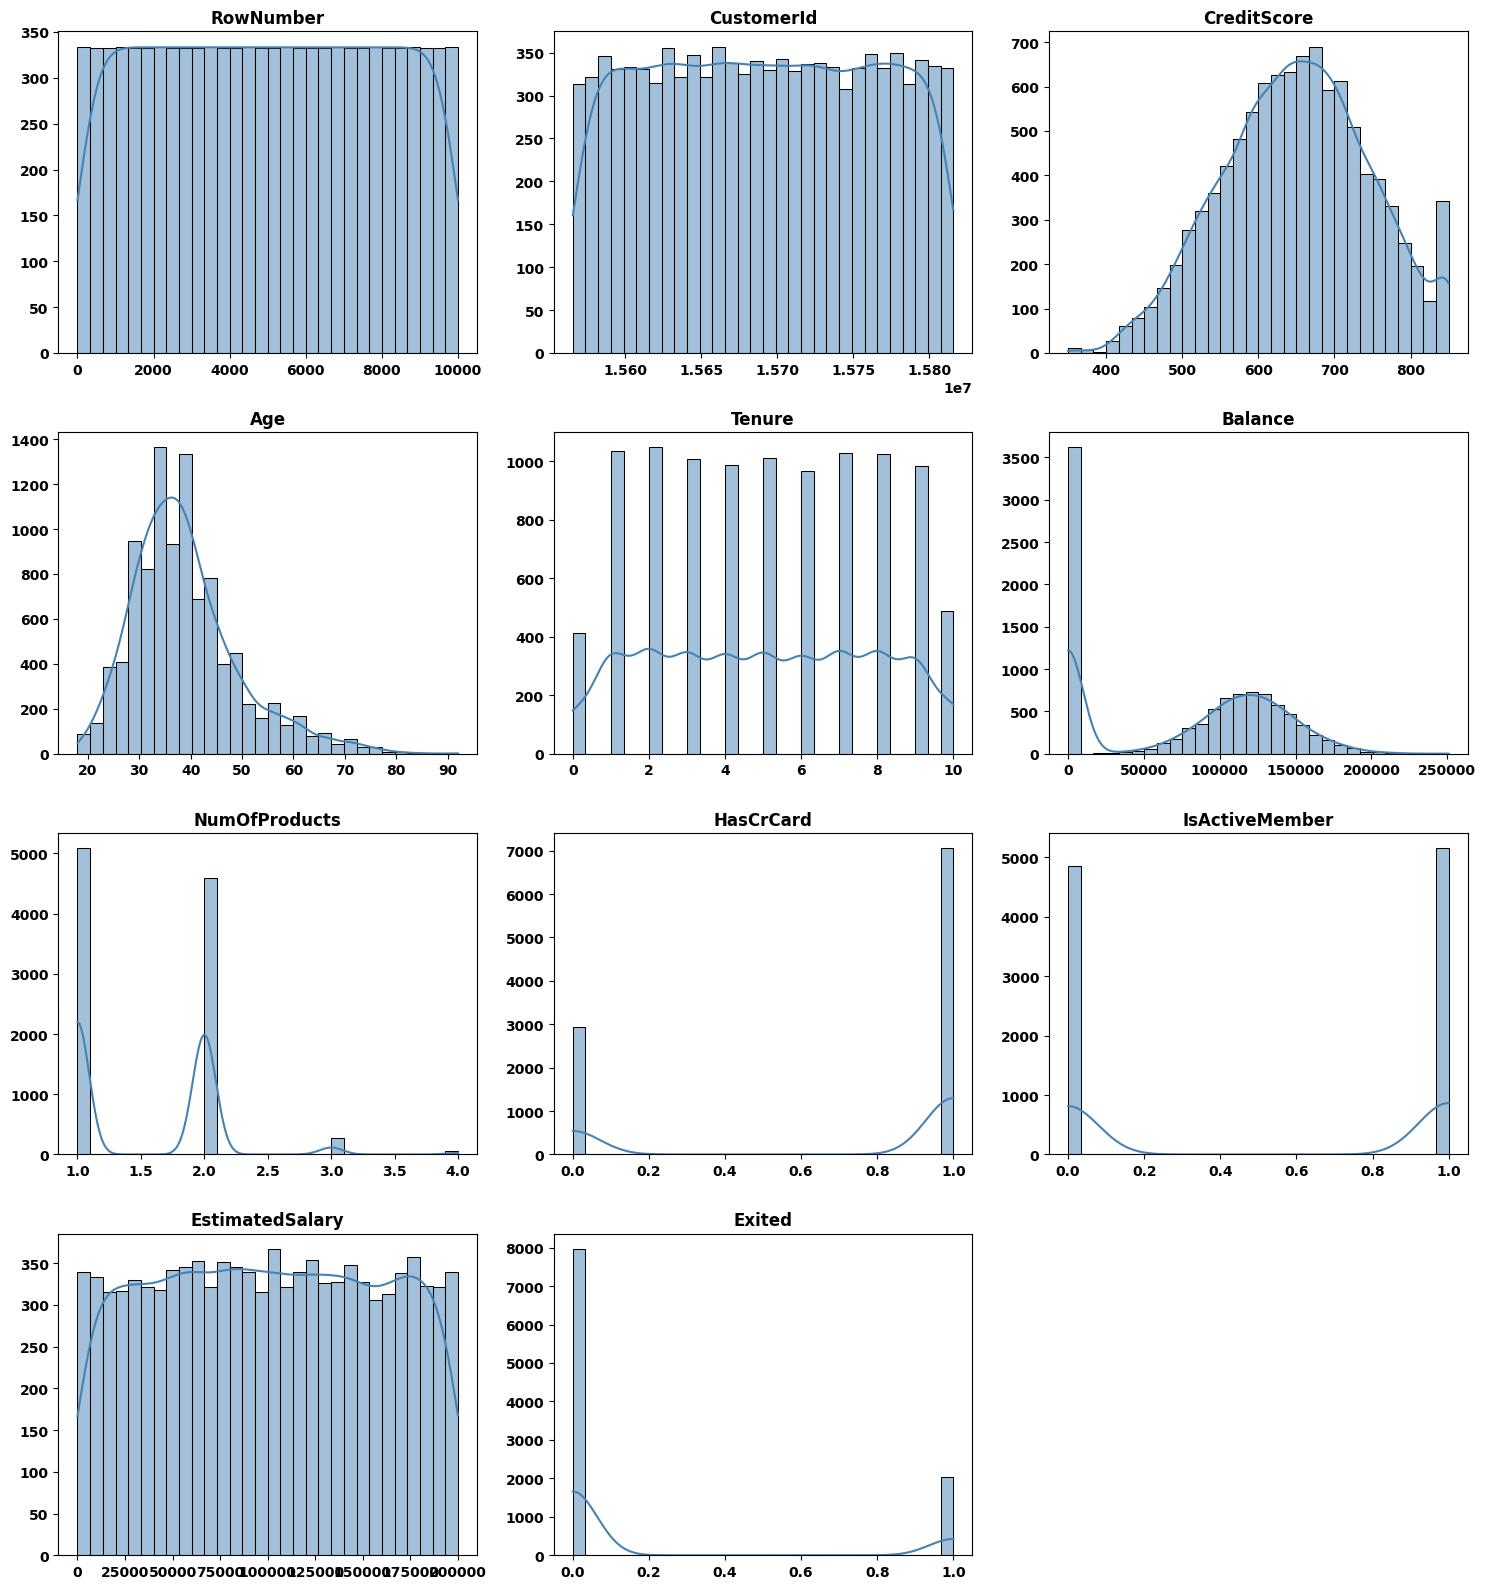

In [12]:
import matplotlib.pyplot as plt
import seaborn as sns
import math

# Supongamos que tienes un DataFrame llamado df y una lista con las variables numéricas
# num_vbles = ['edad', 'glucosa', 'presion', 'colesterol', 'peso', 'altura', ...]

n = len(num_vbles)
cols = 3  # Número de columnas del grid
rows = math.ceil(n / cols)

plt.figure(figsize=(cols*5, rows*4))  # Ajusta el tamaño según tu número de variables

for i, var in enumerate(num_vbles, 1):
    plt.subplot(rows, cols, i)
    sns.histplot(df[var], bins=30, kde=True, color='steelblue')
    plt.title(var)
    plt.xlabel('')
    plt.ylabel('')

plt.tight_layout()
plt.show()

#### 2. Transformamos las variables

In [13]:
df_original = df

#### 2.1 Eliminamos variables que no vamos a usar  
Tiene pinta de que va a ser una variable dispersa y no va a aportar al modelo

In [14]:
frecuencias = df['Surname'].value_counts()
frecuencias

Surname
Smith        32
Scott        29
Martin       29
Walker       28
Brown        26
             ..
Wells         1
Calzada       1
Gresswell     1
Aguirre       1
Morales       1
Name: count, Length: 2932, dtype: int64

In [15]:
df.shape

(10000, 14)

In [16]:
df = df.drop(columns=['Surname','RowNumber', 'CustomerId'])

In [17]:
df.shape

(10000, 11)

#### 2.1 Transformamos las variables categoricas en dummies

In [18]:
vbles = tipo_variables(df)
num_vbles =vbles[0]
cat_vbles = vbles[1]

print(cat_vbles)
print(num_vbles)

['Geography', 'Gender']
['CreditScore', 'Age', 'Tenure', 'Balance', 'NumOfProducts', 'HasCrCard', 'IsActiveMember', 'EstimatedSalary', 'Exited']


In [19]:
from sklearn.preprocessing import OneHotEncoder
# Crear un objeto OneHotEncoder
encoder = OneHotEncoder(sparse_output=False)
#El parámetro sparse_output=False asegura que la salida sea un array denso 
#(en lugar de una matriz dispersa), lo cual es más fácil de convertir en un DataFrame de pandas.
for i in cat_vbles:
    encoded_data = encoder.fit_transform(df[[i]])
    column_names = encoder.get_feature_names_out([i])
    encoded_df=pd.DataFrame(encoded_data, columns=column_names)
    df = pd.concat([df, encoded_df], axis=1)

df.head()

,CreditScore,Geography,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited,Geography_France,Geography_Germany,Geography_Spain,Gender_Female,Gender_Male
0,619,France,Female,42,2,0.00,1,1,1,101348.88,1,1.0,0.0,0.0,1.0,0.0
1,608,Spain,Female,41,1,83807.86,1,0,1,112542.58,0,0.0,0.0,1.0,1.0,0.0
2,502,France,Female,42,8,159660.80,3,1,0,113931.57,1,1.0,0.0,0.0,1.0,0.0
3,699,France,Female,39,1,0.00,2,0,0,93826.63,0,1.0,0.0,0.0,1.0,0.0
4,850,Spain,Female,43,2,125510.82,1,1,1,79084.10,0,0.0,0.0,1.0,1.0,0.0


**Eliminamos las variables categoricas una vez las hemos convertido en dummies**  

In [20]:
df = df.drop(columns=cat_vbles)

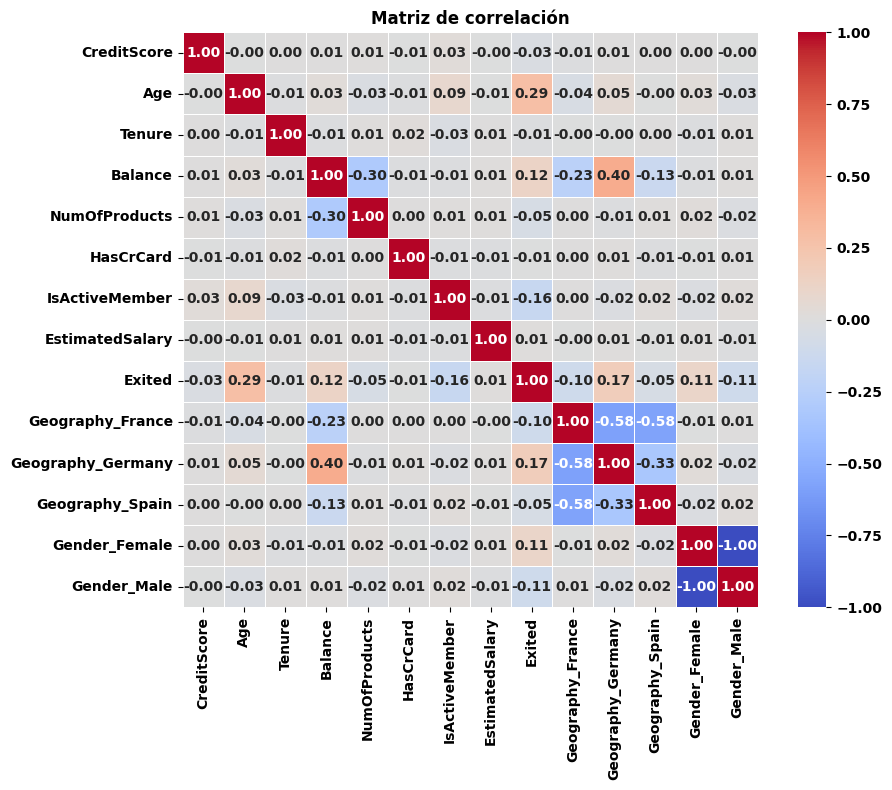

In [21]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 8))
sns.heatmap(
    df.corr(),
    annot=True,             # Muestra los coeficientes
    fmt=".2f",              # Formato de decimales
    cmap='coolwarm',         # Colormap apto para daltónicos: cividis
    square=True,
    linewidths=0.5,
    #linecolor='gray'
)
plt.title('Matriz de correlación')
plt.tight_layout()
plt.show()


#### 3. Árbol de Decision 

Los árboles de decisión se utiliza tanto para problemas de clasificación como de regresión. Funcionan dividiendo los datos en subconjuntos más pequeños organizados en forma de un árbol, donde cada nodo representa una decisión basada en una característica, cada rama corresponde a un resultado de esa decisión, y cada hoja representa una etiqueta de clase (en clasificación) o un valor de predicción (en regresión).  
Para cada nodo se selecciona la característica que mejor separa los datos según algún criterio (entropía, indice de Gini, reducción de suma de errores al cuadrado, …). Este proceso se repite de manera recursiva hasta que los datos en cada grupo sean suficientemente homogéneos o se alcance algún límite predefinido, como la profundidad máxima del árbol.  
* En Scikit Learn se aplica el algoritmo CART que tiene por objetivo reducir la impureza de los nodos.
* Permite trabajar con variables categóricas y numéricas.
* Uno de los parámetros que se define del árbol es el número de ramas.
* Tiene tendencia a sobreajustar.
* Puede ser sensible a pequeñas variaciones de los datos.
* Existen técnicas que combinan los árboles de decisión: Random Forest o Gradient Boost.
* Puede ser muy útil en exploración de datos dada su explicabilidad

In [22]:

from sklearn.model_selection import train_test_split


Next, let's define the features and label.  Briefly, feature is input; label is output. This applies to both classification and regression problems.

In [23]:
frecuencias = df['Exited'].value_counts()
frecuencias

Exited
0    7963
1    2037
Name: count, dtype: int64

In [24]:
X = df.drop(columns='Exited')
y = df['Exited']

#### 3.1 Separamos en train y test

In [25]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.33, random_state=42)

In [26]:
y_test.value_counts()

Exited
0    2657
1     643
Name: count, dtype: int64

#### 3.2 Entrenamos el modelo

In [27]:
# Logistic Regression is one of the most simple and commonly used Machine Learning algorithms for two-class classification.
# It is easy to implement and can be used as the baseline for any binary classification problem.
from sklearn.tree import DecisionTreeClassifier, plot_tree

In [28]:
dtree = DecisionTreeClassifier(max_depth=3, random_state=33)
dtree.fit(X_train,y_train)

,criterion,'gini'
,splitter,'best'
,max_depth,3
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,None
,random_state,33
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,class_weight,None


####  3.3 Evaluación del modelo

In [29]:
# Use predict() function to predict values for the testing data.
predictions = dtree.predict(X_test)
y_pred_proba = dtree.predict_proba(X_test)[:, 1]

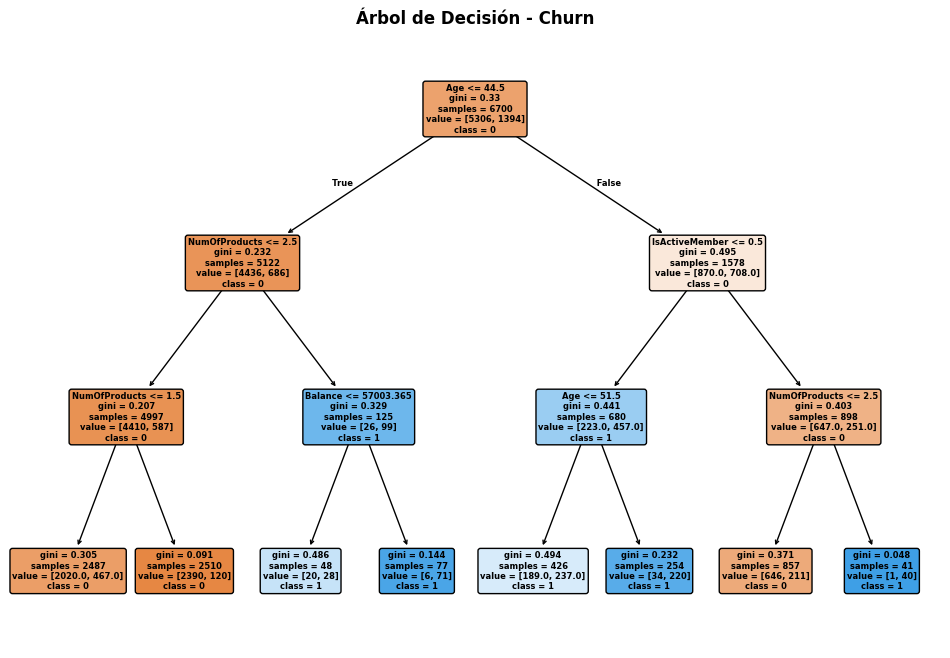

In [30]:
plt.figure(figsize=(12, 8))
plot_tree(dtree, feature_names=X.columns, class_names=['0', '1'], filled=True, rounded=True)
plt.title("Árbol de Decisión - Churn")
plt.show()

**Creamos unas funciones de evaluacion del modelo que reutilizaremos**

In [31]:
def confusion_matrix(y_test, predictions):
    from sklearn.metrics import confusion_matrix
    cm = confusion_matrix(y_test, predictions, labels=[1, 0])

    # Mostrar la matriz de confusión
    #print("Matriz de Confusión:")
    #print(cm)

    import seaborn as sns
    import matplotlib.pyplot as plt

    sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", xticklabels=["Clase 1", "Clase 0"], yticklabels=["Clase 1", "Clase 0"])
    plt.xlabel("Predicción")
    plt.ylabel("Real")
    plt.title("Matriz de Confusión")
    plt.show()
    return

def classification_report(y_test, predictions):
    from sklearn.metrics import classification_report
    report = classification_report(y_test,predictions, output_dict=True)
    # Convertir el diccionario en un DataFrame de pandas
    df_report = pd.DataFrame(report).transpose()
    print(classification_report(y_test,predictions))
    return df_report

    
def ROC_Curve (y_test, predictions):
    from sklearn.metrics import roc_auc_score
    from sklearn.metrics import roc_curve

    # Calcular ROC-AUC
    roc_auc = roc_auc_score(y_test, predictions)
    print(f"ROC-AUC: {roc_auc:.2f}")

# Calcular los valores para la curva ROC
    fpr, tpr, thresholds = roc_curve(y_test, predictions)

# Graficar la curva ROC
    plt.plot(fpr, tpr, label=f"ROC Curve (AUC = {roc_auc:.2f})")
    plt.plot([0, 1], [0, 1], 'k--', label="Random Guess")  # Línea diagonal para referencia
    plt.xlabel("False Positive Rate")
    plt.ylabel("True Positive Rate")
    plt.title("ROC Curve")
    plt.legend()
    plt.show()
    return roc_auc

    
def kappa_y_mcc(y_test, predictions):
    from sklearn.metrics import cohen_kappa_score, matthews_corrcoef
    # Calcular el índice Kappa
    kappa = cohen_kappa_score(y_test,predictions)
    mcc = matthews_corrcoef(y_test, predictions)
    print('kappa:' ,kappa, 'mcc:', mcc) 
    return kappa, mcc

def metricas(y_test, y_pred, y_pred_proba, tag):
    confusion_matrix(y_test, y_pred)
    df_report = classification_report(y_test, y_pred)
    roc_auc=ROC_Curve(y_test, y_pred_proba)
    kappa, mcc = kappa_y_mcc(y_test, y_pred)
    return tag, roc_auc, df_report.loc['1', 'precision'], df_report.loc['1', 'recall'], df_report.loc['1', 'f1-score'],  df_report.loc['accuracy', 'f1-score'], kappa, mcc


In [32]:
comparador = pd.DataFrame(columns=['Técnica', 'AUC', 'precision', 'recall','f1-score', 'accuracy','kappa', 'MCC'])
comparador

,Técnica,AUC,precision,recall,f1-score,accuracy,kappa,MCC


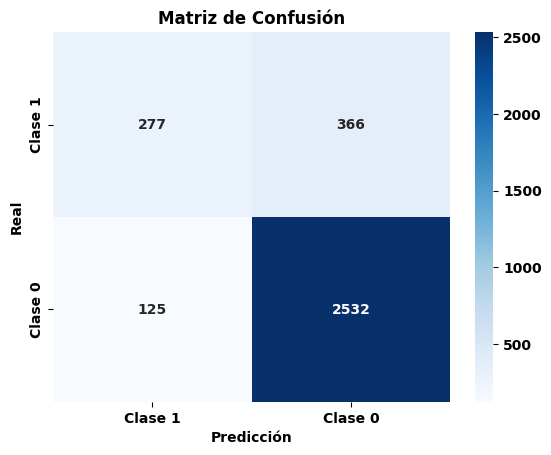

              precision    recall  f1-score   support

           0       0.87      0.95      0.91      2657
           1       0.69      0.43      0.53       643

    accuracy                           0.85      3300
   macro avg       0.78      0.69      0.72      3300
weighted avg       0.84      0.85      0.84      3300

ROC-AUC: 0.79


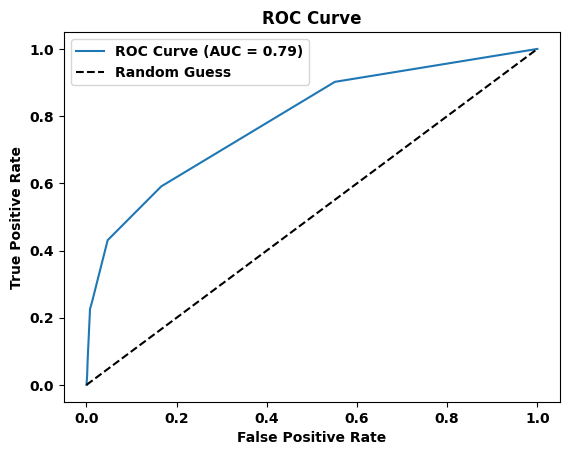

kappa: 0.4472848289356267 mcc: 0.4647129105913412


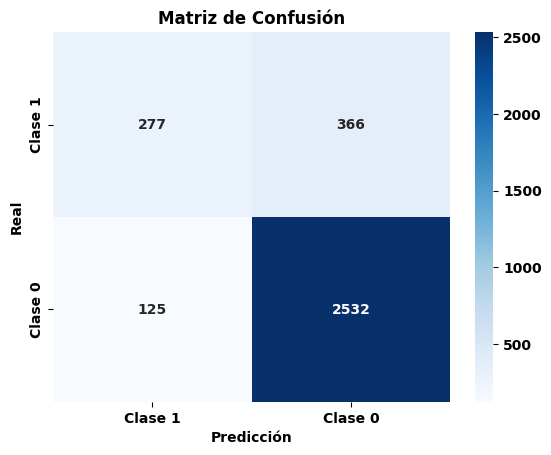

              precision    recall  f1-score   support

           0       0.87      0.95      0.91      2657
           1       0.69      0.43      0.53       643

    accuracy                           0.85      3300
   macro avg       0.78      0.69      0.72      3300
weighted avg       0.84      0.85      0.84      3300

ROC-AUC: 0.79


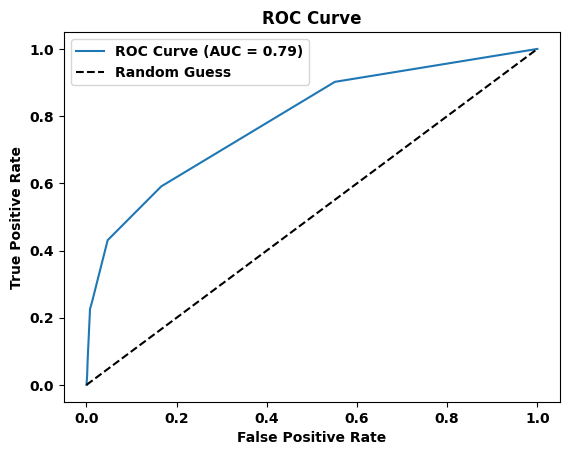

kappa: 0.4472848289356267 mcc: 0.4647129105913412


,Técnica,AUC,precision,recall,f1-score,accuracy,kappa,MCC
0,Decision Tree,0.788855,0.689055,0.430793,0.530144,0.851212,0.447285,0.464713


In [33]:
metricas(y_test, predictions, y_pred_proba, 'Decision Tree')
comparador.loc[len(comparador)] = metricas(y_test, predictions, y_pred_proba, 'Decision Tree')
comparador

#### 4. Support Vector Machine (SVM)

SVM busca el hiperplano que divida las clases con el mayor margen posible

#### 4.1 Entrenamos el modelo
Probability = True activa la función predict_proba necesaria para hacer la curva ROC

In [34]:
from sklearn.svm import SVC
svm_model = SVC(kernel='poly' , C=0.1, probability=True) 
svm_model.fit(X_train, y_train)

,C,0.1
,kernel,'poly'
,degree,3
,gamma,'scale'
,coef0,0.0
,shrinking,True
,probability,True
,tol,0.001
,cache_size,200
,class_weight,None
,verbose,False


In [35]:
# Train model using the training sets
svm_pred = svm_model.predict(X_test)
svm_pred_proba= svm_model.predict_proba(X_test)[:, 1]

#### 4.2 Evaluacion del modelo

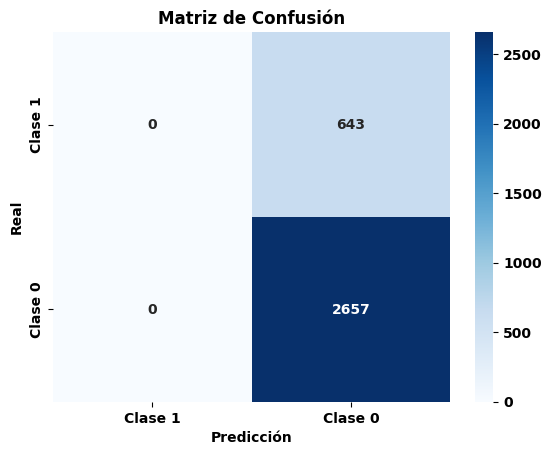

              precision    recall  f1-score   support

           0       0.81      1.00      0.89      2657
           1       0.00      0.00      0.00       643

    accuracy                           0.81      3300
   macro avg       0.40      0.50      0.45      3300
weighted avg       0.65      0.81      0.72      3300

ROC-AUC: 0.45


c:\Users\Oscar\OneDrive - FM4\Escritorio\EVOLVE\Data Science\.venv2\Lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
c:\Users\Oscar\OneDrive - FM4\Escritorio\EVOLVE\Data Science\.venv2\Lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
c:\Users\Oscar\OneDrive - FM4\Escritorio\EVOLVE\Data Science\.venv2\Lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to

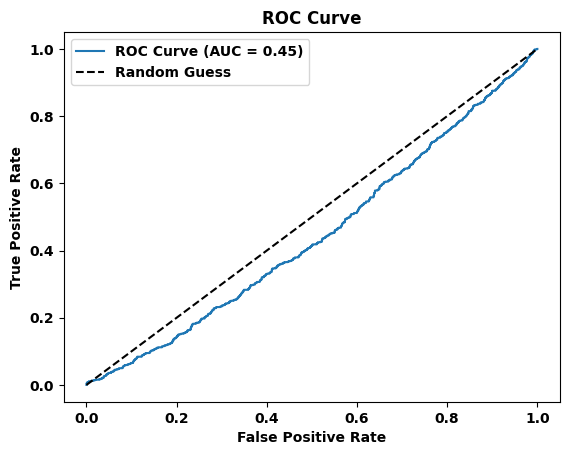

kappa: 0.0 mcc: 0.0


,Técnica,AUC,precision,recall,f1-score,accuracy,kappa,MCC
0,Decision Tree,0.788855,0.689055,0.430793,0.530144,0.851212,0.447285,0.464713
1,SVM,0.445897,0.000000,0.000000,0.000000,0.805152,0.000000,0.000000


In [36]:
#metricas(y_test, svm_pred, svm_pred_proba, 'SVM')
comparador.loc[len(comparador)] = metricas(y_test, svm_pred, svm_pred_proba, 'SVM')
comparador

**Conclusión**  
Resulta que SVM es muy sensible al escalado de datos.  
Escalamos los datos y volvemos a generar el modelo. Realmente deberíamos escalar los datos antes de aplicar cada modelo, pero alguno modelos son mas sensibles que otros al escalado.

#### 4.3 SVM con escalado de variables

In [37]:
from sklearn.preprocessing import MinMaxScaler, StandardScaler
scaler=StandardScaler()
X_Scaled = scaler.fit_transform(X)


In [38]:
X_trainS, X_testS, y_train, y_test = train_test_split(X_Scaled, y, test_size=0.33, random_state=42)

#### 4.4 Entreamos el modelo SVM con datos escalados

In [39]:
from sklearn.svm import SVC
svm_model = SVC(kernel='poly' , C=0.1, probability=True) 
svm_model.fit(X_trainS, y_train)

,C,0.1
,kernel,'poly'
,degree,3
,gamma,'scale'
,coef0,0.0
,shrinking,True
,probability,True
,tol,0.001
,cache_size,200
,class_weight,None
,verbose,False


In [40]:
svm_pred = svm_model.predict(X_testS)
svm_pred_proba= svm_model.predict_proba(X_testS)[:, 1]

#### 4.5 Evaluamos el modelo

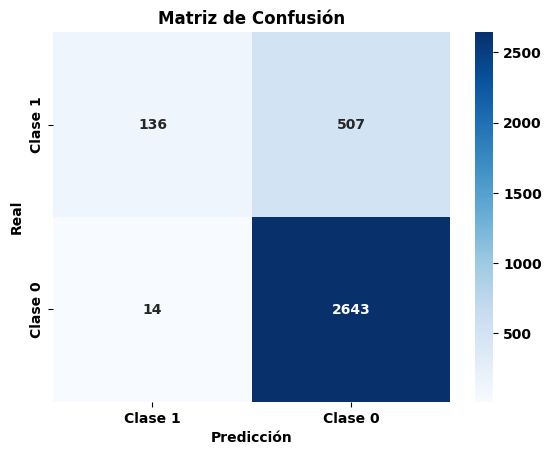

              precision    recall  f1-score   support

           0       0.84      0.99      0.91      2657
           1       0.91      0.21      0.34       643

    accuracy                           0.84      3300
   macro avg       0.87      0.60      0.63      3300
weighted avg       0.85      0.84      0.80      3300

ROC-AUC: 0.83


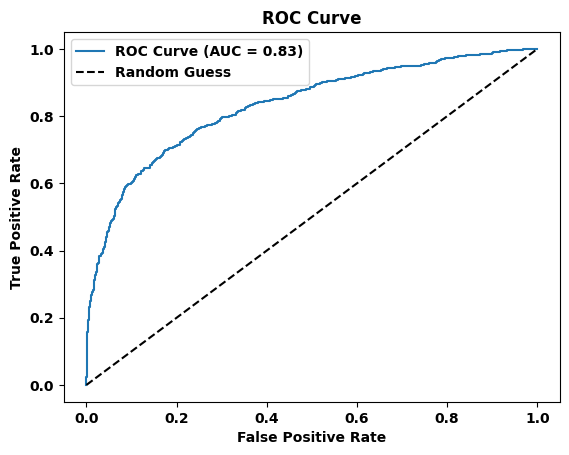

kappa: 0.2907178217821782 mcc: 0.39216795700744495


,Técnica,AUC,precision,recall,f1-score,accuracy,kappa,MCC
0,Decision Tree,0.788855,0.689055,0.430793,0.530144,0.851212,0.447285,0.464713
1,SVM,0.445897,0.000000,0.000000,0.000000,0.805152,0.000000,0.000000
2,SVM con datos escalados,0.831749,0.906667,0.211509,0.343001,0.842121,0.290718,0.392168


In [41]:
comparador.loc[len(comparador)] = metricas(y_test, svm_pred, svm_pred_proba, 'SVM con datos escalados')
comparador

#### 5. Naive Bayes

NB clasifica basandose en el teorema de bayes y asumiendo que todas las variables input son independientes entre sí

#### 5.1 Entrenamos el modelo Naive Bayes

In [42]:
from sklearn.naive_bayes import GaussianNB
gnb_model =GaussianNB(var_smoothing=1e-9)
gnb_model.fit(X_train, y_train)

,priors,None
,var_smoothing,1e-09


In [43]:
gnb_pred = gnb_model.predict(X_test)
gnb_pred_proba = gnb_model.predict_proba(X_test)[:, 1]
gnb_pred_proba

array([0.14094667, 0.15071688, 0.168011  , ..., 0.13605614, 0.51492956,
       0.32721408], shape=(3300,))

#### 5.2 Evaluamos el modelo

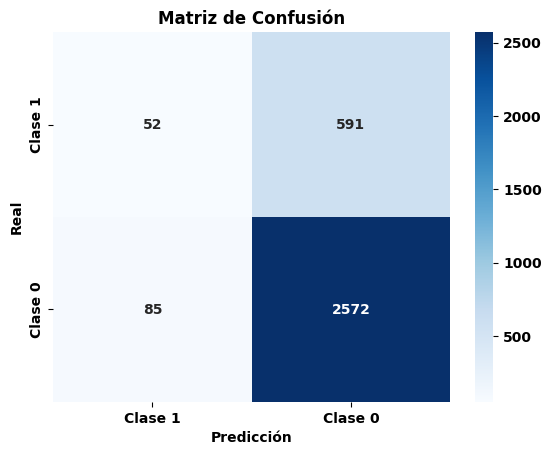

              precision    recall  f1-score   support

           0       0.81      0.97      0.88      2657
           1       0.38      0.08      0.13       643

    accuracy                           0.80      3300
   macro avg       0.60      0.52      0.51      3300
weighted avg       0.73      0.80      0.74      3300

ROC-AUC: 0.75


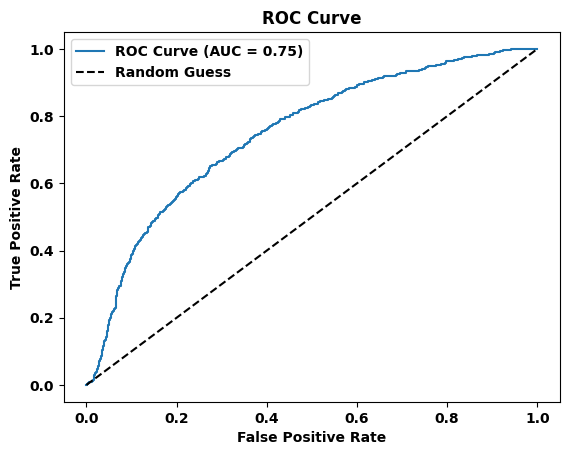

kappa: 0.06965416057432205 mcc: 0.0970559444230447


,Técnica,AUC,precision,recall,f1-score,accuracy,kappa,MCC
0,Decision Tree,0.788855,0.689055,0.430793,0.530144,0.851212,0.447285,0.464713
1,SVM,0.445897,0.000000,0.000000,0.000000,0.805152,0.000000,0.000000
2,SVM con datos escalados,0.831749,0.906667,0.211509,0.343001,0.842121,0.290718,0.392168
3,Naive Bayes,0.747892,0.379562,0.080871,0.133333,0.795152,0.069654,0.097056


In [44]:
comparador.loc[len(comparador)] = metricas(y_test, gnb_pred, gnb_pred_proba, 'Naive Bayes')
comparador

#### 6. K-Nearest Neighbors (KNN)

KNN asigna un valor de estimacion en funcion de cómo son etiquetados los valores de los k data points más próximos

#### 6.1 Entrenamos el modelo

In [45]:
from sklearn.neighbors import KNeighborsClassifier
knn_model = KNeighborsClassifier(n_neighbors=3, weights='distance', metric='euclidean')
knn_model.fit(X_trainS, y_train)


,n_neighbors,3
,weights,'distance'
,algorithm,'auto'
,leaf_size,30
,p,2
,metric,'euclidean'
,metric_params,None
,n_jobs,None


In [46]:
# Realizar predicciones
# Importante KNN requiere escalado de los datos
knn_pred = knn_model.predict(X_testS)
knn_pred_proba = knn_model.predict_proba(X_testS)[:, 1]

#### 6.2 Evaluamos el modelo

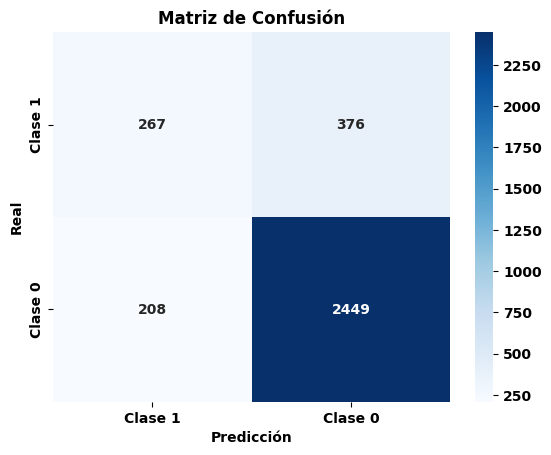

              precision    recall  f1-score   support

           0       0.87      0.92      0.89      2657
           1       0.56      0.42      0.48       643

    accuracy                           0.82      3300
   macro avg       0.71      0.67      0.69      3300
weighted avg       0.81      0.82      0.81      3300

ROC-AUC: 0.74


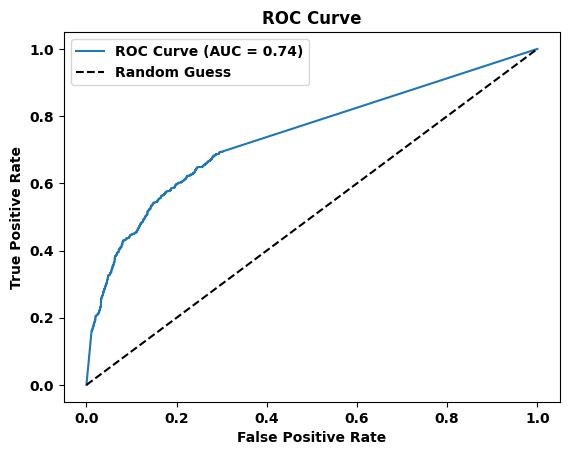

kappa: 0.3739910022575563 mcc: 0.3802069708207742


,Técnica,AUC,precision,recall,f1-score,accuracy,kappa,MCC
0,Decision Tree,0.788855,0.689055,0.430793,0.530144,0.851212,0.447285,0.464713
1,SVM,0.445897,0.000000,0.000000,0.000000,0.805152,0.000000,0.000000
2,SVM con datos escalados,0.831749,0.906667,0.211509,0.343001,0.842121,0.290718,0.392168
3,Naive Bayes,0.747892,0.379562,0.080871,0.133333,0.795152,0.069654,0.097056
4,KNN escalado,0.740626,0.562105,0.415241,0.477639,0.823030,0.373991,0.380207


In [47]:
comparador.loc[len(comparador)] = metricas(y_test, knn_pred, knn_pred_proba, 'KNN escalado')
comparador

#### 7. Random Forest

Random Forest es un algoritmo ensemble, es decir que combina otras algoritmos, es este caso arboles de decision. Selecciona muestra aleatorias de datos y de features y conn ellos genera la predicción. Se basa en el concepto de sabiduría colectiva.

#### 7.1 Entrenamos el modelo

In [48]:
# Import Random Forest Model
from sklearn.ensemble import RandomForestClassifier

# Create a Classifier
rfc = RandomForestClassifier(n_estimators=100)

# Train Random Forest Classifer
rfc.fit(X_train, y_train)

,n_estimators,100
,criterion,'gini'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,'sqrt'
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,bootstrap,True
,oob_score,False


In [49]:
# Train model using the training sets
rfc_pred = rfc.predict(X_test)
rfc_pred_proba = rfc.predict_proba(X_test)[:, 1]

#### 7.2 Evaluamos el modelo

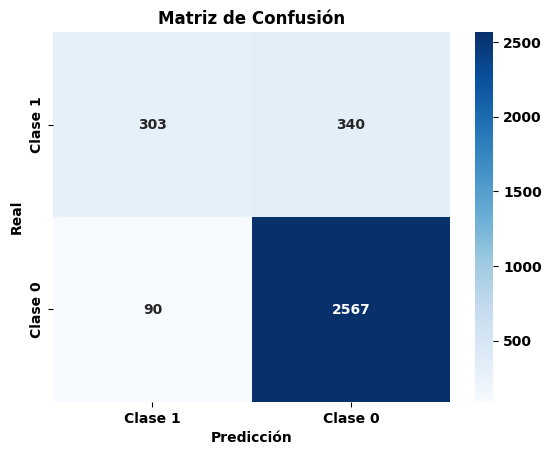

              precision    recall  f1-score   support

           0       0.88      0.97      0.92      2657
           1       0.77      0.47      0.58       643

    accuracy                           0.87      3300
   macro avg       0.83      0.72      0.75      3300
weighted avg       0.86      0.87      0.86      3300

ROC-AUC: 0.85


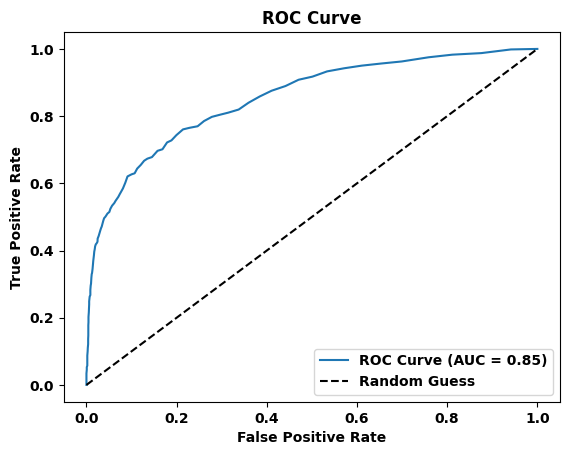

kappa: 0.51294054167602 mcc: 0.5348320070088485


,Técnica,AUC,precision,recall,f1-score,accuracy,kappa,MCC
0,Decision Tree,0.788855,0.689055,0.430793,0.530144,0.851212,0.447285,0.464713
1,SVM,0.445897,0.000000,0.000000,0.000000,0.805152,0.000000,0.000000
2,SVM con datos escalados,0.831749,0.906667,0.211509,0.343001,0.842121,0.290718,0.392168
3,Naive Bayes,0.747892,0.379562,0.080871,0.133333,0.795152,0.069654,0.097056
4,KNN escalado,0.740626,0.562105,0.415241,0.477639,0.823030,0.373991,0.380207
5,Random Forest,0.852312,0.770992,0.471229,0.584942,0.869697,0.512941,0.534832


In [50]:
comparador.loc[len(comparador)] = metricas(y_test, rfc_pred, rfc_pred_proba, 'Random Forest')
comparador

Random Forest tiene una funcion para pintar los árboles.  
Aqui pintamos 3 arboles.   
Este proceso tarda bastante  

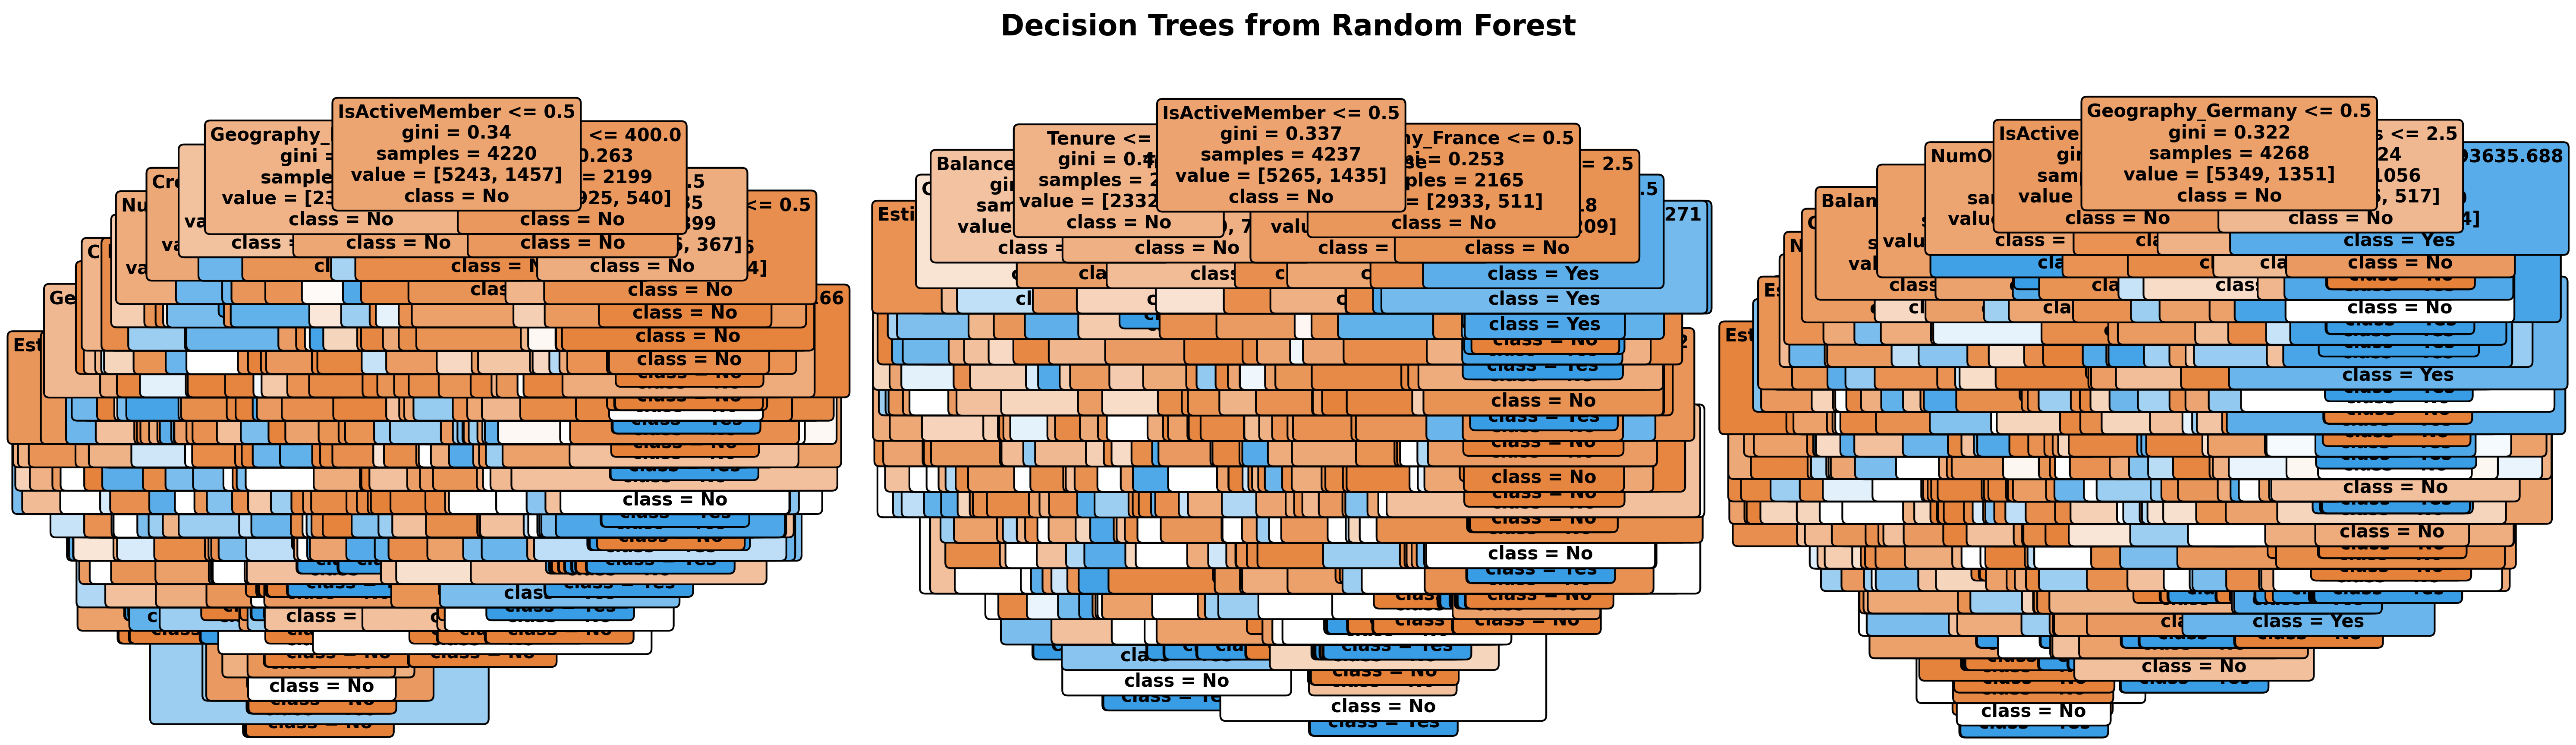

In [52]:
# Create visualizations for trees 1 and 100
# it takes some minutes 
trees_to_show = [0, 1, 99]  # Python uses 0-based indexing
feature_names = X_train.columns.tolist()
class_names = ['No', 'Yes']

# Set up the plot
fig, axes = plt.subplots(1, 3, figsize=(20, 6), dpi=300)  # Reduced height, increased DPI
fig.suptitle('Decision Trees from Random Forest', fontsize=16)

# Plot each tree
for idx, tree_idx in enumerate(trees_to_show):
    plot_tree(rfc.estimators_[tree_idx], 
              feature_names=feature_names,
              class_names=class_names,
              filled=True,
              rounded=True,
              ax=axes[idx],
              fontsize=10)  # Increased font size
    axes[idx].set_title(f'Tree {tree_idx + 1}', fontsize=12)

plt.tight_layout(rect=[0, 0.03, 1, 0.95])

#### 8. XGBoost

XGBoost es el más popular de los metodo ensemble boosting. Mejora en rapidez y lleva regularizacion para evitar el overfitting.

In [53]:
import xgboost as xgb
from xgboost import XGBClassifier

#### 8.1 Entrenamos el modelo

In [54]:
XGB_model = XGBClassifier(
    objective='multi:softmax',  # Devuelve directamente la clase predicha
    num_class=3,                # Número de clases en el problema
    max_depth=3,                # Profundidad máxima de los árboles
    learning_rate=0.1,          # Tasa de aprendizaje
    n_estimators=50,            # Número de árboles (rondas de boosting)
    seed=42                     # Semilla para reproducibilidad
)

In [55]:
XGB_model.fit(X_train, y_train)

# Realizar predicciones sobre el conjunto de prueba
xgb_pred = XGB_model.predict(X_test)
xgb_pred_proba = XGB_model.predict_proba(X_test)[:, 1]

#### 8.2 Evaluamos el modelo

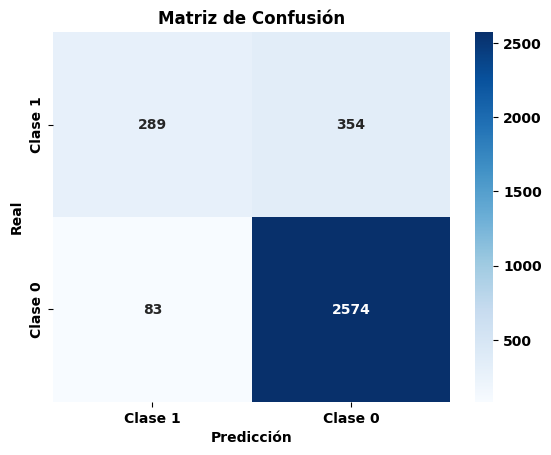

              precision    recall  f1-score   support

           0       0.88      0.97      0.92      2657
           1       0.78      0.45      0.57       643

    accuracy                           0.87      3300
   macro avg       0.83      0.71      0.75      3300
weighted avg       0.86      0.87      0.85      3300

ROC-AUC: 0.86


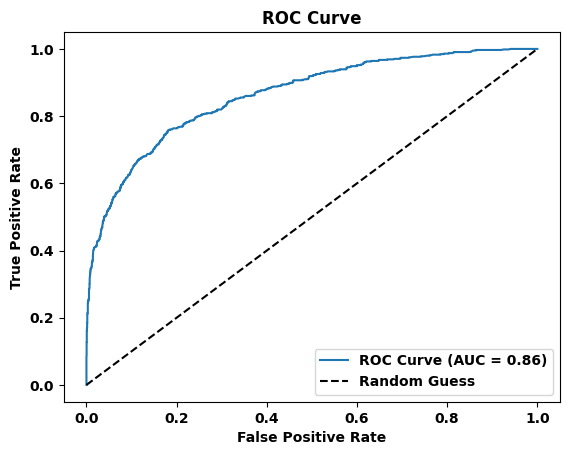

kappa: 0.49772004396908787 mcc: 0.523776964772261


,Técnica,AUC,precision,recall,f1-score,accuracy,kappa,MCC
0,Decision Tree,0.788855,0.689055,0.430793,0.530144,0.851212,0.447285,0.464713
1,SVM,0.445897,0.000000,0.000000,0.000000,0.805152,0.000000,0.000000
2,SVM con datos escalados,0.831749,0.906667,0.211509,0.343001,0.842121,0.290718,0.392168
3,Naive Bayes,0.747892,0.379562,0.080871,0.133333,0.795152,0.069654,0.097056
4,KNN escalado,0.740626,0.562105,0.415241,0.477639,0.823030,0.373991,0.380207
5,Random Forest,0.852312,0.770992,0.471229,0.584942,0.869697,0.512941,0.534832
6,xGBoost,0.862894,0.776882,0.449456,0.569458,0.867576,0.497720,0.523777


In [56]:
comparador.loc[len(comparador)] = metricas(y_test, xgb_pred, xgb_pred_proba, 'xGBoost')
comparador

#### 9 LGBM

Parecido a xgboost, LGBM utiliza el muestreo unilateral basado en gradientes (GOSS) 

In [57]:
!pip install lightgbm
import lightgbm as lgb
from lightgbm import LGBMClassifier

#### 9.1 Entrenamos el modelo

In [58]:
LGBM = LGBMClassifier(num_leaves=31, learning_rate=0.05, n_estimators=100)
LGBM.fit(X_train, y_train)

# Realizar predicciones
lgbm_pred = LGBM.predict(X_test)
lgbm_pred_proba = LGBM.predict_proba(X_test)[:, 1]


[LightGBM] [Info] Number of positive: 1394, number of negative: 5306
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.000148 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 860
[LightGBM] [Info] Number of data points in the train set: 6700, number of used features: 13
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.208060 -> initscore=-1.336661
[LightGBM] [Info] Start training from score -1.336661


#### 9.2 Evaluamos el modelo

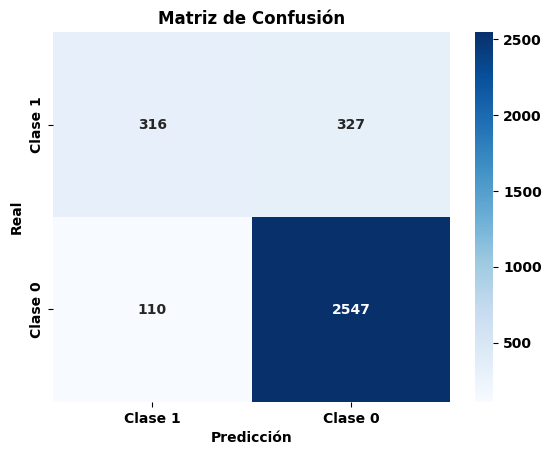

              precision    recall  f1-score   support

           0       0.89      0.96      0.92      2657
           1       0.74      0.49      0.59       643

    accuracy                           0.87      3300
   macro avg       0.81      0.73      0.76      3300
weighted avg       0.86      0.87      0.86      3300

ROC-AUC: 0.87


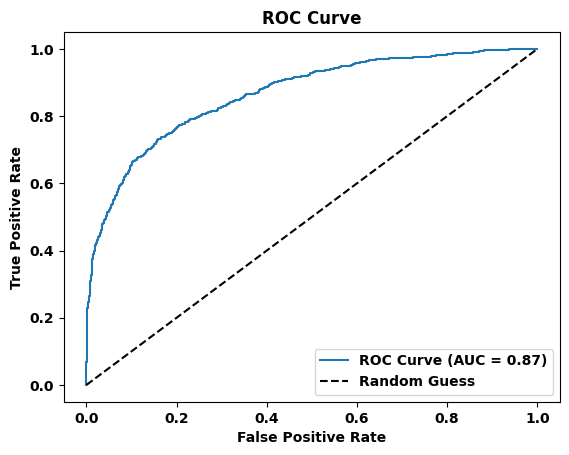

kappa: 0.5160517392740072 mcc: 0.5316309407487249


,Técnica,AUC,precision,recall,f1-score,accuracy,kappa,MCC
0,Decision Tree,0.788855,0.689055,0.430793,0.530144,0.851212,0.447285,0.464713
1,SVM,0.445897,0.000000,0.000000,0.000000,0.805152,0.000000,0.000000
2,SVM con datos escalados,0.831749,0.906667,0.211509,0.343001,0.842121,0.290718,0.392168
3,Naive Bayes,0.747892,0.379562,0.080871,0.133333,0.795152,0.069654,0.097056
4,KNN escalado,0.740626,0.562105,0.415241,0.477639,0.823030,0.373991,0.380207
5,Random Forest,0.852312,0.770992,0.471229,0.584942,0.869697,0.512941,0.534832
6,xGBoost,0.862894,0.776882,0.449456,0.569458,0.867576,0.497720,0.523777
7,LGBM,0.865205,0.741784,0.491446,0.591207,0.867576,0.516052,0.531631


In [59]:
comparador.loc[len(comparador)] = metricas(y_test, lgbm_pred, lgbm_pred_proba, 'LGBM')
comparador

#### 10. Catboost

CatBoost, no es tan popular como los anteriores. Es comparativamente más lento que LGBM y XGB, pero tiene una ventaja inigualable: puede recibir datos categóricos en forma de texto (solo necesitas indicar cuáles columnas son categóricas) y entrenar el modelo, de ahí el nombre Categorical Boost. La particularidad es que entiende los datos categóricos, mientras que otros modelos simplemente los toman como datos numéricos. No se requiere un paso de preprocesamiento para convertir el texto a numérico usando OneHotEncoder o LabelEncoding para las categorías, lo que le permite producir mejores resultados.


In [60]:

from catboost import CatBoostClassifier

#### 10.1 Entrenamos el modelo

In [61]:

# Crear y entrenar el modelo CatBoost
model = CatBoostClassifier(iterations=100, learning_rate=0.1, depth=6, verbose=0)
model.fit(X_train, y_train)

cat_pred = model.predict(X_test)
cat_pred_proba = model.predict_proba(X_test)[:, 1]

#### 10.2 Evaluamos el modelo

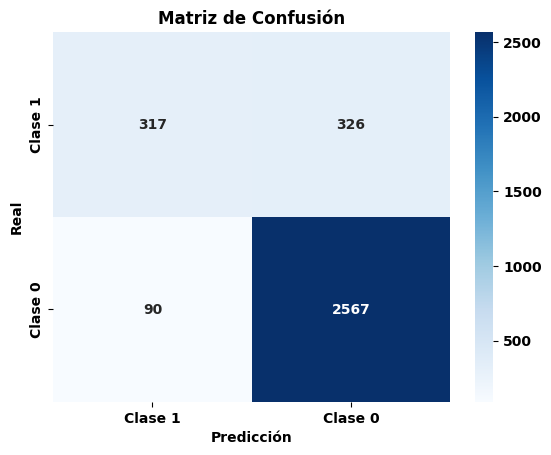

              precision    recall  f1-score   support

           0       0.89      0.97      0.93      2657
           1       0.78      0.49      0.60       643

    accuracy                           0.87      3300
   macro avg       0.83      0.73      0.76      3300
weighted avg       0.87      0.87      0.86      3300

ROC-AUC: 0.87


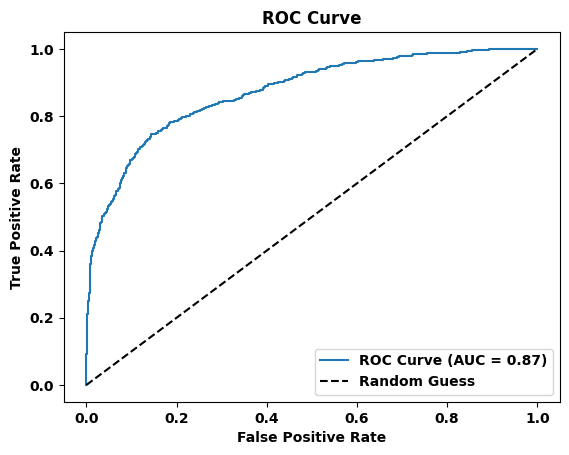

kappa: 0.5333148853106373 mcc: 0.5530499357740543


,Técnica,AUC,precision,recall,f1-score,accuracy,kappa,MCC
0,Decision Tree,0.788855,0.689055,0.430793,0.530144,0.851212,0.447285,0.464713
1,SVM,0.445897,0.000000,0.000000,0.000000,0.805152,0.000000,0.000000
2,SVM con datos escalados,0.831749,0.906667,0.211509,0.343001,0.842121,0.290718,0.392168
3,Naive Bayes,0.747892,0.379562,0.080871,0.133333,0.795152,0.069654,0.097056
4,KNN escalado,0.740626,0.562105,0.415241,0.477639,0.823030,0.373991,0.380207
5,Random Forest,0.852312,0.770992,0.471229,0.584942,0.869697,0.512941,0.534832
6,xGBoost,0.862894,0.776882,0.449456,0.569458,0.867576,0.497720,0.523777
7,LGBM,0.865205,0.741784,0.491446,0.591207,0.867576,0.516052,0.531631
8,CatBoost,0.873471,0.778870,0.493002,0.603810,0.873939,0.533315,0.553050


In [63]:
comparador.loc[len(comparador)] = metricas(y_test, cat_pred, cat_pred_proba, 'CatBoost')
comparador

#### 11. Optimizacion de hiperparámetros

Uno de los modelos que mejor funciona es LGBM. Aplicamos la optimización de hipoerparámetros y observamos si hay mejora en el rendimiento del modelo.

#### 11.1 GridSearch
**Clasificación**  

accuracy → Porcentaje de aciertos en la clasificación.  
precision → Proporción de predicciones positivas correctas.  
recall → Proporción de positivos reales correctamente detectados.  
f1 → Equilibrio entre precisión y recall.  
roc_auc → Área bajo la curva ROC (para problemas binarios).  
balanced_accuracy → Promedio de recall por clase (útil para clases desbalanceadas).  

In [65]:
from sklearn.model_selection import GridSearchCV
lgbm = LGBMClassifier()
#model = LGBMClassifier(num_leaves=31, learning_rate=0.05, n_estimators=100)


# Definir los parámetros para la búsqueda en rejilla
param_grid = {
    'num_leaves': [10, 14, 15, 16, 20, 30, 31],
    'learning_rate': [0.005, 0.01, 0.04, 0.05, 0.06, 0.1],
    'n_estimators': [100, 200, 500]
}

# Aplicar GridSearchCV
grid_search = GridSearchCV(lgbm, param_grid, cv=5, scoring='roc_auc', verbose=1, n_jobs=-1)
grid_search.fit(X_train, y_train)

# Mejor combinación de hiperparámetros encontrados
print(f"Mejores parámetros: {grid_search.best_params_}")
print(f"Mejor auc: {grid_search.best_score_:.4f}")

Fitting 5 folds for each of 126 candidates, totalling 630 fits
[LightGBM] [Info] Number of positive: 1394, number of negative: 5306
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.000172 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 860
[LightGBM] [Info] Number of data points in the train set: 6700, number of used features: 13
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.208060 -> initscore=-1.336661
[LightGBM] [Info] Start training from score -1.336661
Mejores parámetros: {'learning_rate': 0.01, 'n_estimators': 500, 'num_leaves': 10}
Mejor auc: 0.8635


In [66]:
best_model = grid_search.best_estimator_

# Aplicar el modelo a los datos de prueba
lgbm01_pred  = best_model.predict(X_test)
lgbm01_pred_proba = best_model.predict_proba(X_test)[:, 1]

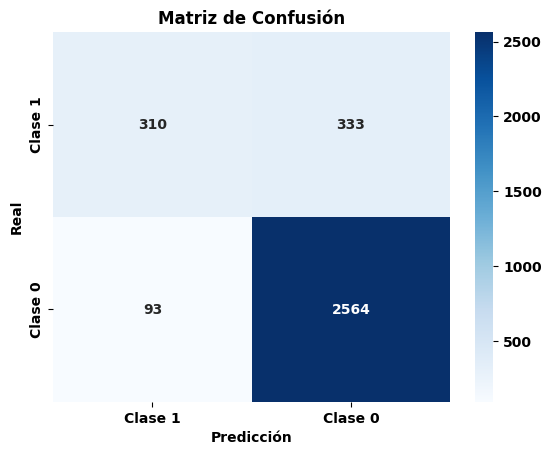

              precision    recall  f1-score   support

           0       0.89      0.96      0.92      2657
           1       0.77      0.48      0.59       643

    accuracy                           0.87      3300
   macro avg       0.83      0.72      0.76      3300
weighted avg       0.86      0.87      0.86      3300

ROC-AUC: 0.87


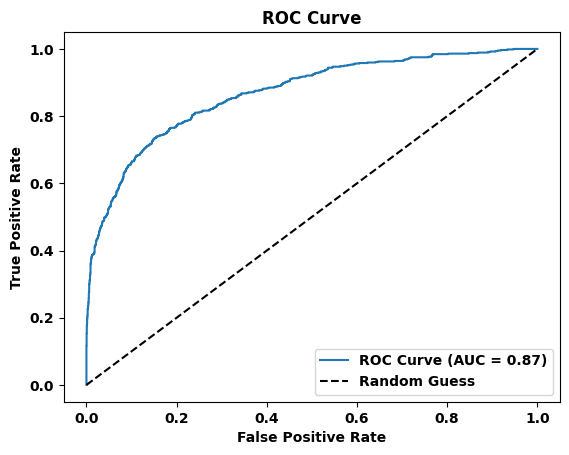

kappa: 0.5207840896772571 mcc: 0.5408688726268085


,Técnica,AUC,precision,recall,f1-score,accuracy,kappa,MCC
0,Decision Tree,0.788855,0.689055,0.430793,0.530144,0.851212,0.447285,0.464713
1,SVM,0.445897,0.000000,0.000000,0.000000,0.805152,0.000000,0.000000
2,SVM con datos escalados,0.831749,0.906667,0.211509,0.343001,0.842121,0.290718,0.392168
3,Naive Bayes,0.747892,0.379562,0.080871,0.133333,0.795152,0.069654,0.097056
4,KNN escalado,0.740626,0.562105,0.415241,0.477639,0.823030,0.373991,0.380207
5,Random Forest,0.852312,0.770992,0.471229,0.584942,0.869697,0.512941,0.534832
6,xGBoost,0.862894,0.776882,0.449456,0.569458,0.867576,0.497720,0.523777
7,LGBM,0.865205,0.741784,0.491446,0.591207,0.867576,0.516052,0.531631
8,CatBoost,0.873471,0.778870,0.493002,0.603810,0.873939,0.533315,0.553050
9,LGBM con GridSearch,0.867182,0.769231,0.482115,0.592734,0.870909,0.520784,0.540869


In [67]:
comparador.loc[len(comparador)] = metricas(y_test, lgbm01_pred, lgbm01_pred_proba, 'LGBM con GridSearch')
comparador

#### 11.2 Random Search

In [68]:
from sklearn.model_selection import RandomizedSearchCV

lgbm = LGBMClassifier()
#model = LGBMClassifier(num_leaves=31, learning_rate=0.05, n_estimators=100)


# Definir los parámetros para la búsqueda en rejilla
param_dist = {
    'num_leaves': range(10, 50),
    'learning_rate': [0.01, 0.012, 0.015, 0.018, 0.019, 0.02, 0.021, 0.025, 0.03],
    'n_estimators': range(100, 500, 50)
}


random_search = RandomizedSearchCV(lgbm, param_dist, cv=5, scoring='roc_auc', n_iter=10, verbose=1, n_jobs=-1, random_state=42)
random_search.fit(X_train, y_train)

# Mejor combinación de hiperparámetros encontrados
print(f"Mejores parámetros: {random_search.best_params_}")
print(f"Mejor precisión: {random_search.best_score_:.4f}")

Fitting 5 folds for each of 10 candidates, totalling 50 fits
[LightGBM] [Info] Number of positive: 1394, number of negative: 5306
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.000578 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 860
[LightGBM] [Info] Number of data points in the train set: 6700, number of used features: 13
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.208060 -> initscore=-1.336661
[LightGBM] [Info] Start training from score -1.336661
Mejores parámetros: {'num_leaves': 12, 'n_estimators': 350, 'learning_rate': 0.019}
Mejor precisión: 0.8623


In [69]:
best_model = random_search.best_estimator_

# Aplicar el modelo a los datos de prueba
lgbm02_pred  = best_model.predict(X_test)
lgbm02_pred_proba = best_model.predict_proba(X_test)[:, 1]

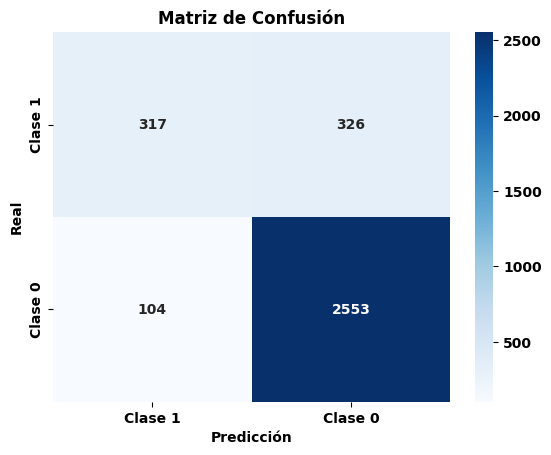

              precision    recall  f1-score   support

           0       0.89      0.96      0.92      2657
           1       0.75      0.49      0.60       643

    accuracy                           0.87      3300
   macro avg       0.82      0.73      0.76      3300
weighted avg       0.86      0.87      0.86      3300

ROC-AUC: 0.87


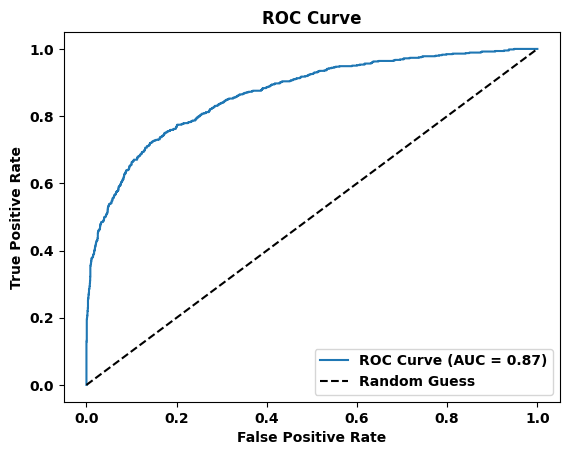

kappa: 0.522189081128186 mcc: 0.5388414205168838


,Técnica,AUC,precision,recall,f1-score,accuracy,kappa,MCC
0,Decision Tree,0.788855,0.689055,0.430793,0.530144,0.851212,0.447285,0.464713
1,SVM,0.445897,0.000000,0.000000,0.000000,0.805152,0.000000,0.000000
2,SVM con datos escalados,0.831749,0.906667,0.211509,0.343001,0.842121,0.290718,0.392168
3,Naive Bayes,0.747892,0.379562,0.080871,0.133333,0.795152,0.069654,0.097056
4,KNN escalado,0.740626,0.562105,0.415241,0.477639,0.823030,0.373991,0.380207
5,Random Forest,0.852312,0.770992,0.471229,0.584942,0.869697,0.512941,0.534832
6,xGBoost,0.862894,0.776882,0.449456,0.569458,0.867576,0.497720,0.523777
7,LGBM,0.865205,0.741784,0.491446,0.591207,0.867576,0.516052,0.531631
8,CatBoost,0.873471,0.778870,0.493002,0.603810,0.873939,0.533315,0.553050
9,LGBM con GridSearch,0.867182,0.769231,0.482115,0.592734,0.870909,0.520784,0.540869


In [70]:
comparador.loc[len(comparador)] = metricas(y_test, lgbm02_pred, lgbm02_pred_proba, 'LGBM con RandomSearch')
comparador

#### 11.3 Optuna
pip install optuna

In [71]:
!pip install optuna

# Creamos la funcion a optimizar
import optuna
import lightgbm as lgb
from lightgbm import LGBMClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import roc_auc_score


def objective(trial):
    params = {
        'objective': 'binary',
        'metric': 'auc',
        'boosting_type': trial.suggest_categorical('boosting_type', ['gbdt', 'dart', 'goss', 'rf']),
        'num_leaves': trial.suggest_int('num_leaves', 10, 50),
        'learning_rate': trial.suggest_float('learning_rate', 0.01, 0.3),
        'n_estimators': trial.suggest_int('n_estimators', 100, 500),
        'max_depth': trial.suggest_int('max_depth', 3, 15),
        'subsample': trial.suggest_float('subsample', 0.5, 1.0),
        'colsample_bytree': trial.suggest_float('colsample_bytree', 0.5, 1.0)
    }

    model = LGBMClassifier(**params)
    model.fit(X_train, y_train, eval_metric='auc')
    lgbm_pred = model.predict(X_test)
    lgbm_pred_proba = model.predict_proba(X_test)[:,1]
    auc = roc_auc_score(y_test, lgbm_pred_proba)
    
    return auc

In [72]:

# Ejecutar optimización con Optuna
study = optuna.create_study(direction='maximize', sampler=optuna.samplers.TPESampler(seed=42))
study.optimize(objective, n_trials=70)

# Mejor conjunto de hiperparámetros encontrados
print(f"Mejores parámetros: {study.best_params}")
print(f"Mejor AUC obtenido: {study.best_value:.4f}")

[I 2026-03-16 20:15:24,260] A new study created in memory with name: no-name-6696e539-6bb0-44e9-8816-45893327ba8f


[LightGBM] [Info] Number of positive: 1394, number of negative: 5306
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.000167 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 860
[LightGBM] [Info] Number of data points in the train set: 6700, number of used features: 13
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.208060 -> initscore=-1.336661
[LightGBM] [Info] Start training from score -1.336661


[I 2026-03-16 20:15:24,674] Trial 0 finished with value: 0.865318935105543 and parameters: {'boosting_type': 'dart', 'num_leaves': 16, 'learning_rate': 0.055238410897498764, 'n_estimators': 123, 'max_depth': 14, 'subsample': 0.8005575058716043, 'colsample_bytree': 0.8540362888980227}. Best is trial 0 with value: 0.865318935105543.


[LightGBM] [Info] Number of positive: 1394, number of negative: 5306
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.000192 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 860
[LightGBM] [Info] Number of data points in the train set: 6700, number of used features: 13
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.208060 -> initscore=-1.336661
[LightGBM] [Info] Start training from score -1.336661


[I 2026-03-16 20:15:25,687] Trial 1 finished with value: 0.8681150351985512 and parameters: {'boosting_type': 'dart', 'num_leaves': 17, 'learning_rate': 0.06318730785749581, 'n_estimators': 222, 'max_depth': 9, 'subsample': 0.7159725093210578, 'colsample_bytree': 0.645614570099021}. Best is trial 1 with value: 0.8681150351985512.


[LightGBM] [Info] Number of positive: 1394, number of negative: 5306
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.000127 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 860
[LightGBM] [Info] Number of data points in the train set: 6700, number of used features: 13
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.208060 -> initscore=-1.336661
[LightGBM] [Info] Start training from score -1.336661
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -

[I 2026-03-16 20:15:25,938] Trial 2 finished with value: 0.844457932946277 and parameters: {'boosting_type': 'gbdt', 'num_leaves': 28, 'learning_rate': 0.23770102880397392, 'n_estimators': 180, 'max_depth': 9, 'subsample': 0.7962072844310213, 'colsample_bytree': 0.5232252063599989}. Best is trial 1 with value: 0.8681150351985512.


[LightGBM] [Info] Number of positive: 1394, number of negative: 5306
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.000900 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 860
[LightGBM] [Info] Number of data points in the train set: 6700, number of used features: 13
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.208060 -> initscore=-1.336661
[LightGBM] [Info] Start training from score -1.336661
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -

[I 2026-03-16 20:15:26,212] Trial 3 finished with value: 0.8522213982139376 and parameters: {'boosting_type': 'rf', 'num_leaves': 49, 'learning_rate': 0.24443523095377373, 'n_estimators': 222, 'max_depth': 4, 'subsample': 0.8421165132560784, 'colsample_bytree': 0.7200762468698007}. Best is trial 1 with value: 0.8681150351985512.


[LightGBM] [Info] Number of positive: 1394, number of negative: 5306
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.000496 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 860
[LightGBM] [Info] Number of data points in the train set: 6700, number of used features: 13
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.208060 -> initscore=-1.336661
[LightGBM] [Info] Start training from score -1.336661


[I 2026-03-16 20:15:26,508] Trial 4 finished with value: 0.85986604239747 and parameters: {'boosting_type': 'rf', 'num_leaves': 20, 'learning_rate': 0.20213146246265476, 'n_estimators': 224, 'max_depth': 9, 'subsample': 0.7733551396716398, 'colsample_bytree': 0.5924272277627636}. Best is trial 1 with value: 0.8681150351985512.
[I 2026-03-16 20:15:26,704] Trial 5 finished with value: 0.8419258146707164 and parameters: {'boosting_type': 'gbdt', 'num_leaves': 34, 'learning_rate': 0.2773435281567039, 'n_estimators': 135, 'max_depth': 5, 'subsample': 0.522613644455269, 'colsample_bytree': 0.6626651653816322}. Best is trial 1 with value: 0.8681150351985512.


[LightGBM] [Info] Number of positive: 1394, number of negative: 5306
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.000541 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 860
[LightGBM] [Info] Number of data points in the train set: 6700, number of used features: 13
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.208060 -> initscore=-1.336661
[LightGBM] [Info] Start training from score -1.336661
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, b

[I 2026-03-16 20:15:27,156] Trial 6 finished with value: 0.8454968857754772 and parameters: {'boosting_type': 'goss', 'num_leaves': 21, 'learning_rate': 0.16738186411589207, 'n_estimators': 156, 'max_depth': 13, 'subsample': 0.5372753218398854, 'colsample_bytree': 0.9934434683002586}. Best is trial 1 with value: 0.8681150351985512.


[LightGBM] [Warning] Found boosting=goss. For backwards compatibility reasons, LightGBM interprets this as boosting=gbdt, data_sample_strategy=goss.To suppress this warning, set data_sample_strategy=goss instead.
[LightGBM] [Warning] Found boosting=goss. For backwards compatibility reasons, LightGBM interprets this as boosting=gbdt, data_sample_strategy=goss.To suppress this warning, set data_sample_strategy=goss instead.
[LightGBM] [Info] Number of positive: 1394, number of negative: 5306
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.000131 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 860
[LightGBM] [Info] Number of data points in the train set: 6700, number of used features: 13
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.208060 -> initscore=-1.336661
[LightGBM] [Info] Start training from score -1.336661
[LightGBM] [Warning]

[I 2026-03-16 20:15:27,585] Trial 7 finished with value: 0.844028304001695 and parameters: {'boosting_type': 'rf', 'num_leaves': 38, 'learning_rate': 0.2214120787318863, 'n_estimators': 409, 'max_depth': 3, 'subsample': 0.6792328642721364, 'colsample_bytree': 0.5579345297625649}. Best is trial 1 with value: 0.8681150351985512.


[LightGBM] [Info] Number of positive: 1394, number of negative: 5306
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.000536 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 860
[LightGBM] [Info] Number of data points in the train set: 6700, number of used features: 13
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.208060 -> initscore=-1.336661
[LightGBM] [Info] Start training from score -1.336661


[I 2026-03-16 20:15:28,091] Trial 8 finished with value: 0.8529896379820081 and parameters: {'boosting_type': 'gbdt', 'num_leaves': 22, 'learning_rate': 0.10430316338775664, 'n_estimators': 392, 'max_depth': 11, 'subsample': 0.9436063712881633, 'colsample_bytree': 0.7361074625809747}. Best is trial 1 with value: 0.8681150351985512.


[LightGBM] [Warning] Found boosting=goss. For backwards compatibility reasons, LightGBM interprets this as boosting=gbdt, data_sample_strategy=goss.To suppress this warning, set data_sample_strategy=goss instead.
[LightGBM] [Warning] Found boosting=goss. For backwards compatibility reasons, LightGBM interprets this as boosting=gbdt, data_sample_strategy=goss.To suppress this warning, set data_sample_strategy=goss instead.
[LightGBM] [Info] Number of positive: 1394, number of negative: 5306
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.000127 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 860
[LightGBM] [Info] Number of data points in the train set: 6700, number of used features: 13
[LightGBM] [Info] Using GOSS
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.208060 -> initscore=-1.336661
[LightGBM] [Info] Start training from score -

[I 2026-03-16 20:15:28,767] Trial 9 finished with value: 0.8306032774718151 and parameters: {'boosting_type': 'goss', 'num_leaves': 41, 'learning_rate': 0.1532007229456733, 'n_estimators': 309, 'max_depth': 8, 'subsample': 0.5127095633720475, 'colsample_bytree': 0.5539457134966522}. Best is trial 1 with value: 0.8681150351985512.


[LightGBM] [Info] Number of positive: 1394, number of negative: 5306
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.000200 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 860
[LightGBM] [Info] Number of data points in the train set: 6700, number of used features: 13
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.208060 -> initscore=-1.336661
[LightGBM] [Info] Start training from score -1.336661


[I 2026-03-16 20:15:29,728] Trial 10 finished with value: 0.8550356433986108 and parameters: {'boosting_type': 'dart', 'num_leaves': 10, 'learning_rate': 0.012188722601725044, 'n_estimators': 305, 'max_depth': 6, 'subsample': 0.650282411524673, 'colsample_bytree': 0.8651834476035047}. Best is trial 1 with value: 0.8681150351985512.


[LightGBM] [Info] Number of positive: 1394, number of negative: 5306
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.000804 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 860
[LightGBM] [Info] Number of data points in the train set: 6700, number of used features: 13
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.208060 -> initscore=-1.336661
[LightGBM] [Info] Start training from score -1.336661


[I 2026-03-16 20:15:29,982] Trial 11 finished with value: 0.860191776059132 and parameters: {'boosting_type': 'dart', 'num_leaves': 11, 'learning_rate': 0.04641036189349683, 'n_estimators': 111, 'max_depth': 15, 'subsample': 0.8991358530198215, 'colsample_bytree': 0.8592130094237165}. Best is trial 1 with value: 0.8681150351985512.


[LightGBM] [Info] Number of positive: 1394, number of negative: 5306
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.000439 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 860
[LightGBM] [Info] Number of data points in the train set: 6700, number of used features: 13
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.208060 -> initscore=-1.336661
[LightGBM] [Info] Start training from score -1.336661


[I 2026-03-16 20:15:30,751] Trial 12 finished with value: 0.8688613252589625 and parameters: {'boosting_type': 'dart', 'num_leaves': 16, 'learning_rate': 0.0730299033805279, 'n_estimators': 236, 'max_depth': 12, 'subsample': 0.6937971020319804, 'colsample_bytree': 0.8468694161526094}. Best is trial 12 with value: 0.8688613252589625.


[LightGBM] [Info] Number of positive: 1394, number of negative: 5306
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.000492 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 860
[LightGBM] [Info] Number of data points in the train set: 6700, number of used features: 13
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.208060 -> initscore=-1.336661
[LightGBM] [Info] Start training from score -1.336661


[I 2026-03-16 20:15:31,715] Trial 13 finished with value: 0.8659581105925778 and parameters: {'boosting_type': 'dart', 'num_leaves': 26, 'learning_rate': 0.09492524170987295, 'n_estimators': 239, 'max_depth': 12, 'subsample': 0.6719370216677879, 'colsample_bytree': 0.7939715754491159}. Best is trial 12 with value: 0.8688613252589625.


[LightGBM] [Info] Number of positive: 1394, number of negative: 5306
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.000108 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 860
[LightGBM] [Info] Number of data points in the train set: 6700, number of used features: 13
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.208060 -> initscore=-1.336661
[LightGBM] [Info] Start training from score -1.336661


[I 2026-03-16 20:15:33,817] Trial 14 finished with value: 0.8677840336070511 and parameters: {'boosting_type': 'dart', 'num_leaves': 16, 'learning_rate': 0.09106132964178913, 'n_estimators': 355, 'max_depth': 11, 'subsample': 0.6142690860932787, 'colsample_bytree': 0.6498873280606875}. Best is trial 12 with value: 0.8688613252589625.


[LightGBM] [Info] Number of positive: 1394, number of negative: 5306
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.000495 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 860
[LightGBM] [Info] Number of data points in the train set: 6700, number of used features: 13
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.208060 -> initscore=-1.336661
[LightGBM] [Info] Start training from score -1.336661


[I 2026-03-16 20:15:36,604] Trial 15 finished with value: 0.8617308895601923 and parameters: {'boosting_type': 'dart', 'num_leaves': 16, 'learning_rate': 0.1313410933270211, 'n_estimators': 466, 'max_depth': 7, 'subsample': 0.7258786920940515, 'colsample_bytree': 0.9551101245266304}. Best is trial 12 with value: 0.8688613252589625.


[LightGBM] [Info] Number of positive: 1394, number of negative: 5306
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.000470 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 860
[LightGBM] [Info] Number of data points in the train set: 6700, number of used features: 13
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.208060 -> initscore=-1.336661
[LightGBM] [Info] Start training from score -1.336661


[I 2026-03-16 20:15:37,667] Trial 16 finished with value: 0.8656364742096789 and parameters: {'boosting_type': 'dart', 'num_leaves': 32, 'learning_rate': 0.04776676770360158, 'n_estimators': 270, 'max_depth': 11, 'subsample': 0.6068520914633965, 'colsample_bytree': 0.7950108960389428}. Best is trial 12 with value: 0.8688613252589625.


[LightGBM] [Info] Number of positive: 1394, number of negative: 5306
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.000124 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 860
[LightGBM] [Info] Number of data points in the train set: 6700, number of used features: 13
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.208060 -> initscore=-1.336661
[LightGBM] [Info] Start training from score -1.336661


[I 2026-03-16 20:15:38,333] Trial 17 finished with value: 0.8682599032691016 and parameters: {'boosting_type': 'dart', 'num_leaves': 23, 'learning_rate': 0.06678583528449052, 'n_estimators': 177, 'max_depth': 10, 'subsample': 0.7189130269599776, 'colsample_bytree': 0.6375203184061919}. Best is trial 12 with value: 0.8688613252589625.


[LightGBM] [Warning] Found boosting=goss. For backwards compatibility reasons, LightGBM interprets this as boosting=gbdt, data_sample_strategy=goss.To suppress this warning, set data_sample_strategy=goss instead.
[LightGBM] [Warning] Found boosting=goss. For backwards compatibility reasons, LightGBM interprets this as boosting=gbdt, data_sample_strategy=goss.To suppress this warning, set data_sample_strategy=goss instead.
[LightGBM] [Info] Number of positive: 1394, number of negative: 5306
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.000530 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 860
[LightGBM] [Info] Number of data points in the train set: 6700, number of used features: 13
[LightGBM] [Info] Using GOSS
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.208060 -> initscore=-1.336661
[LightGBM] [Info] Start training from score -1.336661


[I 2026-03-16 20:15:38,651] Trial 18 finished with value: 0.8666362102278614 and parameters: {'boosting_type': 'goss', 'num_leaves': 25, 'learning_rate': 0.011730855366699162, 'n_estimators': 180, 'max_depth': 13, 'subsample': 0.8535972392831754, 'colsample_bytree': 0.9158181342095258}. Best is trial 12 with value: 0.8688613252589625.


[LightGBM] [Warning] Found boosting=goss. For backwards compatibility reasons, LightGBM interprets this as boosting=gbdt, data_sample_strategy=goss.To suppress this warning, set data_sample_strategy=goss instead.
[LightGBM] [Warning] Found boosting=goss. For backwards compatibility reasons, LightGBM interprets this as boosting=gbdt, data_sample_strategy=goss.To suppress this warning, set data_sample_strategy=goss instead.
[LightGBM] [Info] Number of positive: 1394, number of negative: 5306
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.000160 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 860
[LightGBM] [Info] Number of data points in the train set: 6700, number of used features: 13
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.208060 -> initscore=-1.336661
[LightGBM] [Info] Start training from score -1.336661


[I 2026-03-16 20:15:39,104] Trial 19 finished with value: 0.8694007027418404 and parameters: {'boosting_type': 'dart', 'num_leaves': 12, 'learning_rate': 0.13483110404204712, 'n_estimators': 182, 'max_depth': 10, 'subsample': 0.9903844418738923, 'colsample_bytree': 0.7030063320268963}. Best is trial 19 with value: 0.8694007027418404.


[LightGBM] [Info] Number of positive: 1394, number of negative: 5306
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.000479 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 860
[LightGBM] [Info] Number of data points in the train set: 6700, number of used features: 13
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.208060 -> initscore=-1.336661
[LightGBM] [Info] Start training from score -1.336661


[I 2026-03-16 20:15:39,729] Trial 20 finished with value: 0.8679289016776015 and parameters: {'boosting_type': 'dart', 'num_leaves': 10, 'learning_rate': 0.1336405331672873, 'n_estimators': 261, 'max_depth': 13, 'subsample': 0.9763355924424171, 'colsample_bytree': 0.790173610926365}. Best is trial 19 with value: 0.8694007027418404.


[LightGBM] [Info] Number of positive: 1394, number of negative: 5306
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.000155 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 860
[LightGBM] [Info] Number of data points in the train set: 6700, number of used features: 13
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.208060 -> initscore=-1.336661
[LightGBM] [Info] Start training from score -1.336661


[I 2026-03-16 20:15:40,220] Trial 21 finished with value: 0.8680875248982851 and parameters: {'boosting_type': 'dart', 'num_leaves': 13, 'learning_rate': 0.07645512001422947, 'n_estimators': 186, 'max_depth': 10, 'subsample': 0.7410938442370909, 'colsample_bytree': 0.6965973750404143}. Best is trial 19 with value: 0.8694007027418404.


[LightGBM] [Info] Number of positive: 1394, number of negative: 5306
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.000514 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 860
[LightGBM] [Info] Number of data points in the train set: 6700, number of used features: 13
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.208060 -> initscore=-1.336661
[LightGBM] [Info] Start training from score -1.336661


[I 2026-03-16 20:15:40,829] Trial 22 finished with value: 0.8674073766236199 and parameters: {'boosting_type': 'dart', 'num_leaves': 20, 'learning_rate': 0.1178911156076193, 'n_estimators': 191, 'max_depth': 10, 'subsample': 0.586996928262798, 'colsample_bytree': 0.6792651342220943}. Best is trial 19 with value: 0.8694007027418404.


[LightGBM] [Info] Number of positive: 1394, number of negative: 5306
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.000612 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 860
[LightGBM] [Info] Number of data points in the train set: 6700, number of used features: 13
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.208060 -> initscore=-1.336661
[LightGBM] [Info] Start training from score -1.336661


[I 2026-03-16 20:15:41,830] Trial 23 finished with value: 0.8601499252831951 and parameters: {'boosting_type': 'dart', 'num_leaves': 24, 'learning_rate': 0.17413481994603688, 'n_estimators': 273, 'max_depth': 7, 'subsample': 0.8490483200027006, 'colsample_bytree': 0.7712466044954999}. Best is trial 19 with value: 0.8694007027418404.


[LightGBM] [Info] Number of positive: 1394, number of negative: 5306
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.000180 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 860
[LightGBM] [Info] Number of data points in the train set: 6700, number of used features: 13
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.208060 -> initscore=-1.336661
[LightGBM] [Info] Start training from score -1.336661


[I 2026-03-16 20:15:42,298] Trial 24 finished with value: 0.8664181764651138 and parameters: {'boosting_type': 'dart', 'num_leaves': 14, 'learning_rate': 0.03329823281798832, 'n_estimators': 142, 'max_depth': 12, 'subsample': 0.7111463504740332, 'colsample_bytree': 0.6332395074528493}. Best is trial 19 with value: 0.8694007027418404.


[LightGBM] [Info] Number of positive: 1394, number of negative: 5306
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.000112 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 860
[LightGBM] [Info] Number of data points in the train set: 6700, number of used features: 13
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.208060 -> initscore=-1.336661
[LightGBM] [Info] Start training from score -1.336661


[I 2026-03-16 20:15:42,784] Trial 25 finished with value: 0.867572145762448 and parameters: {'boosting_type': 'dart', 'num_leaves': 19, 'learning_rate': 0.07485063136199359, 'n_estimators': 163, 'max_depth': 10, 'subsample': 0.9886744515640096, 'colsample_bytree': 0.5983663875642776}. Best is trial 19 with value: 0.8694007027418404.


[LightGBM] [Info] Number of positive: 1394, number of negative: 5306
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.000602 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 860
[LightGBM] [Info] Number of data points in the train set: 6700, number of used features: 13
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.208060 -> initscore=-1.336661
[LightGBM] [Info] Start training from score -1.336661
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, b

[I 2026-03-16 20:15:43,053] Trial 26 finished with value: 0.858306735165363 and parameters: {'boosting_type': 'gbdt', 'num_leaves': 30, 'learning_rate': 0.1449731048334305, 'n_estimators': 209, 'max_depth': 8, 'subsample': 0.6407765816216827, 'colsample_bytree': 0.820265066682815}. Best is trial 19 with value: 0.8694007027418404.
[I 2026-03-16 20:15:43,287] Trial 27 finished with value: 0.8509371939844924 and parameters: {'boosting_type': 'rf', 'num_leaves': 13, 'learning_rate': 0.18567474277692567, 'n_estimators': 253, 'max_depth': 15, 'subsample': 0.9074136202529426, 'colsample_bytree': 0.7436412751373657}. Best is trial 19 with value: 0.8694007027418404.


[LightGBM] [Info] Number of positive: 1394, number of negative: 5306
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.000510 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 860
[LightGBM] [Info] Number of data points in the train set: 6700, number of used features: 13
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.208060 -> initscore=-1.336661
[LightGBM] [Info] Start training from score -1.336661
[LightGBM] [Warning] Found boosting=goss. For backwards compatibility reasons, LightGBM interprets this as boosting=gbdt, data_sample_strategy=goss.To suppress this warning, set data_sample_strategy=goss instead.
[LightGBM] [Warning] Found boosting=goss. For backwards compatibility reasons, LightGBM interprets this as boosting=gbdt, data_sample_strategy=goss.To suppress this warning, set data_sample_strategy=goss instead.
[LightGBM] [Info] Number of positive: 1394, number of negative: 5306
[LightGBM] [Inf

[I 2026-03-16 20:15:43,727] Trial 28 finished with value: 0.8420785846360241 and parameters: {'boosting_type': 'goss', 'num_leaves': 23, 'learning_rate': 0.10535390907066136, 'n_estimators': 319, 'max_depth': 12, 'subsample': 0.5683801962171714, 'colsample_bytree': 0.8978160745858846}. Best is trial 19 with value: 0.8694007027418404.


[LightGBM] [Warning] Found boosting=goss. For backwards compatibility reasons, LightGBM interprets this as boosting=gbdt, data_sample_strategy=goss.To suppress this warning, set data_sample_strategy=goss instead.
[LightGBM] [Warning] Found boosting=goss. For backwards compatibility reasons, LightGBM interprets this as boosting=gbdt, data_sample_strategy=goss.To suppress this warning, set data_sample_strategy=goss instead.
[LightGBM] [Info] Number of positive: 1394, number of negative: 5306
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.000699 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 860
[LightGBM] [Info] Number of data points in the train set: 6700, number of used features: 13
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.208060 -> initscore=-1.336661
[LightGBM] [Info] Start training from score -1.336661


[I 2026-03-16 20:15:44,014] Trial 29 finished with value: 0.8674963461053317 and parameters: {'boosting_type': 'dart', 'num_leaves': 17, 'learning_rate': 0.11952204769693, 'n_estimators': 101, 'max_depth': 14, 'subsample': 0.7698601336896732, 'colsample_bytree': 0.7103593205588026}. Best is trial 19 with value: 0.8694007027418404.


[LightGBM] [Info] Number of positive: 1394, number of negative: 5306
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.002464 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 860
[LightGBM] [Info] Number of data points in the train set: 6700, number of used features: 13
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.208060 -> initscore=-1.336661
[LightGBM] [Info] Start training from score -1.336661


[I 2026-03-16 20:15:45,971] Trial 30 finished with value: 0.8666262596937224 and parameters: {'boosting_type': 'dart', 'num_leaves': 14, 'learning_rate': 0.03221802888621947, 'n_estimators': 341, 'max_depth': 11, 'subsample': 0.7942738580250692, 'colsample_bytree': 0.8288532787998742}. Best is trial 19 with value: 0.8694007027418404.


[LightGBM] [Info] Number of positive: 1394, number of negative: 5306
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.000070 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 860
[LightGBM] [Info] Number of data points in the train set: 6700, number of used features: 13
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.208060 -> initscore=-1.336661
[LightGBM] [Info] Start training from score -1.336661


[I 2026-03-16 20:15:46,775] Trial 31 finished with value: 0.8699740291058977 and parameters: {'boosting_type': 'dart', 'num_leaves': 17, 'learning_rate': 0.07262106715349473, 'n_estimators': 212, 'max_depth': 9, 'subsample': 0.6911826699212942, 'colsample_bytree': 0.6233129410077244}. Best is trial 31 with value: 0.8699740291058977.


[LightGBM] [Info] Number of positive: 1394, number of negative: 5306
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.000159 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 860
[LightGBM] [Info] Number of data points in the train set: 6700, number of used features: 13
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.208060 -> initscore=-1.336661
[LightGBM] [Info] Start training from score -1.336661


[I 2026-03-16 20:15:47,608] Trial 32 finished with value: 0.8694747464223439 and parameters: {'boosting_type': 'dart', 'num_leaves': 18, 'learning_rate': 0.06781641108172501, 'n_estimators': 213, 'max_depth': 8, 'subsample': 0.6949053926847758, 'colsample_bytree': 0.6159896603464166}. Best is trial 31 with value: 0.8699740291058977.


[LightGBM] [Info] Number of positive: 1394, number of negative: 5306
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.000113 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 860
[LightGBM] [Info] Number of data points in the train set: 6700, number of used features: 13
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.208060 -> initscore=-1.336661
[LightGBM] [Info] Start training from score -1.336661


[I 2026-03-16 20:15:48,290] Trial 33 finished with value: 0.8693450968157705 and parameters: {'boosting_type': 'dart', 'num_leaves': 18, 'learning_rate': 0.0793705228775121, 'n_estimators': 197, 'max_depth': 8, 'subsample': 0.6815804835101459, 'colsample_bytree': 0.6048893333502573}. Best is trial 31 with value: 0.8699740291058977.


[LightGBM] [Info] Number of positive: 1394, number of negative: 5306
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.000204 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 860
[LightGBM] [Info] Number of data points in the train set: 6700, number of used features: 13
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.208060 -> initscore=-1.336661
[LightGBM] [Info] Start training from score -1.336661


[I 2026-03-16 20:15:49,041] Trial 34 finished with value: 0.8691659872012718 and parameters: {'boosting_type': 'dart', 'num_leaves': 19, 'learning_rate': 0.09137498413109388, 'n_estimators': 205, 'max_depth': 8, 'subsample': 0.7576151711140722, 'colsample_bytree': 0.6063855175108734}. Best is trial 31 with value: 0.8699740291058977.


[LightGBM] [Info] Number of positive: 1394, number of negative: 5306
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.000342 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 860
[LightGBM] [Info] Number of data points in the train set: 6700, number of used features: 13
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.208060 -> initscore=-1.336661
[LightGBM] [Info] Start training from score -1.336661


[I 2026-03-16 20:15:50,899] Trial 35 finished with value: 0.8673904021830302 and parameters: {'boosting_type': 'dart', 'num_leaves': 28, 'learning_rate': 0.037912359859603964, 'n_estimators': 283, 'max_depth': 7, 'subsample': 0.6411450502911517, 'colsample_bytree': 0.5517483407236269}. Best is trial 31 with value: 0.8699740291058977.
[I 2026-03-16 20:15:51,119] Trial 36 finished with value: 0.8681981514248873 and parameters: {'boosting_type': 'gbdt', 'num_leaves': 18, 'learning_rate': 0.06126777527602047, 'n_estimators': 135, 'max_depth': 9, 'subsample': 0.805224699623179, 'colsample_bytree': 0.5137685088332411}. Best is trial 31 with value: 0.8699740291058977.


[LightGBM] [Info] Number of positive: 1394, number of negative: 5306
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.000171 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 860
[LightGBM] [Info] Number of data points in the train set: 6700, number of used features: 13
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.208060 -> initscore=-1.336661
[LightGBM] [Info] Start training from score -1.336661
[LightGBM] [Info] Number of positive: 1394, number of negative: 5306
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.000092 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 860
[LightGBM] [Info] Number of data points in the train set: 6700, number of used features: 13
[LightGBM] [Info] [binary:

[I 2026-03-16 20:15:51,380] Trial 37 finished with value: 0.8575581038028015 and parameters: {'boosting_type': 'rf', 'num_leaves': 13, 'learning_rate': 0.08588016954694486, 'n_estimators': 208, 'max_depth': 6, 'subsample': 0.6601508217289427, 'colsample_bytree': 0.6124948765119834}. Best is trial 31 with value: 0.8699740291058977.


[LightGBM] [Info] Number of positive: 1394, number of negative: 5306
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.001770 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 860
[LightGBM] [Info] Number of data points in the train set: 6700, number of used features: 13
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.208060 -> initscore=-1.336661
[LightGBM] [Info] Start training from score -1.336661


[I 2026-03-16 20:15:52,151] Trial 38 finished with value: 0.8659487453839765 and parameters: {'boosting_type': 'dart', 'num_leaves': 49, 'learning_rate': 0.05437521332061761, 'n_estimators': 157, 'max_depth': 8, 'subsample': 0.6938554212234794, 'colsample_bytree': 0.6772330155840276}. Best is trial 31 with value: 0.8699740291058977.


[LightGBM] [Info] Number of positive: 1394, number of negative: 5306
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.000162 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 860
[LightGBM] [Info] Number of data points in the train set: 6700, number of used features: 13
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.208060 -> initscore=-1.336661
[LightGBM] [Info] Start training from score -1.336661


[I 2026-03-16 20:15:52,427] Trial 39 finished with value: 0.8601677777120911 and parameters: {'boosting_type': 'rf', 'num_leaves': 21, 'learning_rate': 0.2666113222070211, 'n_estimators': 233, 'max_depth': 6, 'subsample': 0.6239579195798053, 'colsample_bytree': 0.5777853244552633}. Best is trial 31 with value: 0.8699740291058977.


[LightGBM] [Warning] Found boosting=goss. For backwards compatibility reasons, LightGBM interprets this as boosting=gbdt, data_sample_strategy=goss.To suppress this warning, set data_sample_strategy=goss instead.
[LightGBM] [Warning] Found boosting=goss. For backwards compatibility reasons, LightGBM interprets this as boosting=gbdt, data_sample_strategy=goss.To suppress this warning, set data_sample_strategy=goss instead.
[LightGBM] [Info] Number of positive: 1394, number of negative: 5306
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.000135 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 860
[LightGBM] [Info] Number of data points in the train set: 6700, number of used features: 13
[LightGBM] [Info] Using GOSS
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.208060 -> initscore=-1.336661
[LightGBM] [Info] Start training from score -

[I 2026-03-16 20:15:52,725] Trial 40 finished with value: 0.8519776101275366 and parameters: {'boosting_type': 'goss', 'num_leaves': 42, 'learning_rate': 0.11051525447190293, 'n_estimators': 121, 'max_depth': 9, 'subsample': 0.8045569291487136, 'colsample_bytree': 0.6244260155267024}. Best is trial 31 with value: 0.8699740291058977.


[LightGBM] [Warning] Found boosting=goss. For backwards compatibility reasons, LightGBM interprets this as boosting=gbdt, data_sample_strategy=goss.To suppress this warning, set data_sample_strategy=goss instead.
[LightGBM] [Warning] Found boosting=goss. For backwards compatibility reasons, LightGBM interprets this as boosting=gbdt, data_sample_strategy=goss.To suppress this warning, set data_sample_strategy=goss instead.
[LightGBM] [Info] Number of positive: 1394, number of negative: 5306
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.000154 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 860
[LightGBM] [Info] Number of data points in the train set: 6700, number of used features: 13
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.208060 -> initscore=-1.336661
[LightGBM] [Info] Start training from score -1.336661


[I 2026-03-16 20:15:53,382] Trial 41 finished with value: 0.8681200104656206 and parameters: {'boosting_type': 'dart', 'num_leaves': 18, 'learning_rate': 0.08807603726811233, 'n_estimators': 204, 'max_depth': 8, 'subsample': 0.7539357795274931, 'colsample_bytree': 0.5885060406693522}. Best is trial 31 with value: 0.8699740291058977.


[LightGBM] [Info] Number of positive: 1394, number of negative: 5306
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.000109 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 860
[LightGBM] [Info] Number of data points in the train set: 6700, number of used features: 13
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.208060 -> initscore=-1.336661
[LightGBM] [Info] Start training from score -1.336661


[I 2026-03-16 20:15:54,005] Trial 42 finished with value: 0.8667406908363189 and parameters: {'boosting_type': 'dart', 'num_leaves': 15, 'learning_rate': 0.13607104485369323, 'n_estimators': 219, 'max_depth': 8, 'subsample': 0.6860103256794329, 'colsample_bytree': 0.5332871064672468}. Best is trial 31 with value: 0.8699740291058977.


[LightGBM] [Info] Number of positive: 1394, number of negative: 5306
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.000146 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 860
[LightGBM] [Info] Number of data points in the train set: 6700, number of used features: 13
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.208060 -> initscore=-1.336661
[LightGBM] [Info] Start training from score -1.336661


[I 2026-03-16 20:15:54,387] Trial 43 finished with value: 0.8677664738409236 and parameters: {'boosting_type': 'dart', 'num_leaves': 12, 'learning_rate': 0.09915854655387274, 'n_estimators': 168, 'max_depth': 5, 'subsample': 0.558509036338938, 'colsample_bytree': 0.6601938328469521}. Best is trial 31 with value: 0.8699740291058977.


[LightGBM] [Info] Number of positive: 1394, number of negative: 5306
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.000111 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 860
[LightGBM] [Info] Number of data points in the train set: 6700, number of used features: 13
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.208060 -> initscore=-1.336661
[LightGBM] [Info] Start training from score -1.336661
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf


[I 2026-03-16 20:15:54,642] Trial 44 finished with value: 0.8515649556235444 and parameters: {'boosting_type': 'gbdt', 'num_leaves': 19, 'learning_rate': 0.16487122492265827, 'n_estimators': 243, 'max_depth': 9, 'subsample': 0.8854854532672785, 'colsample_bytree': 0.5669646151591655}. Best is trial 31 with value: 0.8699740291058977.


[LightGBM] [Info] Number of positive: 1394, number of negative: 5306
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.000128 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 860
[LightGBM] [Info] Number of data points in the train set: 6700, number of used features: 13
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.208060 -> initscore=-1.336661
[LightGBM] [Info] Start training from score -1.336661


[I 2026-03-16 20:15:55,375] Trial 45 finished with value: 0.8685733450944744 and parameters: {'boosting_type': 'dart', 'num_leaves': 21, 'learning_rate': 0.12372645371407036, 'n_estimators': 203, 'max_depth': 7, 'subsample': 0.9349941617495439, 'colsample_bytree': 0.6113995992615056}. Best is trial 31 with value: 0.8699740291058977.


[LightGBM] [Info] Number of positive: 1394, number of negative: 5306
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.000137 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 860
[LightGBM] [Info] Number of data points in the train set: 6700, number of used features: 13
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.208060 -> initscore=-1.336661
[LightGBM] [Info] Start training from score -1.336661


[I 2026-03-16 20:15:55,937] Trial 46 finished with value: 0.8672177311494449 and parameters: {'boosting_type': 'dart', 'num_leaves': 17, 'learning_rate': 0.07914929064860185, 'n_estimators': 192, 'max_depth': 9, 'subsample': 0.7452980298565186, 'colsample_bytree': 0.5381984496376591}. Best is trial 31 with value: 0.8699740291058977.


[LightGBM] [Info] Number of positive: 1394, number of negative: 5306
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.000202 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 860
[LightGBM] [Info] Number of data points in the train set: 6700, number of used features: 13
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.208060 -> initscore=-1.336661
[LightGBM] [Info] Start training from score -1.336661


[I 2026-03-16 20:15:56,404] Trial 47 finished with value: 0.8663877395371598 and parameters: {'boosting_type': 'dart', 'num_leaves': 26, 'learning_rate': 0.024141862862980368, 'n_estimators': 145, 'max_depth': 9, 'subsample': 0.7042159609383912, 'colsample_bytree': 0.7178388748710125}. Best is trial 31 with value: 0.8699740291058977.


[LightGBM] [Info] Number of positive: 1394, number of negative: 5306
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.000432 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 860
[LightGBM] [Info] Number of data points in the train set: 6700, number of used features: 13
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.208060 -> initscore=-1.336661
[LightGBM] [Info] Start training from score -1.336661


[I 2026-03-16 20:15:57,222] Trial 48 finished with value: 0.868022261100845 and parameters: {'boosting_type': 'dart', 'num_leaves': 15, 'learning_rate': 0.058326269330659056, 'n_estimators': 225, 'max_depth': 5, 'subsample': 0.6688297656788081, 'colsample_bytree': 0.5024866746781615}. Best is trial 31 with value: 0.8699740291058977.


[LightGBM] [Info] Number of positive: 1394, number of negative: 5306
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.001029 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 860
[LightGBM] [Info] Number of data points in the train set: 6700, number of used features: 13
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.208060 -> initscore=-1.336661
[LightGBM] [Info] Start training from score -1.336661


[I 2026-03-16 20:15:57,851] Trial 49 finished with value: 0.8638930820960039 and parameters: {'boosting_type': 'dart', 'num_leaves': 11, 'learning_rate': 0.20921366865843655, 'n_estimators': 244, 'max_depth': 8, 'subsample': 0.7297941645661415, 'colsample_bytree': 0.6820942390246268}. Best is trial 31 with value: 0.8699740291058977.


[LightGBM] [Warning] Found boosting=goss. For backwards compatibility reasons, LightGBM interprets this as boosting=gbdt, data_sample_strategy=goss.To suppress this warning, set data_sample_strategy=goss instead.
[LightGBM] [Warning] Found boosting=goss. For backwards compatibility reasons, LightGBM interprets this as boosting=gbdt, data_sample_strategy=goss.To suppress this warning, set data_sample_strategy=goss instead.
[LightGBM] [Info] Number of positive: 1394, number of negative: 5306
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.000129 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 860
[LightGBM] [Info] Number of data points in the train set: 6700, number of used features: 13
[LightGBM] [Info] Using GOSS
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.208060 -> initscore=-1.336661
[LightGBM] [Info] Start training from score -

[I 2026-03-16 20:15:58,336] Trial 50 finished with value: 0.8510235295012851 and parameters: {'boosting_type': 'goss', 'num_leaves': 22, 'learning_rate': 0.09916076425206138, 'n_estimators': 283, 'max_depth': 10, 'subsample': 0.7771580810644989, 'colsample_bytree': 0.6436367933517957}. Best is trial 31 with value: 0.8699740291058977.


[LightGBM] [Warning] Found boosting=goss. For backwards compatibility reasons, LightGBM interprets this as boosting=gbdt, data_sample_strategy=goss.To suppress this warning, set data_sample_strategy=goss instead.
[LightGBM] [Warning] Found boosting=goss. For backwards compatibility reasons, LightGBM interprets this as boosting=gbdt, data_sample_strategy=goss.To suppress this warning, set data_sample_strategy=goss instead.
[LightGBM] [Info] Number of positive: 1394, number of negative: 5306
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.000576 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 860
[LightGBM] [Info] Number of data points in the train set: 6700, number of used features: 13
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.208060 -> initscore=-1.336661
[LightGBM] [Info] Start training from score -1.336661


[I 2026-03-16 20:15:59,043] Trial 51 finished with value: 0.8696453688165477 and parameters: {'boosting_type': 'dart', 'num_leaves': 16, 'learning_rate': 0.07168978178146516, 'n_estimators': 221, 'max_depth': 7, 'subsample': 0.6897521646847777, 'colsample_bytree': 0.5978772721862957}. Best is trial 31 with value: 0.8699740291058977.


[LightGBM] [Info] Number of positive: 1394, number of negative: 5306
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.000149 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 860
[LightGBM] [Info] Number of data points in the train set: 6700, number of used features: 13
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.208060 -> initscore=-1.336661
[LightGBM] [Info] Start training from score -1.336661


[I 2026-03-16 20:15:59,728] Trial 52 finished with value: 0.8701897215664951 and parameters: {'boosting_type': 'dart', 'num_leaves': 18, 'learning_rate': 0.07117570749553895, 'n_estimators': 218, 'max_depth': 7, 'subsample': 0.6250165771810358, 'colsample_bytree': 0.5985264886461452}. Best is trial 52 with value: 0.8701897215664951.


[LightGBM] [Info] Number of positive: 1394, number of negative: 5306
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.000137 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 860
[LightGBM] [Info] Number of data points in the train set: 6700, number of used features: 13
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.208060 -> initscore=-1.336661
[LightGBM] [Info] Start training from score -1.336661


[I 2026-03-16 20:16:00,467] Trial 53 finished with value: 0.8679180731551563 and parameters: {'boosting_type': 'dart', 'num_leaves': 15, 'learning_rate': 0.04537441809634486, 'n_estimators': 224, 'max_depth': 6, 'subsample': 0.6294106571956575, 'colsample_bytree': 0.5805997394809529}. Best is trial 52 with value: 0.8701897215664951.


[LightGBM] [Info] Number of positive: 1394, number of negative: 5306
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.000401 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 860
[LightGBM] [Info] Number of data points in the train set: 6700, number of used features: 13
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.208060 -> initscore=-1.336661
[LightGBM] [Info] Start training from score -1.336661


[I 2026-03-16 20:16:00,845] Trial 54 finished with value: 0.8674585926081579 and parameters: {'boosting_type': 'dart', 'num_leaves': 10, 'learning_rate': 0.06428914062268587, 'n_estimators': 175, 'max_depth': 7, 'subsample': 0.596086050587476, 'colsample_bytree': 0.6232880574351034}. Best is trial 52 with value: 0.8701897215664951.


[LightGBM] [Info] Number of positive: 1394, number of negative: 5306
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.000211 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 860
[LightGBM] [Info] Number of data points in the train set: 6700, number of used features: 13
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.208060 -> initscore=-1.336661
[LightGBM] [Info] Start training from score -1.336661
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -

[I 2026-03-16 20:16:01,417] Trial 55 finished with value: 0.8681797136704534 and parameters: {'boosting_type': 'dart', 'num_leaves': 12, 'learning_rate': 0.2981098386423313, 'n_estimators': 254, 'max_depth': 3, 'subsample': 0.6784390465976565, 'colsample_bytree': 0.6549441055363074}. Best is trial 52 with value: 0.8701897215664951.


[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No f

[I 2026-03-16 20:16:02,245] Trial 56 finished with value: 0.8615766562810405 and parameters: {'boosting_type': 'rf', 'num_leaves': 37, 'learning_rate': 0.07215776257822988, 'n_estimators': 457, 'max_depth': 7, 'subsample': 0.6532608729566417, 'colsample_bytree': 0.5645900362920274}. Best is trial 52 with value: 0.8701897215664951.


[LightGBM] [Info] Number of positive: 1394, number of negative: 5306
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.000194 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 860
[LightGBM] [Info] Number of data points in the train set: 6700, number of used features: 13
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.208060 -> initscore=-1.336661
[LightGBM] [Info] Start training from score -1.336661


[I 2026-03-16 20:16:02,863] Trial 57 finished with value: 0.8662984773926791 and parameters: {'boosting_type': 'dart', 'num_leaves': 17, 'learning_rate': 0.022217162069508828, 'n_estimators': 195, 'max_depth': 6, 'subsample': 0.7025840459419926, 'colsample_bytree': 0.593895379895114}. Best is trial 52 with value: 0.8701897215664951.


[LightGBM] [Info] Number of positive: 1394, number of negative: 5306
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.000772 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 860
[LightGBM] [Info] Number of data points in the train set: 6700, number of used features: 13
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.208060 -> initscore=-1.336661
[LightGBM] [Info] Start training from score -1.336661
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, b

[I 2026-03-16 20:16:03,153] Trial 58 finished with value: 0.8636086138847412 and parameters: {'boosting_type': 'gbdt', 'num_leaves': 47, 'learning_rate': 0.04905472579027684, 'n_estimators': 153, 'max_depth': 9, 'subsample': 0.7278383809263419, 'colsample_bytree': 0.699451653265898}. Best is trial 52 with value: 0.8701897215664951.


[LightGBM] [Info] Number of positive: 1394, number of negative: 5306
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.000156 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 860
[LightGBM] [Info] Number of data points in the train set: 6700, number of used features: 13
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.208060 -> initscore=-1.336661
[LightGBM] [Info] Start training from score -1.336661


[I 2026-03-16 20:16:04,232] Trial 59 finished with value: 0.8677708637824555 and parameters: {'boosting_type': 'dart', 'num_leaves': 20, 'learning_rate': 0.08271064854910525, 'n_estimators': 294, 'max_depth': 7, 'subsample': 0.6763279018483946, 'colsample_bytree': 0.761179319632138}. Best is trial 52 with value: 0.8701897215664951.


[LightGBM] [Info] Number of positive: 1394, number of negative: 5306
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.000106 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 860
[LightGBM] [Info] Number of data points in the train set: 6700, number of used features: 13
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.208060 -> initscore=-1.336661
[LightGBM] [Info] Start training from score -1.336661


[I 2026-03-16 20:16:05,088] Trial 60 finished with value: 0.8668197097838919 and parameters: {'boosting_type': 'dart', 'num_leaves': 15, 'learning_rate': 0.1093319789364644, 'n_estimators': 218, 'max_depth': 10, 'subsample': 0.6248652445071161, 'colsample_bytree': 0.5446946460900379}. Best is trial 52 with value: 0.8701897215664951.


[LightGBM] [Info] Number of positive: 1394, number of negative: 5306
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.000162 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 860
[LightGBM] [Info] Number of data points in the train set: 6700, number of used features: 13
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.208060 -> initscore=-1.336661
[LightGBM] [Info] Start training from score -1.336661


[I 2026-03-16 20:16:05,626] Trial 61 finished with value: 0.8690044373529003 and parameters: {'boosting_type': 'dart', 'num_leaves': 19, 'learning_rate': 0.09380772663781246, 'n_estimators': 180, 'max_depth': 8, 'subsample': 0.5351749283230407, 'colsample_bytree': 0.6035403286220484}. Best is trial 52 with value: 0.8701897215664951.


[LightGBM] [Info] Number of positive: 1394, number of negative: 5306
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.000170 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 860
[LightGBM] [Info] Number of data points in the train set: 6700, number of used features: 13
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.208060 -> initscore=-1.336661
[LightGBM] [Info] Start training from score -1.336661


[I 2026-03-16 20:16:06,295] Trial 62 finished with value: 0.8680471374361922 and parameters: {'boosting_type': 'dart', 'num_leaves': 18, 'learning_rate': 0.07085988973986772, 'n_estimators': 208, 'max_depth': 8, 'subsample': 0.5843643988093965, 'colsample_bytree': 0.6265617407082558}. Best is trial 52 with value: 0.8701897215664951.


[LightGBM] [Info] Number of positive: 1394, number of negative: 5306
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.000150 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 860
[LightGBM] [Info] Number of data points in the train set: 6700, number of used features: 13
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.208060 -> initscore=-1.336661
[LightGBM] [Info] Start training from score -1.336661


[I 2026-03-16 20:16:06,835] Trial 63 finished with value: 0.8674261070408225 and parameters: {'boosting_type': 'dart', 'num_leaves': 16, 'learning_rate': 0.14558739851803823, 'n_estimators': 193, 'max_depth': 8, 'subsample': 0.9617433272340671, 'colsample_bytree': 0.6664252809778178}. Best is trial 52 with value: 0.8701897215664951.


[LightGBM] [Info] Number of positive: 1394, number of negative: 5306
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.000110 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 860
[LightGBM] [Info] Number of data points in the train set: 6700, number of used features: 13
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.208060 -> initscore=-1.336661
[LightGBM] [Info] Start training from score -1.336661


[I 2026-03-16 20:16:07,964] Trial 64 finished with value: 0.868798695426442 and parameters: {'boosting_type': 'dart', 'num_leaves': 22, 'learning_rate': 0.08396270636874836, 'n_estimators': 262, 'max_depth': 11, 'subsample': 0.6592227892930027, 'colsample_bytree': 0.5789337614457799}. Best is trial 52 with value: 0.8701897215664951.


[LightGBM] [Info] Number of positive: 1394, number of negative: 5306
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.000101 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 860
[LightGBM] [Info] Number of data points in the train set: 6700, number of used features: 13
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.208060 -> initscore=-1.336661
[LightGBM] [Info] Start training from score -1.336661


[I 2026-03-16 20:16:08,429] Trial 65 finished with value: 0.8684170631759413 and parameters: {'boosting_type': 'dart', 'num_leaves': 14, 'learning_rate': 0.05537444821102315, 'n_estimators': 167, 'max_depth': 7, 'subsample': 0.8269301603711676, 'colsample_bytree': 0.612125679057262}. Best is trial 52 with value: 0.8701897215664951.


[LightGBM] [Info] Number of positive: 1394, number of negative: 5306
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.000481 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 860
[LightGBM] [Info] Number of data points in the train set: 6700, number of used features: 13
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.208060 -> initscore=-1.336661
[LightGBM] [Info] Start training from score -1.336661


[I 2026-03-16 20:16:09,317] Trial 66 finished with value: 0.8670892521939465 and parameters: {'boosting_type': 'dart', 'num_leaves': 25, 'learning_rate': 0.06485043321359062, 'n_estimators': 234, 'max_depth': 9, 'subsample': 0.7120803752673897, 'colsample_bytree': 0.7315626376934906}. Best is trial 52 with value: 0.8701897215664951.
[I 2026-03-16 20:16:09,515] Trial 67 finished with value: 0.8549346747433786 and parameters: {'boosting_type': 'goss', 'num_leaves': 12, 'learning_rate': 0.1140263256543852, 'n_estimators': 133, 'max_depth': 6, 'subsample': 0.7592028969627841, 'colsample_bytree': 0.6377290666602031}. Best is trial 52 with value: 0.8701897215664951.


[LightGBM] [Warning] Found boosting=goss. For backwards compatibility reasons, LightGBM interprets this as boosting=gbdt, data_sample_strategy=goss.To suppress this warning, set data_sample_strategy=goss instead.
[LightGBM] [Warning] Found boosting=goss. For backwards compatibility reasons, LightGBM interprets this as boosting=gbdt, data_sample_strategy=goss.To suppress this warning, set data_sample_strategy=goss instead.
[LightGBM] [Info] Number of positive: 1394, number of negative: 5306
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.000147 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 860
[LightGBM] [Info] Number of data points in the train set: 6700, number of used features: 13
[LightGBM] [Info] Using GOSS
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.208060 -> initscore=-1.336661
[LightGBM] [Info] Start training from score -

[I 2026-03-16 20:16:10,285] Trial 68 finished with value: 0.8671261277028138 and parameters: {'boosting_type': 'dart', 'num_leaves': 20, 'learning_rate': 0.04057017316435726, 'n_estimators': 216, 'max_depth': 10, 'subsample': 0.6093852385236768, 'colsample_bytree': 0.5619439783151273}. Best is trial 52 with value: 0.8701897215664951.


[LightGBM] [Info] Number of positive: 1394, number of negative: 5306
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.000111 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 860
[LightGBM] [Info] Number of data points in the train set: 6700, number of used features: 13
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.208060 -> initscore=-1.336661
[LightGBM] [Info] Start training from score -1.336661


[I 2026-03-16 20:16:10,825] Trial 69 finished with value: 0.8688174258436443 and parameters: {'boosting_type': 'dart', 'num_leaves': 17, 'learning_rate': 0.09256924326739134, 'n_estimators': 188, 'max_depth': 8, 'subsample': 0.735910407858539, 'colsample_bytree': 0.5956576795030252}. Best is trial 52 with value: 0.8701897215664951.


Mejores parámetros: {'boosting_type': 'dart', 'num_leaves': 18, 'learning_rate': 0.07117570749553895, 'n_estimators': 218, 'max_depth': 7, 'subsample': 0.6250165771810358, 'colsample_bytree': 0.5985264886461452}
Mejor AUC obtenido: 0.8702


In [73]:
best_params = study.best_params
best_model = LGBMClassifier(**best_params)
best_model.fit(X_train, y_train)
lgbm03_pred  = best_model.predict(X_test)
lgbm03_pred_proba = best_model.predict_proba(X_test)[:, 1]

[LightGBM] [Info] Number of positive: 1394, number of negative: 5306
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.001173 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 860
[LightGBM] [Info] Number of data points in the train set: 6700, number of used features: 13
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.208060 -> initscore=-1.336661
[LightGBM] [Info] Start training from score -1.336661


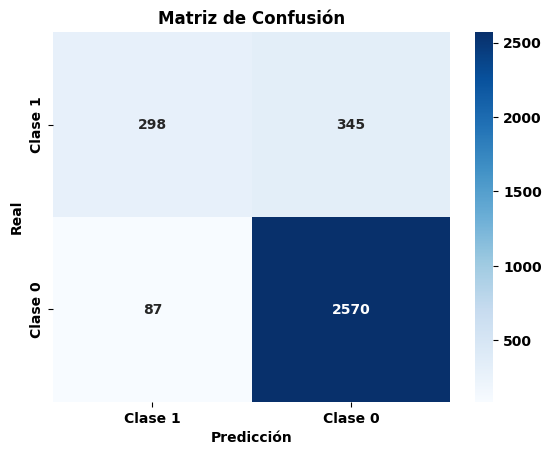

              precision    recall  f1-score   support

           0       0.88      0.97      0.92      2657
           1       0.77      0.46      0.58       643

    accuracy                           0.87      3300
   macro avg       0.83      0.72      0.75      3300
weighted avg       0.86      0.87      0.86      3300

ROC-AUC: 0.87


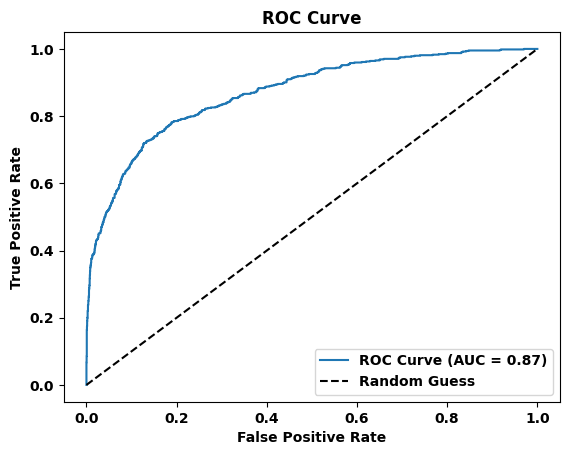

kappa: 0.5079539845855956 mcc: 0.5314169901007924


,Técnica,AUC,precision,recall,f1-score,accuracy,kappa,MCC
0,Decision Tree,0.788855,0.689055,0.430793,0.530144,0.851212,0.447285,0.464713
1,SVM,0.445897,0.000000,0.000000,0.000000,0.805152,0.000000,0.000000
2,SVM con datos escalados,0.831749,0.906667,0.211509,0.343001,0.842121,0.290718,0.392168
3,Naive Bayes,0.747892,0.379562,0.080871,0.133333,0.795152,0.069654,0.097056
4,KNN escalado,0.740626,0.562105,0.415241,0.477639,0.823030,0.373991,0.380207
5,Random Forest,0.852312,0.770992,0.471229,0.584942,0.869697,0.512941,0.534832
6,xGBoost,0.862894,0.776882,0.449456,0.569458,0.867576,0.497720,0.523777
7,LGBM,0.865205,0.741784,0.491446,0.591207,0.867576,0.516052,0.531631
8,CatBoost,0.873471,0.778870,0.493002,0.603810,0.873939,0.533315,0.553050
9,LGBM con GridSearch,0.867182,0.769231,0.482115,0.592734,0.870909,0.520784,0.540869


In [74]:
comparador.loc[len(comparador)] = metricas(y_test, lgbm03_pred, lgbm03_pred_proba, 'LGBM con Optuna')
comparador

#### 11.4  Optimizamos kappa
Estos metodos de optimización de los hiperparámetros permite optimizar otras métricas, por ejemplo kappa

In [75]:
# Creamos la funcion a optimizar
import optuna
import lightgbm as lgb
from lightgbm import LGBMClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import roc_auc_score
from sklearn.metrics import cohen_kappa_score, matthews_corrcoef

def objective(trial):
    params = {
        'objective': 'binary',
        'metric': 'auc',
        'boosting_type': trial.suggest_categorical('boosting_type', ['gbdt', 'dart', 'goss', 'rf']),
        'num_leaves': trial.suggest_int('num_leaves', 10, 50),
        'learning_rate': trial.suggest_float('learning_rate', 0.01, 0.3),
        'n_estimators': trial.suggest_int('n_estimators', 100, 500),
        'max_depth': trial.suggest_int('max_depth', 3, 15),
        'subsample': trial.suggest_float('subsample', 0.5, 1.0),
        'colsample_bytree': trial.suggest_float('colsample_bytree', 0.5, 1.0)
    }

    model = LGBMClassifier(**params)
    model.fit(X_train, y_train, eval_metric='auc')
    lgbm_pred = model.predict(X_test)
    #lgbm_pred_proba = model.predict_proba(X_test)[:,1]
    #auc = roc_auc_score(y_test, lgbm_pred_proba)
    kappa = cohen_kappa_score(y_test,lgbm_pred)
    return kappa

In [76]:
# Ejecutar optimización con Optuna
study = optuna.create_study(direction='maximize', sampler=optuna.samplers.TPESampler(seed=42))
study.optimize(objective, n_trials=100)

# Mejor conjunto de hiperparámetros encontrados
print(f"Mejores parámetros: {study.best_params}")
print(f"Mejor AUC obtenido: {study.best_value:.4f}")

[I 2026-03-16 20:16:11,983] A new study created in memory with name: no-name-24e21979-1e89-4242-b19e-49d66d2acfe0


[LightGBM] [Info] Number of positive: 1394, number of negative: 5306
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.000416 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 860
[LightGBM] [Info] Number of data points in the train set: 6700, number of used features: 13
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.208060 -> initscore=-1.336661
[LightGBM] [Info] Start training from score -1.336661


[I 2026-03-16 20:16:12,232] Trial 0 finished with value: 0.5173396030203012 and parameters: {'boosting_type': 'dart', 'num_leaves': 16, 'learning_rate': 0.055238410897498764, 'n_estimators': 123, 'max_depth': 14, 'subsample': 0.8005575058716043, 'colsample_bytree': 0.8540362888980227}. Best is trial 0 with value: 0.5173396030203012.


[LightGBM] [Info] Number of positive: 1394, number of negative: 5306
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.000100 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 860
[LightGBM] [Info] Number of data points in the train set: 6700, number of used features: 13
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.208060 -> initscore=-1.336661
[LightGBM] [Info] Start training from score -1.336661


[I 2026-03-16 20:16:12,855] Trial 1 finished with value: 0.512387835769385 and parameters: {'boosting_type': 'dart', 'num_leaves': 17, 'learning_rate': 0.06318730785749581, 'n_estimators': 222, 'max_depth': 9, 'subsample': 0.7159725093210578, 'colsample_bytree': 0.645614570099021}. Best is trial 0 with value: 0.5173396030203012.


[LightGBM] [Info] Number of positive: 1394, number of negative: 5306
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.000132 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 860
[LightGBM] [Info] Number of data points in the train set: 6700, number of used features: 13
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.208060 -> initscore=-1.336661
[LightGBM] [Info] Start training from score -1.336661
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -

[I 2026-03-16 20:16:13,072] Trial 2 finished with value: 0.49934770027563335 and parameters: {'boosting_type': 'gbdt', 'num_leaves': 28, 'learning_rate': 0.23770102880397392, 'n_estimators': 180, 'max_depth': 9, 'subsample': 0.7962072844310213, 'colsample_bytree': 0.5232252063599989}. Best is trial 0 with value: 0.5173396030203012.


[LightGBM] [Info] Number of positive: 1394, number of negative: 5306
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.000427 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 860
[LightGBM] [Info] Number of data points in the train set: 6700, number of used features: 13
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.208060 -> initscore=-1.336661
[LightGBM] [Info] Start training from score -1.336661
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, b

[I 2026-03-16 20:16:13,304] Trial 3 finished with value: 0.47737815211604584 and parameters: {'boosting_type': 'rf', 'num_leaves': 49, 'learning_rate': 0.24443523095377373, 'n_estimators': 222, 'max_depth': 4, 'subsample': 0.8421165132560784, 'colsample_bytree': 0.7200762468698007}. Best is trial 0 with value: 0.5173396030203012.


[LightGBM] [Info] Number of positive: 1394, number of negative: 5306
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.000108 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 860
[LightGBM] [Info] Number of data points in the train set: 6700, number of used features: 13
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.208060 -> initscore=-1.336661
[LightGBM] [Info] Start training from score -1.336661


[I 2026-03-16 20:16:13,564] Trial 4 finished with value: 0.4841830175556914 and parameters: {'boosting_type': 'rf', 'num_leaves': 20, 'learning_rate': 0.20213146246265476, 'n_estimators': 224, 'max_depth': 9, 'subsample': 0.7733551396716398, 'colsample_bytree': 0.5924272277627636}. Best is trial 0 with value: 0.5173396030203012.
[I 2026-03-16 20:16:13,701] Trial 5 finished with value: 0.5125275495793951 and parameters: {'boosting_type': 'gbdt', 'num_leaves': 34, 'learning_rate': 0.2773435281567039, 'n_estimators': 135, 'max_depth': 5, 'subsample': 0.522613644455269, 'colsample_bytree': 0.6626651653816322}. Best is trial 0 with value: 0.5173396030203012.


[LightGBM] [Info] Number of positive: 1394, number of negative: 5306
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.000151 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 860
[LightGBM] [Info] Number of data points in the train set: 6700, number of used features: 13
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.208060 -> initscore=-1.336661
[LightGBM] [Info] Start training from score -1.336661
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -

[I 2026-03-16 20:16:13,913] Trial 6 finished with value: 0.49239914901930437 and parameters: {'boosting_type': 'goss', 'num_leaves': 21, 'learning_rate': 0.16738186411589207, 'n_estimators': 156, 'max_depth': 13, 'subsample': 0.5372753218398854, 'colsample_bytree': 0.9934434683002586}. Best is trial 0 with value: 0.5173396030203012.


[LightGBM] [Warning] Found boosting=goss. For backwards compatibility reasons, LightGBM interprets this as boosting=gbdt, data_sample_strategy=goss.To suppress this warning, set data_sample_strategy=goss instead.
[LightGBM] [Info] Number of positive: 1394, number of negative: 5306
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.000108 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 860
[LightGBM] [Info] Number of data points in the train set: 6700, number of used features: 13
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.208060 -> initscore=-1.336661
[LightGBM] [Info] Start training from score -1.336661
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGB

[I 2026-03-16 20:16:14,116] Trial 7 finished with value: 0.39552888041536705 and parameters: {'boosting_type': 'rf', 'num_leaves': 38, 'learning_rate': 0.2214120787318863, 'n_estimators': 409, 'max_depth': 3, 'subsample': 0.6792328642721364, 'colsample_bytree': 0.5579345297625649}. Best is trial 0 with value: 0.5173396030203012.


[LightGBM] [Info] Number of positive: 1394, number of negative: 5306
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.000527 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 860
[LightGBM] [Info] Number of data points in the train set: 6700, number of used features: 13
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.208060 -> initscore=-1.336661
[LightGBM] [Info] Start training from score -1.336661


[I 2026-03-16 20:16:14,516] Trial 8 finished with value: 0.5153349414526969 and parameters: {'boosting_type': 'gbdt', 'num_leaves': 22, 'learning_rate': 0.10430316338775664, 'n_estimators': 392, 'max_depth': 11, 'subsample': 0.9436063712881633, 'colsample_bytree': 0.7361074625809747}. Best is trial 0 with value: 0.5173396030203012.


[LightGBM] [Warning] Found boosting=goss. For backwards compatibility reasons, LightGBM interprets this as boosting=gbdt, data_sample_strategy=goss.To suppress this warning, set data_sample_strategy=goss instead.
[LightGBM] [Warning] Found boosting=goss. For backwards compatibility reasons, LightGBM interprets this as boosting=gbdt, data_sample_strategy=goss.To suppress this warning, set data_sample_strategy=goss instead.
[LightGBM] [Info] Number of positive: 1394, number of negative: 5306
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.000101 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 860
[LightGBM] [Info] Number of data points in the train set: 6700, number of used features: 13
[LightGBM] [Info] Using GOSS
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.208060 -> initscore=-1.336661
[LightGBM] [Info] Start training from score -

[I 2026-03-16 20:16:15,359] Trial 9 finished with value: 0.47486175337825676 and parameters: {'boosting_type': 'goss', 'num_leaves': 41, 'learning_rate': 0.1532007229456733, 'n_estimators': 309, 'max_depth': 8, 'subsample': 0.5127095633720475, 'colsample_bytree': 0.5539457134966522}. Best is trial 0 with value: 0.5173396030203012.


[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] Found boosting=goss. For backwards compatibility reasons, LightGBM interprets this as boosting=gbdt, data_sample_strategy=goss.To suppress this warning, set data_sample_strategy=goss instead.
[LightGBM] [Info] Number of positive: 1394, number of negative: 5306
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.000437 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 860
[LightGBM] [Info] Number of data points in the train set: 6700, number of used features: 13
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.208060 -> initscore=-1.336661
[LightGBM] [Info] Start training from score -1.336661


[I 2026-03-16 20:16:17,847] Trial 10 finished with value: 0.5063330161990158 and parameters: {'boosting_type': 'dart', 'num_leaves': 10, 'learning_rate': 0.012188722601725044, 'n_estimators': 473, 'max_depth': 15, 'subsample': 0.9538323976412588, 'colsample_bytree': 0.8827766353958185}. Best is trial 0 with value: 0.5173396030203012.


[LightGBM] [Info] Number of positive: 1394, number of negative: 5306
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.000768 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 860
[LightGBM] [Info] Number of data points in the train set: 6700, number of used features: 13
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.208060 -> initscore=-1.336661
[LightGBM] [Info] Start training from score -1.336661


[I 2026-03-16 20:16:18,296] Trial 11 finished with value: 0.5373535667229443 and parameters: {'boosting_type': 'gbdt', 'num_leaves': 11, 'learning_rate': 0.09203503736058372, 'n_estimators': 333, 'max_depth': 12, 'subsample': 0.9804682192941069, 'colsample_bytree': 0.8333362081299773}. Best is trial 11 with value: 0.5373535667229443.


[LightGBM] [Info] Number of positive: 1394, number of negative: 5306
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.000341 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 860
[LightGBM] [Info] Number of data points in the train set: 6700, number of used features: 13
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.208060 -> initscore=-1.336661
[LightGBM] [Info] Start training from score -1.336661


[I 2026-03-16 20:16:19,423] Trial 12 finished with value: 0.5189365771471379 and parameters: {'boosting_type': 'dart', 'num_leaves': 10, 'learning_rate': 0.0730299033805279, 'n_estimators': 314, 'max_depth': 15, 'subsample': 0.8707050130266617, 'colsample_bytree': 0.8468694161526094}. Best is trial 11 with value: 0.5373535667229443.


[LightGBM] [Info] Number of positive: 1394, number of negative: 5306
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.000543 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 860
[LightGBM] [Info] Number of data points in the train set: 6700, number of used features: 13
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.208060 -> initscore=-1.336661
[LightGBM] [Info] Start training from score -1.336661


[I 2026-03-16 20:16:19,683] Trial 13 finished with value: 0.51736474400081 and parameters: {'boosting_type': 'gbdt', 'num_leaves': 10, 'learning_rate': 0.11248488011481858, 'n_estimators': 316, 'max_depth': 12, 'subsample': 0.9976258466127195, 'colsample_bytree': 0.836932074470251}. Best is trial 11 with value: 0.5373535667229443.


[LightGBM] [Info] Number of positive: 1394, number of negative: 5306
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.000167 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 860
[LightGBM] [Info] Number of data points in the train set: 6700, number of used features: 13
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.208060 -> initscore=-1.336661
[LightGBM] [Info] Start training from score -1.336661


[I 2026-03-16 20:16:22,143] Trial 14 finished with value: 0.5059623719470787 and parameters: {'boosting_type': 'dart', 'num_leaves': 28, 'learning_rate': 0.08716103938766621, 'n_estimators': 364, 'max_depth': 15, 'subsample': 0.8875053818583193, 'colsample_bytree': 0.9355732454459806}. Best is trial 11 with value: 0.5373535667229443.


[LightGBM] [Info] Number of positive: 1394, number of negative: 5306
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.000601 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 860
[LightGBM] [Info] Number of data points in the train set: 6700, number of used features: 13
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.208060 -> initscore=-1.336661
[LightGBM] [Info] Start training from score -1.336661


[I 2026-03-16 20:16:22,549] Trial 15 finished with value: 0.5152059345054338 and parameters: {'boosting_type': 'gbdt', 'num_leaves': 13, 'learning_rate': 0.014367620176838368, 'n_estimators': 274, 'max_depth': 11, 'subsample': 0.8903345089717967, 'colsample_bytree': 0.7937874057816593}. Best is trial 11 with value: 0.5373535667229443.


[LightGBM] [Info] Number of positive: 1394, number of negative: 5306
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.000155 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 860
[LightGBM] [Info] Number of data points in the train set: 6700, number of used features: 13
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.208060 -> initscore=-1.336661
[LightGBM] [Info] Start training from score -1.336661


[I 2026-03-16 20:16:24,450] Trial 16 finished with value: 0.5073007059602088 and parameters: {'boosting_type': 'dart', 'num_leaves': 25, 'learning_rate': 0.14005692428962171, 'n_estimators': 349, 'max_depth': 13, 'subsample': 0.6390651305261748, 'colsample_bytree': 0.7875067073216377}. Best is trial 11 with value: 0.5373535667229443.


[LightGBM] [Warning] Found boosting=goss. For backwards compatibility reasons, LightGBM interprets this as boosting=gbdt, data_sample_strategy=goss.To suppress this warning, set data_sample_strategy=goss instead.
[LightGBM] [Warning] Found boosting=goss. For backwards compatibility reasons, LightGBM interprets this as boosting=gbdt, data_sample_strategy=goss.To suppress this warning, set data_sample_strategy=goss instead.
[LightGBM] [Info] Number of positive: 1394, number of negative: 5306
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.000635 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 860
[LightGBM] [Info] Number of data points in the train set: 6700, number of used features: 13
[LightGBM] [Info] Using GOSS
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.208060 -> initscore=-1.336661
[LightGBM] [Info] Start training from score -1.336661


[I 2026-03-16 20:16:24,935] Trial 17 finished with value: 0.5103359482875365 and parameters: {'boosting_type': 'goss', 'num_leaves': 15, 'learning_rate': 0.055162997657108026, 'n_estimators': 436, 'max_depth': 11, 'subsample': 0.9939680458133826, 'colsample_bytree': 0.9138936297287702}. Best is trial 11 with value: 0.5373535667229443.


[LightGBM] [Warning] Found boosting=goss. For backwards compatibility reasons, LightGBM interprets this as boosting=gbdt, data_sample_strategy=goss.To suppress this warning, set data_sample_strategy=goss instead.
[LightGBM] [Info] Number of positive: 1394, number of negative: 5306
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.000674 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 860
[LightGBM] [Info] Number of data points in the train set: 6700, number of used features: 13
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.208060 -> initscore=-1.336661
[LightGBM] [Info] Start training from score -1.336661


[I 2026-03-16 20:16:25,585] Trial 18 finished with value: 0.5268839814385595 and parameters: {'boosting_type': 'dart', 'num_leaves': 10, 'learning_rate': 0.12708794170697824, 'n_estimators': 273, 'max_depth': 7, 'subsample': 0.8993189640150568, 'colsample_bytree': 0.8025829765014911}. Best is trial 11 with value: 0.5373535667229443.


[LightGBM] [Info] Number of positive: 1394, number of negative: 5306
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.000599 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 860
[LightGBM] [Info] Number of data points in the train set: 6700, number of used features: 13
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.208060 -> initscore=-1.336661
[LightGBM] [Info] Start training from score -1.336661
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, b

[I 2026-03-16 20:16:26,037] Trial 19 finished with value: 0.48848929596547763 and parameters: {'boosting_type': 'gbdt', 'num_leaves': 47, 'learning_rate': 0.18791296289186754, 'n_estimators': 262, 'max_depth': 7, 'subsample': 0.9478668969549888, 'colsample_bytree': 0.785254067429775}. Best is trial 11 with value: 0.5373535667229443.


[LightGBM] [Info] Number of positive: 1394, number of negative: 5306
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.000166 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 860
[LightGBM] [Info] Number of data points in the train set: 6700, number of used features: 13
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.208060 -> initscore=-1.336661
[LightGBM] [Info] Start training from score -1.336661
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -

[I 2026-03-16 20:16:27,196] Trial 20 finished with value: 0.5199667047613403 and parameters: {'boosting_type': 'dart', 'num_leaves': 34, 'learning_rate': 0.13039682351244106, 'n_estimators': 262, 'max_depth': 6, 'subsample': 0.845641685914858, 'colsample_bytree': 0.7089723268756111}. Best is trial 11 with value: 0.5373535667229443.


[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Info] Number of positive: 1394, number of negative: 5306
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.000585 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 860
[LightGBM] [Info] Number of data points in the train set: 6700, number of used features: 13
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.208060 -> initscore=-1.336661
[LightGBM] [Info] Start training from score -1.336661
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, b

[I 2026-03-16 20:16:28,288] Trial 21 finished with value: 0.5250556354751563 and parameters: {'boosting_type': 'dart', 'num_leaves': 33, 'learning_rate': 0.12582469702016938, 'n_estimators': 260, 'max_depth': 6, 'subsample': 0.9123161127609902, 'colsample_bytree': 0.7004831188261248}. Best is trial 11 with value: 0.5373535667229443.


[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Info] Number of positive: 1394, number of negative: 5306
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.000435 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 860
[LightGBM] [Info] Number of data points in the train set: 6700, number of used features: 13
[LightGBM] [Info] [binary:BoostFromScore]: p

[I 2026-03-16 20:16:30,042] Trial 22 finished with value: 0.5135944876047311 and parameters: {'boosting_type': 'dart', 'num_leaves': 33, 'learning_rate': 0.11945098693103648, 'n_estimators': 353, 'max_depth': 7, 'subsample': 0.9207942181698616, 'colsample_bytree': 0.6792651342220943}. Best is trial 11 with value: 0.5373535667229443.


[LightGBM] [Info] Number of positive: 1394, number of negative: 5306
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.000445 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 860
[LightGBM] [Info] Number of data points in the train set: 6700, number of used features: 13
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.208060 -> initscore=-1.336661
[LightGBM] [Info] Start training from score -1.336661
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, b

[I 2026-03-16 20:16:30,708] Trial 23 finished with value: 0.5152393100921415 and parameters: {'boosting_type': 'dart', 'num_leaves': 40, 'learning_rate': 0.1714403739197775, 'n_estimators': 190, 'max_depth': 5, 'subsample': 0.9037157107120812, 'colsample_bytree': 0.7712466044954999}. Best is trial 11 with value: 0.5373535667229443.


[LightGBM] [Info] Number of positive: 1394, number of negative: 5306
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.000168 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 860
[LightGBM] [Info] Number of data points in the train set: 6700, number of used features: 13
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.208060 -> initscore=-1.336661
[LightGBM] [Info] Start training from score -1.336661


[I 2026-03-16 20:16:32,604] Trial 24 finished with value: 0.5131217793865783 and parameters: {'boosting_type': 'dart', 'num_leaves': 25, 'learning_rate': 0.09158633322075305, 'n_estimators': 284, 'max_depth': 7, 'subsample': 0.9727190208545238, 'colsample_bytree': 0.6294339537778229}. Best is trial 11 with value: 0.5373535667229443.


[LightGBM] [Info] Number of positive: 1394, number of negative: 5306
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.000494 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 860
[LightGBM] [Info] Number of data points in the train set: 6700, number of used features: 13
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.208060 -> initscore=-1.336661
[LightGBM] [Info] Start training from score -1.336661


[I 2026-03-16 20:16:32,910] Trial 25 finished with value: 0.5315558025466934 and parameters: {'boosting_type': 'gbdt', 'num_leaves': 13, 'learning_rate': 0.03676121435967784, 'n_estimators': 245, 'max_depth': 10, 'subsample': 0.8370843681088895, 'colsample_bytree': 0.8251189048207709}. Best is trial 11 with value: 0.5373535667229443.


[LightGBM] [Info] Number of positive: 1394, number of negative: 5306
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.000186 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 860
[LightGBM] [Info] Number of data points in the train set: 6700, number of used features: 13
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.208060 -> initscore=-1.336661
[LightGBM] [Info] Start training from score -1.336661


[I 2026-03-16 20:16:33,316] Trial 26 finished with value: 0.5279144349110936 and parameters: {'boosting_type': 'gbdt', 'num_leaves': 13, 'learning_rate': 0.036352096325486485, 'n_estimators': 325, 'max_depth': 12, 'subsample': 0.7435866570809765, 'colsample_bytree': 0.820265066682815}. Best is trial 11 with value: 0.5373535667229443.


[LightGBM] [Info] Number of positive: 1394, number of negative: 5306
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.000173 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 860
[LightGBM] [Info] Number of data points in the train set: 6700, number of used features: 13
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.208060 -> initscore=-1.336661
[LightGBM] [Info] Start training from score -1.336661


[I 2026-03-16 20:16:33,786] Trial 27 finished with value: 0.5233406571015304 and parameters: {'boosting_type': 'gbdt', 'num_leaves': 18, 'learning_rate': 0.03421974751945533, 'n_estimators': 332, 'max_depth': 10, 'subsample': 0.7305883778847561, 'colsample_bytree': 0.9339247420094557}. Best is trial 11 with value: 0.5373535667229443.


[LightGBM] [Info] Number of positive: 1394, number of negative: 5306
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.000195 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 860
[LightGBM] [Info] Number of data points in the train set: 6700, number of used features: 13
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.208060 -> initscore=-1.336661
[LightGBM] [Info] Start training from score -1.336661


[I 2026-03-16 20:16:34,245] Trial 28 finished with value: 0.5353574592148223 and parameters: {'boosting_type': 'gbdt', 'num_leaves': 14, 'learning_rate': 0.039352580724178216, 'n_estimators': 380, 'max_depth': 12, 'subsample': 0.607718192016367, 'colsample_bytree': 0.8875070097527084}. Best is trial 11 with value: 0.5373535667229443.
[I 2026-03-16 20:16:34,422] Trial 29 finished with value: 0.521956548289479 and parameters: {'boosting_type': 'gbdt', 'num_leaves': 16, 'learning_rate': 0.04693939547754587, 'n_estimators': 103, 'max_depth': 13, 'subsample': 0.5977834727156207, 'colsample_bytree': 0.8821030805569939}. Best is trial 11 with value: 0.5373535667229443.


[LightGBM] [Info] Number of positive: 1394, number of negative: 5306
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.000548 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 860
[LightGBM] [Info] Number of data points in the train set: 6700, number of used features: 13
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.208060 -> initscore=-1.336661
[LightGBM] [Info] Start training from score -1.336661
[LightGBM] [Info] Number of positive: 1394, number of negative: 5306
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.000120 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 860
[LightGBM] [Info] Number of data points in the train set: 6700, number of used features: 13
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.208060 -> initscore=-1.336661
[LightGBM]

[I 2026-03-16 20:16:34,932] Trial 30 finished with value: 0.5338754450842105 and parameters: {'boosting_type': 'gbdt', 'num_leaves': 14, 'learning_rate': 0.07701601075481228, 'n_estimators': 470, 'max_depth': 10, 'subsample': 0.5752995800208918, 'colsample_bytree': 0.9757097124469821}. Best is trial 11 with value: 0.5373535667229443.


[LightGBM] [Info] Number of positive: 1394, number of negative: 5306
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.000891 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 860
[LightGBM] [Info] Number of data points in the train set: 6700, number of used features: 13
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.208060 -> initscore=-1.336661
[LightGBM] [Info] Start training from score -1.336661


[I 2026-03-16 20:16:35,409] Trial 31 finished with value: 0.5224565885995922 and parameters: {'boosting_type': 'gbdt', 'num_leaves': 14, 'learning_rate': 0.08225646500152779, 'n_estimators': 487, 'max_depth': 10, 'subsample': 0.5736313905245325, 'colsample_bytree': 0.9869618111006297}. Best is trial 11 with value: 0.5373535667229443.


[LightGBM] [Info] Number of positive: 1394, number of negative: 5306
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.000502 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 860
[LightGBM] [Info] Number of data points in the train set: 6700, number of used features: 13
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.208060 -> initscore=-1.336661
[LightGBM] [Info] Start training from score -1.336661


[I 2026-03-16 20:16:35,934] Trial 32 finished with value: 0.5256693124721243 and parameters: {'boosting_type': 'gbdt', 'num_leaves': 18, 'learning_rate': 0.06042679235172142, 'n_estimators': 440, 'max_depth': 10, 'subsample': 0.6911194903910659, 'colsample_bytree': 0.8774112659725086}. Best is trial 11 with value: 0.5373535667229443.


[LightGBM] [Info] Number of positive: 1394, number of negative: 5306
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.000727 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 860
[LightGBM] [Info] Number of data points in the train set: 6700, number of used features: 13
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.208060 -> initscore=-1.336661
[LightGBM] [Info] Start training from score -1.336661


[I 2026-03-16 20:16:36,368] Trial 33 finished with value: 0.5345635273771345 and parameters: {'boosting_type': 'gbdt', 'num_leaves': 13, 'learning_rate': 0.028981638190760328, 'n_estimators': 384, 'max_depth': 12, 'subsample': 0.6279398471869837, 'colsample_bytree': 0.949134834310472}. Best is trial 11 with value: 0.5373535667229443.


[LightGBM] [Info] Number of positive: 1394, number of negative: 5306
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.000799 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 860
[LightGBM] [Info] Number of data points in the train set: 6700, number of used features: 13
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.208060 -> initscore=-1.336661
[LightGBM] [Info] Start training from score -1.336661


[I 2026-03-16 20:16:36,840] Trial 34 finished with value: 0.5251194363258316 and parameters: {'boosting_type': 'gbdt', 'num_leaves': 17, 'learning_rate': 0.02818761045101978, 'n_estimators': 384, 'max_depth': 12, 'subsample': 0.6112894298006485, 'colsample_bytree': 0.9616022027947331}. Best is trial 11 with value: 0.5373535667229443.


[LightGBM] [Info] Number of positive: 1394, number of negative: 5306
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.001214 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 860
[LightGBM] [Info] Number of data points in the train set: 6700, number of used features: 13
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.208060 -> initscore=-1.336661
[LightGBM] [Info] Start training from score -1.336661


[I 2026-03-16 20:16:37,504] Trial 35 finished with value: 0.5200784525632174 and parameters: {'boosting_type': 'gbdt', 'num_leaves': 23, 'learning_rate': 0.07362623326334083, 'n_estimators': 432, 'max_depth': 14, 'subsample': 0.6497984718744243, 'colsample_bytree': 0.91274603447464}. Best is trial 11 with value: 0.5373535667229443.


[LightGBM] [Info] Number of positive: 1394, number of negative: 5306
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.000508 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 860
[LightGBM] [Info] Number of data points in the train set: 6700, number of used features: 13
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.208060 -> initscore=-1.336661
[LightGBM] [Info] Start training from score -1.336661


[I 2026-03-16 20:16:37,966] Trial 36 finished with value: 0.5215969883098871 and parameters: {'boosting_type': 'rf', 'num_leaves': 20, 'learning_rate': 0.10218239153457906, 'n_estimators': 381, 'max_depth': 14, 'subsample': 0.5702912673681623, 'colsample_bytree': 0.9600856530968708}. Best is trial 11 with value: 0.5373535667229443.


[LightGBM] [Info] Number of positive: 1394, number of negative: 5306
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.000510 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 860
[LightGBM] [Info] Number of data points in the train set: 6700, number of used features: 13
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.208060 -> initscore=-1.336661
[LightGBM] [Info] Start training from score -1.336661


[I 2026-03-16 20:16:38,323] Trial 37 finished with value: 0.5337526512104147 and parameters: {'boosting_type': 'gbdt', 'num_leaves': 12, 'learning_rate': 0.0582829542308858, 'n_estimators': 457, 'max_depth': 12, 'subsample': 0.5588870862972726, 'colsample_bytree': 0.8701653512964116}. Best is trial 11 with value: 0.5373535667229443.


[LightGBM] [Info] Number of positive: 1394, number of negative: 5306
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.000611 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 860
[LightGBM] [Info] Number of data points in the train set: 6700, number of used features: 13
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.208060 -> initscore=-1.336661
[LightGBM] [Info] Start training from score -1.336661


[I 2026-03-16 20:16:38,774] Trial 38 finished with value: 0.5242681384323599 and parameters: {'boosting_type': 'gbdt', 'num_leaves': 19, 'learning_rate': 0.018894386817278216, 'n_estimators': 415, 'max_depth': 9, 'subsample': 0.6225063644042004, 'colsample_bytree': 0.9136823910265287}. Best is trial 11 with value: 0.5373535667229443.


[LightGBM] [Info] Number of positive: 1394, number of negative: 5306
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.000158 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 860
[LightGBM] [Info] Number of data points in the train set: 6700, number of used features: 13
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.208060 -> initscore=-1.336661
[LightGBM] [Info] Start training from score -1.336661


[I 2026-03-16 20:16:39,267] Trial 39 finished with value: 0.517086535584182 and parameters: {'boosting_type': 'rf', 'num_leaves': 16, 'learning_rate': 0.04816490791530583, 'n_estimators': 500, 'max_depth': 11, 'subsample': 0.6693391816938953, 'colsample_bytree': 0.9678269353888733}. Best is trial 11 with value: 0.5373535667229443.


[LightGBM] [Warning] Found boosting=goss. For backwards compatibility reasons, LightGBM interprets this as boosting=gbdt, data_sample_strategy=goss.To suppress this warning, set data_sample_strategy=goss instead.
[LightGBM] [Warning] Found boosting=goss. For backwards compatibility reasons, LightGBM interprets this as boosting=gbdt, data_sample_strategy=goss.To suppress this warning, set data_sample_strategy=goss instead.
[LightGBM] [Info] Number of positive: 1394, number of negative: 5306
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.000244 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 860
[LightGBM] [Info] Number of data points in the train set: 6700, number of used features: 13
[LightGBM] [Info] Using GOSS
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.208060 -> initscore=-1.336661
[LightGBM] [Info] Start training from score -

[I 2026-03-16 20:16:39,702] Trial 40 finished with value: 0.46743926666048385 and parameters: {'boosting_type': 'goss', 'num_leaves': 12, 'learning_rate': 0.29247281257324076, 'n_estimators': 407, 'max_depth': 13, 'subsample': 0.7107698807553435, 'colsample_bytree': 0.9951263213153086}. Best is trial 11 with value: 0.5373535667229443.


[LightGBM] [Warning] Found boosting=goss. For backwards compatibility reasons, LightGBM interprets this as boosting=gbdt, data_sample_strategy=goss.To suppress this warning, set data_sample_strategy=goss instead.
[LightGBM] [Info] Number of positive: 1394, number of negative: 5306
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.000473 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 860
[LightGBM] [Info] Number of data points in the train set: 6700, number of used features: 13
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.208060 -> initscore=-1.336661
[LightGBM] [Info] Start training from score -1.336661


[I 2026-03-16 20:16:40,056] Trial 41 finished with value: 0.5256114695188188 and parameters: {'boosting_type': 'gbdt', 'num_leaves': 12, 'learning_rate': 0.06555226865083187, 'n_estimators': 461, 'max_depth': 12, 'subsample': 0.549152516717736, 'colsample_bytree': 0.8647172406301099}. Best is trial 11 with value: 0.5373535667229443.


[LightGBM] [Info] Number of positive: 1394, number of negative: 5306
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.000463 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 860
[LightGBM] [Info] Number of data points in the train set: 6700, number of used features: 13
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.208060 -> initscore=-1.336661
[LightGBM] [Info] Start training from score -1.336661


[I 2026-03-16 20:16:40,584] Trial 42 finished with value: 0.5304679636206975 and parameters: {'boosting_type': 'gbdt', 'num_leaves': 15, 'learning_rate': 0.05315983537657878, 'n_estimators': 465, 'max_depth': 12, 'subsample': 0.5013339806386407, 'colsample_bytree': 0.9427870030912467}. Best is trial 11 with value: 0.5373535667229443.


[LightGBM] [Info] Number of positive: 1394, number of negative: 5306
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.000535 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 860
[LightGBM] [Info] Number of data points in the train set: 6700, number of used features: 13
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.208060 -> initscore=-1.336661
[LightGBM] [Info] Start training from score -1.336661


[I 2026-03-16 20:16:40,924] Trial 43 finished with value: 0.5320264475962193 and parameters: {'boosting_type': 'gbdt', 'num_leaves': 12, 'learning_rate': 0.09633928056816315, 'n_estimators': 447, 'max_depth': 11, 'subsample': 0.5760767178131933, 'colsample_bytree': 0.9035235239636872}. Best is trial 11 with value: 0.5373535667229443.


[LightGBM] [Info] Number of positive: 1394, number of negative: 5306
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.000525 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 860
[LightGBM] [Info] Number of data points in the train set: 6700, number of used features: 13
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.208060 -> initscore=-1.336661
[LightGBM] [Info] Start training from score -1.336661


[I 2026-03-16 20:16:41,247] Trial 44 finished with value: 0.5354548596814603 and parameters: {'boosting_type': 'gbdt', 'num_leaves': 16, 'learning_rate': 0.07623144920457069, 'n_estimators': 372, 'max_depth': 9, 'subsample': 0.7790500048876743, 'colsample_bytree': 0.8562670385019495}. Best is trial 11 with value: 0.5373535667229443.


[LightGBM] [Info] Number of positive: 1394, number of negative: 5306
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.000494 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 860
[LightGBM] [Info] Number of data points in the train set: 6700, number of used features: 13
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.208060 -> initscore=-1.336661
[LightGBM] [Info] Start training from score -1.336661


[I 2026-03-16 20:16:41,759] Trial 45 finished with value: 0.5288843525161859 and parameters: {'boosting_type': 'gbdt', 'num_leaves': 22, 'learning_rate': 0.02584078858530707, 'n_estimators': 366, 'max_depth': 9, 'subsample': 0.771071927896676, 'colsample_bytree': 0.891092367170746}. Best is trial 11 with value: 0.5373535667229443.


[LightGBM] [Info] Number of positive: 1394, number of negative: 5306
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.000486 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 860
[LightGBM] [Info] Number of data points in the train set: 6700, number of used features: 13
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.208060 -> initscore=-1.336661
[LightGBM] [Info] Start training from score -1.336661


[I 2026-03-16 20:16:42,052] Trial 46 finished with value: 0.5276933591480361 and parameters: {'boosting_type': 'gbdt', 'num_leaves': 15, 'learning_rate': 0.07763736443750352, 'n_estimators': 396, 'max_depth': 8, 'subsample': 0.8025369647815451, 'colsample_bytree': 0.8513415243944022}. Best is trial 11 with value: 0.5373535667229443.


[LightGBM] [Info] Number of positive: 1394, number of negative: 5306
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.000421 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 860
[LightGBM] [Info] Number of data points in the train set: 6700, number of used features: 13
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.208060 -> initscore=-1.336661
[LightGBM] [Info] Start training from score -1.336661


[I 2026-03-16 20:16:42,329] Trial 47 finished with value: 0.5190271822516698 and parameters: {'boosting_type': 'gbdt', 'num_leaves': 18, 'learning_rate': 0.1105376033325964, 'n_estimators': 338, 'max_depth': 8, 'subsample': 0.5290232789973238, 'colsample_bytree': 0.9339305081028186}. Best is trial 11 with value: 0.5373535667229443.


[LightGBM] [Warning] Found boosting=goss. For backwards compatibility reasons, LightGBM interprets this as boosting=gbdt, data_sample_strategy=goss.To suppress this warning, set data_sample_strategy=goss instead.
[LightGBM] [Warning] Found boosting=goss. For backwards compatibility reasons, LightGBM interprets this as boosting=gbdt, data_sample_strategy=goss.To suppress this warning, set data_sample_strategy=goss instead.
[LightGBM] [Info] Number of positive: 1394, number of negative: 5306
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.000154 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 860
[LightGBM] [Info] Number of data points in the train set: 6700, number of used features: 13
[LightGBM] [Info] Using GOSS
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.208060 -> initscore=-1.336661
[LightGBM] [Info] Start training from score -

[I 2026-03-16 20:16:42,850] Trial 48 finished with value: 0.5006629781644407 and parameters: {'boosting_type': 'goss', 'num_leaves': 20, 'learning_rate': 0.042851405783074586, 'n_estimators': 421, 'max_depth': 10, 'subsample': 0.5980769094997461, 'colsample_bytree': 0.7524343172001489}. Best is trial 11 with value: 0.5373535667229443.


[LightGBM] [Warning] Found boosting=goss. For backwards compatibility reasons, LightGBM interprets this as boosting=gbdt, data_sample_strategy=goss.To suppress this warning, set data_sample_strategy=goss instead.
[LightGBM] [Info] Number of positive: 1394, number of negative: 5306
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.000148 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 860
[LightGBM] [Info] Number of data points in the train set: 6700, number of used features: 13
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.208060 -> initscore=-1.336661
[LightGBM] [Info] Start training from score -1.336661


[I 2026-03-16 20:16:43,064] Trial 49 finished with value: 0.48404837139583023 and parameters: {'boosting_type': 'rf', 'num_leaves': 10, 'learning_rate': 0.15169408105034476, 'n_estimators': 298, 'max_depth': 11, 'subsample': 0.6548067463461008, 'colsample_bytree': 0.9739671635508741}. Best is trial 11 with value: 0.5373535667229443.


[LightGBM] [Info] Number of positive: 1394, number of negative: 5306
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.000477 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 860
[LightGBM] [Info] Number of data points in the train set: 6700, number of used features: 13
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.208060 -> initscore=-1.336661
[LightGBM] [Info] Start training from score -1.336661


[I 2026-03-16 20:16:43,476] Trial 50 finished with value: 0.5121631447383119 and parameters: {'boosting_type': 'gbdt', 'num_leaves': 27, 'learning_rate': 0.07035499594546088, 'n_estimators': 371, 'max_depth': 14, 'subsample': 0.6276250686521778, 'colsample_bytree': 0.5074003153212657}. Best is trial 11 with value: 0.5373535667229443.


[LightGBM] [Info] Number of positive: 1394, number of negative: 5306
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.000194 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 860
[LightGBM] [Info] Number of data points in the train set: 6700, number of used features: 13
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.208060 -> initscore=-1.336661
[LightGBM] [Info] Start training from score -1.336661


[I 2026-03-16 20:16:43,768] Trial 51 finished with value: 0.5448449996375674 and parameters: {'boosting_type': 'gbdt', 'num_leaves': 11, 'learning_rate': 0.05804809841002103, 'n_estimators': 395, 'max_depth': 13, 'subsample': 0.5446856847190046, 'colsample_bytree': 0.8643778101513256}. Best is trial 51 with value: 0.5448449996375674.


[LightGBM] [Info] Number of positive: 1394, number of negative: 5306
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.000169 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 860
[LightGBM] [Info] Number of data points in the train set: 6700, number of used features: 13
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.208060 -> initscore=-1.336661
[LightGBM] [Info] Start training from score -1.336661


[I 2026-03-16 20:16:44,079] Trial 52 finished with value: 0.542859168716677 and parameters: {'boosting_type': 'gbdt', 'num_leaves': 14, 'learning_rate': 0.08834956910625638, 'n_estimators': 353, 'max_depth': 13, 'subsample': 0.5965976361314982, 'colsample_bytree': 0.8347474186156942}. Best is trial 51 with value: 0.5448449996375674.


[LightGBM] [Info] Number of positive: 1394, number of negative: 5306
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.000488 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 860
[LightGBM] [Info] Number of data points in the train set: 6700, number of used features: 13
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.208060 -> initscore=-1.336661
[LightGBM] [Info] Start training from score -1.336661


[I 2026-03-16 20:16:44,330] Trial 53 finished with value: 0.5499070872501619 and parameters: {'boosting_type': 'gbdt', 'num_leaves': 11, 'learning_rate': 0.08803960110738022, 'n_estimators': 350, 'max_depth': 13, 'subsample': 0.5953271818915993, 'colsample_bytree': 0.8165007857088222}. Best is trial 53 with value: 0.5499070872501619.


[LightGBM] [Info] Number of positive: 1394, number of negative: 5306
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.000456 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 860
[LightGBM] [Info] Number of data points in the train set: 6700, number of used features: 13
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.208060 -> initscore=-1.336661
[LightGBM] [Info] Start training from score -1.336661


[I 2026-03-16 20:16:44,583] Trial 54 finished with value: 0.5254677565247354 and parameters: {'boosting_type': 'gbdt', 'num_leaves': 11, 'learning_rate': 0.09196708535294003, 'n_estimators': 350, 'max_depth': 13, 'subsample': 0.5416824400625225, 'colsample_bytree': 0.8203178098355284}. Best is trial 53 with value: 0.5499070872501619.


[LightGBM] [Info] Number of positive: 1394, number of negative: 5306
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.000516 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 860
[LightGBM] [Info] Number of data points in the train set: 6700, number of used features: 13
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.208060 -> initscore=-1.336661
[LightGBM] [Info] Start training from score -1.336661


[I 2026-03-16 20:16:45,054] Trial 55 finished with value: 0.4968672179588637 and parameters: {'boosting_type': 'gbdt', 'num_leaves': 16, 'learning_rate': 0.24202669105989008, 'n_estimators': 401, 'max_depth': 15, 'subsample': 0.595408287678827, 'colsample_bytree': 0.840889413053378}. Best is trial 53 with value: 0.5499070872501619.


[LightGBM] [Info] Number of positive: 1394, number of negative: 5306
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.000183 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 860
[LightGBM] [Info] Number of data points in the train set: 6700, number of used features: 13
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.208060 -> initscore=-1.336661
[LightGBM] [Info] Start training from score -1.336661


[I 2026-03-16 20:16:45,651] Trial 56 finished with value: 0.5304549623542316 and parameters: {'boosting_type': 'gbdt', 'num_leaves': 10, 'learning_rate': 0.1069449636454276, 'n_estimators': 306, 'max_depth': 13, 'subsample': 0.5255085502270456, 'colsample_bytree': 0.8063868116790807}. Best is trial 53 with value: 0.5499070872501619.


[LightGBM] [Warning] Found boosting=goss. For backwards compatibility reasons, LightGBM interprets this as boosting=gbdt, data_sample_strategy=goss.To suppress this warning, set data_sample_strategy=goss instead.
[LightGBM] [Warning] Found boosting=goss. For backwards compatibility reasons, LightGBM interprets this as boosting=gbdt, data_sample_strategy=goss.To suppress this warning, set data_sample_strategy=goss instead.
[LightGBM] [Info] Number of positive: 1394, number of negative: 5306
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.000467 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 860
[LightGBM] [Info] Number of data points in the train set: 6700, number of used features: 13
[LightGBM] [Info] Using GOSS
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.208060 -> initscore=-1.336661
[LightGBM] [Info] Start training from score -1.336661


[I 2026-03-16 20:16:46,037] Trial 57 finished with value: 0.5147317179581401 and parameters: {'boosting_type': 'goss', 'num_leaves': 14, 'learning_rate': 0.086764581511745, 'n_estimators': 359, 'max_depth': 14, 'subsample': 0.679702379706112, 'colsample_bytree': 0.7498426100155339}. Best is trial 53 with value: 0.5499070872501619.


[LightGBM] [Warning] Found boosting=goss. For backwards compatibility reasons, LightGBM interprets this as boosting=gbdt, data_sample_strategy=goss.To suppress this warning, set data_sample_strategy=goss instead.
[LightGBM] [Info] Number of positive: 1394, number of negative: 5306
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.000170 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 860
[LightGBM] [Info] Number of data points in the train set: 6700, number of used features: 13
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.208060 -> initscore=-1.336661
[LightGBM] [Info] Start training from score -1.336661


[I 2026-03-16 20:16:46,309] Trial 58 finished with value: 0.5248335988629449 and parameters: {'boosting_type': 'gbdt', 'num_leaves': 11, 'learning_rate': 0.13859081769199275, 'n_estimators': 341, 'max_depth': 14, 'subsample': 0.8076724112374862, 'colsample_bytree': 0.7719259544822311}. Best is trial 53 with value: 0.5499070872501619.


[LightGBM] [Info] Number of positive: 1394, number of negative: 5306
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.000485 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 860
[LightGBM] [Info] Number of data points in the train set: 6700, number of used features: 13
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.208060 -> initscore=-1.336661
[LightGBM] [Info] Start training from score -1.336661


[I 2026-03-16 20:16:46,593] Trial 59 finished with value: 0.5125275495793951 and parameters: {'boosting_type': 'gbdt', 'num_leaves': 17, 'learning_rate': 0.11715516140744797, 'n_estimators': 297, 'max_depth': 13, 'subsample': 0.7718311656067933, 'colsample_bytree': 0.8629618606527153}. Best is trial 53 with value: 0.5499070872501619.


[LightGBM] [Info] Number of positive: 1394, number of negative: 5306
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.000494 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 860
[LightGBM] [Info] Number of data points in the train set: 6700, number of used features: 13
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.208060 -> initscore=-1.336661
[LightGBM] [Info] Start training from score -1.336661
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf


[I 2026-03-16 20:16:47,054] Trial 60 finished with value: 0.49138562152115406 and parameters: {'boosting_type': 'gbdt', 'num_leaves': 31, 'learning_rate': 0.22078535454878534, 'n_estimators': 323, 'max_depth': 11, 'subsample': 0.7051068279373421, 'colsample_bytree': 0.8358387400673082}. Best is trial 53 with value: 0.5499070872501619.


[LightGBM] [Info] Number of positive: 1394, number of negative: 5306
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.002254 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 860
[LightGBM] [Info] Number of data points in the train set: 6700, number of used features: 13
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.208060 -> initscore=-1.336661
[LightGBM] [Info] Start training from score -1.336661


[I 2026-03-16 20:16:47,463] Trial 61 finished with value: 0.5348357034939933 and parameters: {'boosting_type': 'gbdt', 'num_leaves': 14, 'learning_rate': 0.06397879446752475, 'n_estimators': 377, 'max_depth': 12, 'subsample': 0.6402457632526009, 'colsample_bytree': 0.8500578200790591}. Best is trial 53 with value: 0.5499070872501619.


[LightGBM] [Info] Number of positive: 1394, number of negative: 5306
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.000474 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 860
[LightGBM] [Info] Number of data points in the train set: 6700, number of used features: 13
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.208060 -> initscore=-1.336661
[LightGBM] [Info] Start training from score -1.336661
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf


[I 2026-03-16 20:16:48,059] Trial 62 finished with value: 0.4961975238798937 and parameters: {'boosting_type': 'gbdt', 'num_leaves': 46, 'learning_rate': 0.06837789327553297, 'n_estimators': 374, 'max_depth': 14, 'subsample': 0.6095474524907197, 'colsample_bytree': 0.853273550564591}. Best is trial 53 with value: 0.5499070872501619.


[LightGBM] [Info] Number of positive: 1394, number of negative: 5306
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.000500 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 860
[LightGBM] [Info] Number of data points in the train set: 6700, number of used features: 13
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.208060 -> initscore=-1.336661
[LightGBM] [Info] Start training from score -1.336661


[I 2026-03-16 20:16:48,443] Trial 63 finished with value: 0.5358713401286754 and parameters: {'boosting_type': 'gbdt', 'num_leaves': 14, 'learning_rate': 0.10087380412154048, 'n_estimators': 359, 'max_depth': 12, 'subsample': 0.5558824331196898, 'colsample_bytree': 0.8954263951001139}. Best is trial 53 with value: 0.5499070872501619.


[LightGBM] [Info] Number of positive: 1394, number of negative: 5306
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.000440 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 860
[LightGBM] [Info] Number of data points in the train set: 6700, number of used features: 13
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.208060 -> initscore=-1.336661
[LightGBM] [Info] Start training from score -1.336661


[I 2026-03-16 20:16:48,701] Trial 64 finished with value: 0.5242687450424091 and parameters: {'boosting_type': 'gbdt', 'num_leaves': 11, 'learning_rate': 0.10006417476009917, 'n_estimators': 344, 'max_depth': 13, 'subsample': 0.58523606962182, 'colsample_bytree': 0.8963963769989938}. Best is trial 53 with value: 0.5499070872501619.


[LightGBM] [Info] Number of positive: 1394, number of negative: 5306
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.000176 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 860
[LightGBM] [Info] Number of data points in the train set: 6700, number of used features: 13
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.208060 -> initscore=-1.336661
[LightGBM] [Info] Start training from score -1.336661


[I 2026-03-16 20:16:49,065] Trial 65 finished with value: 0.5231655740965967 and parameters: {'boosting_type': 'rf', 'num_leaves': 15, 'learning_rate': 0.08345461982080044, 'n_estimators': 362, 'max_depth': 13, 'subsample': 0.5508894760242193, 'colsample_bytree': 0.8184400318682795}. Best is trial 53 with value: 0.5499070872501619.


[LightGBM] [Info] Number of positive: 1394, number of negative: 5306
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.001819 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 860
[LightGBM] [Info] Number of data points in the train set: 6700, number of used features: 13
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.208060 -> initscore=-1.336661
[LightGBM] [Info] Start training from score -1.336661


[I 2026-03-16 20:16:49,405] Trial 66 finished with value: 0.522189081128186 and parameters: {'boosting_type': 'gbdt', 'num_leaves': 13, 'learning_rate': 0.0420118239639195, 'n_estimators': 393, 'max_depth': 11, 'subsample': 0.5149068949547357, 'colsample_bytree': 0.8015953993874294}. Best is trial 53 with value: 0.5499070872501619.


[LightGBM] [Info] Number of positive: 1394, number of negative: 5306
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.000638 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 860
[LightGBM] [Info] Number of data points in the train set: 6700, number of used features: 13
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.208060 -> initscore=-1.336661
[LightGBM] [Info] Start training from score -1.336661
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, b

[I 2026-03-16 20:16:49,823] Trial 67 finished with value: 0.5369717744235587 and parameters: {'boosting_type': 'gbdt', 'num_leaves': 17, 'learning_rate': 0.2614618898639959, 'n_estimators': 328, 'max_depth': 3, 'subsample': 0.9260054091580614, 'colsample_bytree': 0.8332366071938695}. Best is trial 53 with value: 0.5499070872501619.


[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No f

[I 2026-03-16 20:16:50,144] Trial 68 finished with value: 0.483270396862859 and parameters: {'boosting_type': 'gbdt', 'num_leaves': 19, 'learning_rate': 0.2562847715459547, 'n_estimators': 317, 'max_depth': 6, 'subsample': 0.9365225151589494, 'colsample_bytree': 0.78002259124703}. Best is trial 53 with value: 0.5499070872501619.


[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Info] Number of positive: 1394, number of negative: 5306
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.000167 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 860
[LightGBM] [Info] Number of data points in the train set: 6700, number of used features: 13
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.208060 -> initscore=-1.336661
[LightGBM] [Info] Start training from score -1.336661
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -

[I 2026-03-16 20:16:50,374] Trial 69 finished with value: 0.5256693124721243 and parameters: {'boosting_type': 'gbdt', 'num_leaves': 16, 'learning_rate': 0.1844930536473717, 'n_estimators': 332, 'max_depth': 3, 'subsample': 0.9686315476177905, 'colsample_bytree': 0.8322518457477791}. Best is trial 53 with value: 0.5499070872501619.


[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No f

[I 2026-03-16 20:16:50,865] Trial 70 finished with value: 0.4519533210876705 and parameters: {'boosting_type': 'goss', 'num_leaves': 38, 'learning_rate': 0.2707099660588649, 'n_estimators': 358, 'max_depth': 5, 'subsample': 0.9538343132619753, 'colsample_bytree': 0.8709110914610563}. Best is trial 53 with value: 0.5499070872501619.


[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No f

[I 2026-03-16 20:16:51,120] Trial 71 finished with value: 0.5144535886293858 and parameters: {'boosting_type': 'gbdt', 'num_leaves': 11, 'learning_rate': 0.21119339667198944, 'n_estimators': 349, 'max_depth': 4, 'subsample': 0.8272363942902738, 'colsample_bytree': 0.8903162395152299}. Best is trial 53 with value: 0.5499070872501619.


[LightGBM] [Info] Number of positive: 1394, number of negative: 5306
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.000544 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 860
[LightGBM] [Info] Number of data points in the train set: 6700, number of used features: 13
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.208060 -> initscore=-1.336661
[LightGBM] [Info] Start training from score -1.336661


[I 2026-03-16 20:16:51,406] Trial 72 finished with value: 0.5200784525632174 and parameters: {'boosting_type': 'gbdt', 'num_leaves': 14, 'learning_rate': 0.12087234477192242, 'n_estimators': 333, 'max_depth': 12, 'subsample': 0.9805846092307464, 'colsample_bytree': 0.8105827229488473}. Best is trial 53 with value: 0.5499070872501619.


[LightGBM] [Info] Number of positive: 1394, number of negative: 5306
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.000443 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 860
[LightGBM] [Info] Number of data points in the train set: 6700, number of used features: 13
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.208060 -> initscore=-1.336661
[LightGBM] [Info] Start training from score -1.336661
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, b

[I 2026-03-16 20:16:51,686] Trial 73 finished with value: 0.5279144349110936 and parameters: {'boosting_type': 'gbdt', 'num_leaves': 17, 'learning_rate': 0.05445094080250686, 'n_estimators': 286, 'max_depth': 4, 'subsample': 0.8673044306335137, 'colsample_bytree': 0.9223152376184788}. Best is trial 53 with value: 0.5499070872501619.


[LightGBM] [Info] Number of positive: 1394, number of negative: 5306
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.000177 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 860
[LightGBM] [Info] Number of data points in the train set: 6700, number of used features: 13
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.208060 -> initscore=-1.336661
[LightGBM] [Info] Start training from score -1.336661


[I 2026-03-16 20:16:52,055] Trial 74 finished with value: 0.5357456764590451 and parameters: {'boosting_type': 'gbdt', 'num_leaves': 12, 'learning_rate': 0.09381283452797132, 'n_estimators': 426, 'max_depth': 15, 'subsample': 0.5605673574674439, 'colsample_bytree': 0.8813021101230689}. Best is trial 53 with value: 0.5499070872501619.


[LightGBM] [Info] Number of positive: 1394, number of negative: 5306
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.000183 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 860
[LightGBM] [Info] Number of data points in the train set: 6700, number of used features: 13
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.208060 -> initscore=-1.336661
[LightGBM] [Info] Start training from score -1.336661


[I 2026-03-16 20:16:52,397] Trial 75 finished with value: 0.5334328429372904 and parameters: {'boosting_type': 'gbdt', 'num_leaves': 12, 'learning_rate': 0.09608324497608342, 'n_estimators': 424, 'max_depth': 15, 'subsample': 0.5587763334736394, 'colsample_bytree': 0.7953859861053304}. Best is trial 53 with value: 0.5499070872501619.


[LightGBM] [Info] Number of positive: 1394, number of negative: 5306
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.000692 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 860
[LightGBM] [Info] Number of data points in the train set: 6700, number of used features: 13
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.208060 -> initscore=-1.336661
[LightGBM] [Info] Start training from score -1.336661


[I 2026-03-16 20:16:52,809] Trial 76 finished with value: 0.5201881179808512 and parameters: {'boosting_type': 'gbdt', 'num_leaves': 10, 'learning_rate': 0.1393664656490751, 'n_estimators': 406, 'max_depth': 15, 'subsample': 0.929776870858165, 'colsample_bytree': 0.8609389230202559}. Best is trial 53 with value: 0.5499070872501619.


[LightGBM] [Info] Number of positive: 1394, number of negative: 5306
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.000207 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 860
[LightGBM] [Info] Number of data points in the train set: 6700, number of used features: 13
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.208060 -> initscore=-1.336661
[LightGBM] [Info] Start training from score -1.336661


[I 2026-03-16 20:16:53,115] Trial 77 finished with value: 0.5443594742502345 and parameters: {'boosting_type': 'gbdt', 'num_leaves': 13, 'learning_rate': 0.080390391643366, 'n_estimators': 323, 'max_depth': 13, 'subsample': 0.503087888097327, 'colsample_bytree': 0.8376009671197435}. Best is trial 53 with value: 0.5499070872501619.
[I 2026-03-16 20:16:53,355] Trial 78 finished with value: 0.5225062116243464 and parameters: {'boosting_type': 'gbdt', 'num_leaves': 12, 'learning_rate': 0.08825907925607489, 'n_estimators': 308, 'max_depth': 14, 'subsample': 0.5026859022676362, 'colsample_bytree': 0.8329198542927799}. Best is trial 53 with value: 0.5499070872501619.


[LightGBM] [Info] Number of positive: 1394, number of negative: 5306
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.000627 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 860
[LightGBM] [Info] Number of data points in the train set: 6700, number of used features: 13
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.208060 -> initscore=-1.336661
[LightGBM] [Info] Start training from score -1.336661
[LightGBM] [Info] Number of positive: 1394, number of negative: 5306
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.000171 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 860
[LightGBM] [Info] Number of data points in the train set: 6700, number of used features: 13
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.208060 -> initscore=-1.336661
[LightGBM]

[I 2026-03-16 20:16:54,330] Trial 79 finished with value: 0.512333826604865 and parameters: {'boosting_type': 'dart', 'num_leaves': 13, 'learning_rate': 0.1309615836511473, 'n_estimators': 322, 'max_depth': 13, 'subsample': 0.5257372624831805, 'colsample_bytree': 0.8760012627937349}. Best is trial 53 with value: 0.5499070872501619.
[I 2026-03-16 20:16:54,561] Trial 80 finished with value: 0.5058208551990634 and parameters: {'boosting_type': 'rf', 'num_leaves': 11, 'learning_rate': 0.10584898790113256, 'n_estimators': 286, 'max_depth': 14, 'subsample': 0.5416211052892739, 'colsample_bytree': 0.9045981999492272}. Best is trial 53 with value: 0.5499070872501619.


[LightGBM] [Info] Number of positive: 1394, number of negative: 5306
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.000413 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 860
[LightGBM] [Info] Number of data points in the train set: 6700, number of used features: 13
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.208060 -> initscore=-1.336661
[LightGBM] [Info] Start training from score -1.336661
[LightGBM] [Info] Number of positive: 1394, number of negative: 5306
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.000473 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 860
[LightGBM] [Info] Number of data points in the train set: 6700, number of used features: 13
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.208060 -> initscore=-1.336661
[LightGBM]

[I 2026-03-16 20:16:54,868] Trial 81 finished with value: 0.5241289329083221 and parameters: {'boosting_type': 'gbdt', 'num_leaves': 15, 'learning_rate': 0.0749758975414015, 'n_estimators': 391, 'max_depth': 13, 'subsample': 0.5634051372810305, 'colsample_bytree': 0.8455771979467284}. Best is trial 53 with value: 0.5499070872501619.


[LightGBM] [Info] Number of positive: 1394, number of negative: 5306
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.000437 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 860
[LightGBM] [Info] Number of data points in the train set: 6700, number of used features: 13
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.208060 -> initscore=-1.336661
[LightGBM] [Info] Start training from score -1.336661


[I 2026-03-16 20:16:55,137] Trial 82 finished with value: 0.5447846257723052 and parameters: {'boosting_type': 'gbdt', 'num_leaves': 13, 'learning_rate': 0.07940084043233869, 'n_estimators': 354, 'max_depth': 15, 'subsample': 0.5816828838820189, 'colsample_bytree': 0.8121910994681744}. Best is trial 53 with value: 0.5499070872501619.


[LightGBM] [Info] Number of positive: 1394, number of negative: 5306
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.000501 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 860
[LightGBM] [Info] Number of data points in the train set: 6700, number of used features: 13
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.208060 -> initscore=-1.336661
[LightGBM] [Info] Start training from score -1.336661


[I 2026-03-16 20:16:55,515] Trial 83 finished with value: 0.5324945512185457 and parameters: {'boosting_type': 'gbdt', 'num_leaves': 13, 'learning_rate': 0.11233762204507348, 'n_estimators': 328, 'max_depth': 15, 'subsample': 0.5818912966216571, 'colsample_bytree': 0.759004817704106}. Best is trial 53 with value: 0.5499070872501619.
[I 2026-03-16 20:16:55,773] Trial 84 finished with value: 0.5296691295257372 and parameters: {'boosting_type': 'gbdt', 'num_leaves': 10, 'learning_rate': 0.08082643534735955, 'n_estimators': 351, 'max_depth': 15, 'subsample': 0.5152020913524651, 'colsample_bytree': 0.8249446892099036}. Best is trial 53 with value: 0.5499070872501619.


[LightGBM] [Info] Number of positive: 1394, number of negative: 5306
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.000506 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 860
[LightGBM] [Info] Number of data points in the train set: 6700, number of used features: 13
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.208060 -> initscore=-1.336661
[LightGBM] [Info] Start training from score -1.336661
[LightGBM] [Info] Number of positive: 1394, number of negative: 5306
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.000473 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 860
[LightGBM] [Info] Number of data points in the train set: 6700, number of used features: 13
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.208060 -> initscore=-1.336661
[LightGBM] [Info] Start training from score -1.336661


[I 2026-03-16 20:16:56,034] Trial 85 finished with value: 0.5258123775229531 and parameters: {'boosting_type': 'gbdt', 'num_leaves': 13, 'learning_rate': 0.09211352480594538, 'n_estimators': 340, 'max_depth': 14, 'subsample': 0.5337326260866241, 'colsample_bytree': 0.7330356891297418}. Best is trial 53 with value: 0.5499070872501619.


[LightGBM] [Info] Number of positive: 1394, number of negative: 5306
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.000517 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 860
[LightGBM] [Info] Number of data points in the train set: 6700, number of used features: 13
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.208060 -> initscore=-1.336661
[LightGBM] [Info] Start training from score -1.336661


[I 2026-03-16 20:16:56,332] Trial 86 finished with value: 0.5287333823341429 and parameters: {'boosting_type': 'gbdt', 'num_leaves': 17, 'learning_rate': 0.06053013942793321, 'n_estimators': 314, 'max_depth': 12, 'subsample': 0.9995249593905124, 'colsample_bytree': 0.7865803600126878}. Best is trial 53 with value: 0.5499070872501619.
[I 2026-03-16 20:16:56,508] Trial 87 finished with value: 0.5243392879969321 and parameters: {'boosting_type': 'gbdt', 'num_leaves': 15, 'learning_rate': 0.10213762931366939, 'n_estimators': 157, 'max_depth': 14, 'subsample': 0.5550723990285411, 'colsample_bytree': 0.8067686987813248}. Best is trial 53 with value: 0.5499070872501619.


[LightGBM] [Info] Number of positive: 1394, number of negative: 5306
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.000498 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 860
[LightGBM] [Info] Number of data points in the train set: 6700, number of used features: 13
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.208060 -> initscore=-1.336661
[LightGBM] [Info] Start training from score -1.336661
[LightGBM] [Info] Number of positive: 1394, number of negative: 5306
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.000531 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 860
[LightGBM] [Info] Number of data points in the train set: 6700, number of used features: 13
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.208060 -> initscore=-1.336661
[LightGBM] [Info] Start training from score -1.336661


[I 2026-03-16 20:16:56,804] Trial 88 finished with value: 0.5348638359471496 and parameters: {'boosting_type': 'gbdt', 'num_leaves': 12, 'learning_rate': 0.06943696314084785, 'n_estimators': 366, 'max_depth': 15, 'subsample': 0.590541495417449, 'colsample_bytree': 0.8824379429387721}. Best is trial 53 with value: 0.5499070872501619.


[LightGBM] [Info] Number of positive: 1394, number of negative: 5306
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.000140 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 860
[LightGBM] [Info] Number of data points in the train set: 6700, number of used features: 13
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.208060 -> initscore=-1.336661
[LightGBM] [Info] Start training from score -1.336661


[I 2026-03-16 20:16:57,288] Trial 89 finished with value: 0.5226774528235651 and parameters: {'boosting_type': 'gbdt', 'num_leaves': 14, 'learning_rate': 0.15790188514801035, 'n_estimators': 388, 'max_depth': 13, 'subsample': 0.5668765773436651, 'colsample_bytree': 0.6029712128113982}. Best is trial 53 with value: 0.5499070872501619.


[LightGBM] [Warning] Found boosting=goss. For backwards compatibility reasons, LightGBM interprets this as boosting=gbdt, data_sample_strategy=goss.To suppress this warning, set data_sample_strategy=goss instead.
[LightGBM] [Warning] Found boosting=goss. For backwards compatibility reasons, LightGBM interprets this as boosting=gbdt, data_sample_strategy=goss.To suppress this warning, set data_sample_strategy=goss instead.
[LightGBM] [Info] Number of positive: 1394, number of negative: 5306
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.001352 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 860
[LightGBM] [Info] Number of data points in the train set: 6700, number of used features: 13
[LightGBM] [Info] Using GOSS
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.208060 -> initscore=-1.336661
[LightGBM] [Info] Start training from score -1.336661


[I 2026-03-16 20:16:57,745] Trial 90 finished with value: 0.5200338109080616 and parameters: {'boosting_type': 'goss', 'num_leaves': 11, 'learning_rate': 0.08429416973128138, 'n_estimators': 418, 'max_depth': 12, 'subsample': 0.5421769600304398, 'colsample_bytree': 0.8437491707809663}. Best is trial 53 with value: 0.5499070872501619.


[LightGBM] [Warning] Found boosting=goss. For backwards compatibility reasons, LightGBM interprets this as boosting=gbdt, data_sample_strategy=goss.To suppress this warning, set data_sample_strategy=goss instead.
[LightGBM] [Info] Number of positive: 1394, number of negative: 5306
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.000214 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 860
[LightGBM] [Info] Number of data points in the train set: 6700, number of used features: 13
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.208060 -> initscore=-1.336661
[LightGBM] [Info] Start training from score -1.336661
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGB

[I 2026-03-16 20:16:58,070] Trial 91 finished with value: 0.5123998858236648 and parameters: {'boosting_type': 'gbdt', 'num_leaves': 16, 'learning_rate': 0.07795388434978177, 'n_estimators': 373, 'max_depth': 3, 'subsample': 0.7521153678722928, 'colsample_bytree': 0.8571518834766941}. Best is trial 53 with value: 0.5499070872501619.


[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No f

[I 2026-03-16 20:16:58,689] Trial 92 finished with value: 0.5246915378869352 and parameters: {'boosting_type': 'gbdt', 'num_leaves': 19, 'learning_rate': 0.051728960776037815, 'n_estimators': 357, 'max_depth': 13, 'subsample': 0.8687715089497189, 'colsample_bytree': 0.8160909576873305}. Best is trial 53 with value: 0.5499070872501619.


[LightGBM] [Info] Number of positive: 1394, number of negative: 5306
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.000591 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 860
[LightGBM] [Info] Number of data points in the train set: 6700, number of used features: 13
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.208060 -> initscore=-1.336661
[LightGBM] [Info] Start training from score -1.336661


[I 2026-03-16 20:16:59,096] Trial 93 finished with value: 0.527987550103123 and parameters: {'boosting_type': 'gbdt', 'num_leaves': 14, 'learning_rate': 0.0900447701395226, 'n_estimators': 346, 'max_depth': 12, 'subsample': 0.6183130608221399, 'colsample_bytree': 0.8273816833663632}. Best is trial 53 with value: 0.5499070872501619.


[LightGBM] [Info] Number of positive: 1394, number of negative: 5306
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.000212 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 860
[LightGBM] [Info] Number of data points in the train set: 6700, number of used features: 13
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.208060 -> initscore=-1.336661
[LightGBM] [Info] Start training from score -1.336661


[I 2026-03-16 20:16:59,443] Trial 94 finished with value: 0.5279513354087064 and parameters: {'boosting_type': 'gbdt', 'num_leaves': 10, 'learning_rate': 0.07279235324347766, 'n_estimators': 400, 'max_depth': 15, 'subsample': 0.599988491860155, 'colsample_bytree': 0.8698700364483224}. Best is trial 53 with value: 0.5499070872501619.


[LightGBM] [Info] Number of positive: 1394, number of negative: 5306
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.001359 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 860
[LightGBM] [Info] Number of data points in the train set: 6700, number of used features: 13
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.208060 -> initscore=-1.336661
[LightGBM] [Info] Start training from score -1.336661
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf


[I 2026-03-16 20:16:59,841] Trial 95 finished with value: 0.5289390783471091 and parameters: {'boosting_type': 'gbdt', 'num_leaves': 15, 'learning_rate': 0.09668654435048002, 'n_estimators': 430, 'max_depth': 8, 'subsample': 0.5783799121765418, 'colsample_bytree': 0.9205944007985885}. Best is trial 53 with value: 0.5499070872501619.


[LightGBM] [Info] Number of positive: 1394, number of negative: 5306
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.000534 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 860
[LightGBM] [Info] Number of data points in the train set: 6700, number of used features: 13
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.208060 -> initscore=-1.336661
[LightGBM] [Info] Start training from score -1.336661


[I 2026-03-16 20:17:00,465] Trial 96 finished with value: 0.5136948344412409 and parameters: {'boosting_type': 'gbdt', 'num_leaves': 24, 'learning_rate': 0.11587489854286748, 'n_estimators': 337, 'max_depth': 14, 'subsample': 0.5142541972890379, 'colsample_bytree': 0.856593204507982}. Best is trial 53 with value: 0.5499070872501619.


[LightGBM] [Info] Number of positive: 1394, number of negative: 5306
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.000648 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 860
[LightGBM] [Info] Number of data points in the train set: 6700, number of used features: 13
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.208060 -> initscore=-1.336661
[LightGBM] [Info] Start training from score -1.336661


[I 2026-03-16 20:17:02,116] Trial 97 finished with value: 0.5239765290279974 and parameters: {'boosting_type': 'dart', 'num_leaves': 12, 'learning_rate': 0.059811117310344664, 'n_estimators': 364, 'max_depth': 11, 'subsample': 0.5499480952571761, 'colsample_bytree': 0.9046191369609169}. Best is trial 53 with value: 0.5499070872501619.


[LightGBM] [Info] Number of positive: 1394, number of negative: 5306
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.000620 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 860
[LightGBM] [Info] Number of data points in the train set: 6700, number of used features: 13
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.208060 -> initscore=-1.336661
[LightGBM] [Info] Start training from score -1.336661


[I 2026-03-16 20:17:02,548] Trial 98 finished with value: 0.4960257345256669 and parameters: {'boosting_type': 'gbdt', 'num_leaves': 21, 'learning_rate': 0.2995939553676219, 'n_estimators': 302, 'max_depth': 13, 'subsample': 0.7901230241134185, 'colsample_bytree': 0.8379269252220309}. Best is trial 53 with value: 0.5499070872501619.


[LightGBM] [Info] Number of positive: 1394, number of negative: 5306
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.000177 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 860
[LightGBM] [Info] Number of data points in the train set: 6700, number of used features: 13
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.208060 -> initscore=-1.336661
[LightGBM] [Info] Start training from score -1.336661


[I 2026-03-16 20:17:03,520] Trial 99 finished with value: 0.5127613420419335 and parameters: {'boosting_type': 'gbdt', 'num_leaves': 16, 'learning_rate': 0.10905475294148666, 'n_estimators': 447, 'max_depth': 14, 'subsample': 0.5336510801859496, 'colsample_bytree': 0.797451969489687}. Best is trial 53 with value: 0.5499070872501619.


Mejores parámetros: {'boosting_type': 'gbdt', 'num_leaves': 11, 'learning_rate': 0.08803960110738022, 'n_estimators': 350, 'max_depth': 13, 'subsample': 0.5953271818915993, 'colsample_bytree': 0.8165007857088222}
Mejor AUC obtenido: 0.5499


In [77]:
best_params = study.best_params
best_model = LGBMClassifier(**best_params)
best_model.fit(X_train, y_train)
lgbm04_pred  = best_model.predict(X_test)
lgbm04_pred_proba = best_model.predict_proba(X_test)[:, 1]

[LightGBM] [Info] Number of positive: 1394, number of negative: 5306
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.000695 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 860
[LightGBM] [Info] Number of data points in the train set: 6700, number of used features: 13
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.208060 -> initscore=-1.336661
[LightGBM] [Info] Start training from score -1.336661


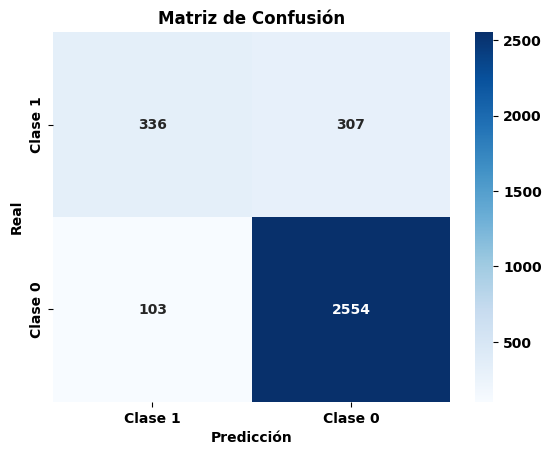

              precision    recall  f1-score   support

           0       0.89      0.96      0.93      2657
           1       0.77      0.52      0.62       643

    accuracy                           0.88      3300
   macro avg       0.83      0.74      0.77      3300
weighted avg       0.87      0.88      0.87      3300

ROC-AUC: 0.86


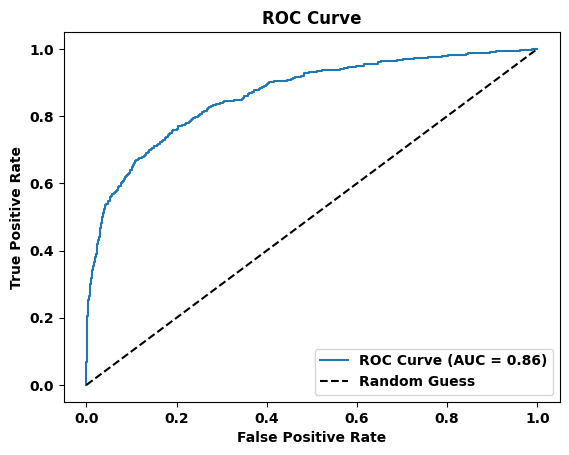

kappa: 0.5499070872501619 mcc: 0.5642382068865216


,Técnica,AUC,precision,recall,f1-score,accuracy,kappa,MCC
0,Decision Tree,0.788855,0.689055,0.430793,0.530144,0.851212,0.447285,0.464713
1,SVM,0.445897,0.000000,0.000000,0.000000,0.805152,0.000000,0.000000
2,SVM con datos escalados,0.831749,0.906667,0.211509,0.343001,0.842121,0.290718,0.392168
3,Naive Bayes,0.747892,0.379562,0.080871,0.133333,0.795152,0.069654,0.097056
4,KNN escalado,0.740626,0.562105,0.415241,0.477639,0.823030,0.373991,0.380207
5,Random Forest,0.852312,0.770992,0.471229,0.584942,0.869697,0.512941,0.534832
6,xGBoost,0.862894,0.776882,0.449456,0.569458,0.867576,0.497720,0.523777
7,LGBM,0.865205,0.741784,0.491446,0.591207,0.867576,0.516052,0.531631
8,CatBoost,0.873471,0.778870,0.493002,0.603810,0.873939,0.533315,0.553050
9,LGBM con GridSearch,0.867182,0.769231,0.482115,0.592734,0.870909,0.520784,0.540869


In [78]:
comparador.loc[len(comparador)] = metricas(y_test, lgbm04_pred, lgbm04_pred_proba, 'LGBM con Optuna optimizando kappa')
comparador

#### Visualizacion del modelo con optuna

In [79]:
!pip install nbformat>=4.2.0
import plotly.io as pio
# Esto abrirá el gráfico en una pestaña nueva del navegador 
# o lo incrustará de forma más sencilla
pio.renderers.default = "notebook_connected"

In [80]:
!pip install nbformat --upgrade

In [81]:
import optuna.visualization as vis

# Gráfico de optimización de la métrica objetivo
vis.plot_optimization_history(study)

In [82]:
vis.plot_param_importances(study)

In [83]:
vis.plot_slice(study)

#### 12. Explicabilidad

En muchas ocasiones probamos modelos que mejorar mucho las métricas (AUC, kappa,...) sin embargo se acaban convirtiendo en black-box es decir en este proceso perdemos explicabilidad.  
**XAI (Explainable AI)** es un conjunto de métodos y técnicas que buscan hacer los modelos de IA más interpretables y comprensibles para los humanos. Su objetivo es explicar cómo y por qué un modelo toma ciertas decisiones, lo que ayuda a generar confianza y mejorar la transparencia en aplicaciones de ML e IA.  
Existen técnicas de interpretabilidad y son a posteriori, es decir una vez hecho el modelo. LAs principales son: **Dalex, Shap, LIME.** 
 

In [86]:
!pip install dalex

   ---------------------------------------- 0.0/1.0 MB ? eta -:--:--
   -------------------- ------------------- 0.5/1.0 MB 3.4 MB/s eta 0:00:01
   ---------------------------------------- 1.0/1.0 MB 3.0 MB/s  0:00:00
   ---------------------------------------- 0.0/1.0 MB ? eta -:--:--
   ------------------------------- -------- 0.8/1.0 MB 5.1 MB/s eta 0:00:01
   ---------------------------------------- 1.0/1.0 MB 4.7 MB/s  0:00:00

   ---------------------------------------- 0/2 [setuptools]
   ---------------------------------------- 0/2 [setuptools]
   ---------------------------------------- 0/2 [setuptools]
   ---------------------------------------- 0/2 [setuptools]
   ---------------------------------------- 0/2 [setuptools]
   ---------------------------------------- 0/2 [setuptools]
   ---------------------------------------- 0/2 [setuptools]
   ---------------------------------------- 0/2 [setuptools]
   ---------------------------------------- 0/2 [setuptools]
   -----------

In [87]:
import dalex as dx

In [88]:
# Crear un objeto de explicabilidad con DALEX
explicador = dx.Explainer(LGBM, X, y, label="lgbm")

# Explicación de importancia de variables
importancia = explicador.model_parts(loss_function = 'rmse')

# Mostrar gráfico de importancia
importancia.plot()

Preparation of a new explainer is initiated

  -> data              : 10000 rows 13 cols
  -> target variable   : Parameter 'y' was a pandas.Series. Converted to a numpy.ndarray.
  -> target variable   : 10000 values
  -> model_class       : lightgbm.sklearn.LGBMClassifier (default)
  -> label             : lgbm
  -> predict function  : <function yhat_proba_default at 0x00000209AAB4A980> will be used (default)
  -> predict function  : Accepts pandas.DataFrame and numpy.ndarray.
  -> predicted values  : min = 0.0075, mean = 0.207, max = 0.984
  -> model type        : classification will be used (default)
  -> residual function : difference between y and yhat (default)
  -> residuals         : min = -0.939, mean = -0.00315, max = 0.982
  -> model_info        : package lightgbm

A new explainer has been created!


In [89]:
explicador.model_profile().plot(variables=['NumOfProducts', 'Balance',
                                          'Gender_Female', 'IsActiveMember'])


Calculating ceteris paribus: 100%|██████████| 13/13 [00:01<00:00, 12.00it/s]


**RowNumber:** The sequential number assigned to each row in the dataset.  
**CustomerId:** A unique identifier for each customer.  
**Surname:** The surname of the customer.  
**CreditScore:** The credit score of the customer.  
**Geography:** The geographical location of the customer (e.g., country or region).  
**Gender:** The gender of the customer.  
**Age:** The age of the customer.  
**Tenure:** The number of years the customer has been with the bank.  
**Balance:** The account balance of the customer.  
**NumOfProducts:** The number of bank products the customer has.  
**HasCrCard:** Indicates whether the customer has a credit card (binary: yes/no).  
**IsActiveMember:** Indicates whether the customer is an active member (binary: yes/no).  
**EstimatedSalary:** The estimated salary of the customer.  
**Exited:** Indicates whether the customer has exited the bank (binary: yes/no).  

In [90]:
explicador.predict_parts(X.loc[1], type='shap').plot()

In [ ]:
explicador.predict_parts(X.loc[1], type='break_down').plot()

In [92]:
explicador.predict_parts(X.loc[9999], type='break_down').plot()

In [93]:
explicador.predict_parts(X.loc[9998], type='break_down').plot() 

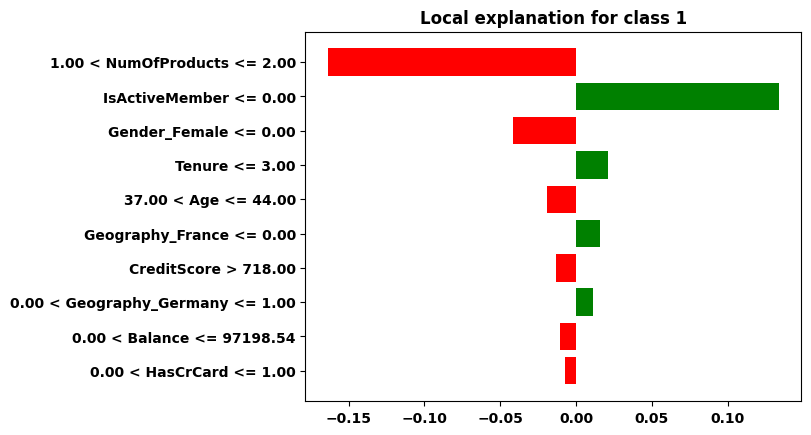

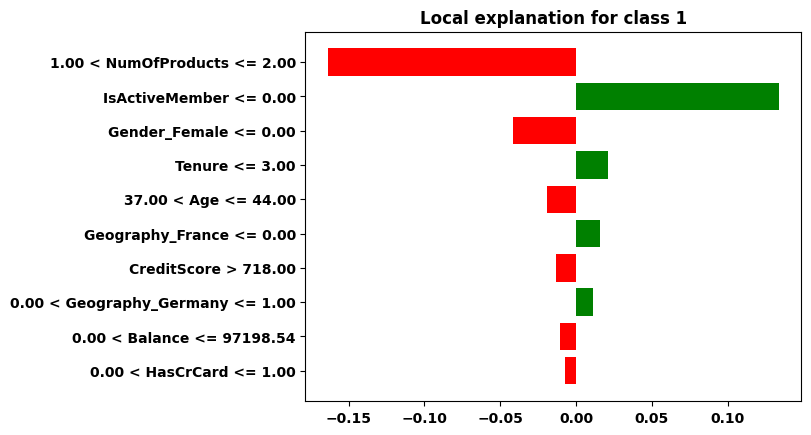

In [97]:
!pip install lime
surrogate_prediction = explicador.predict_surrogate(X.loc[9998], mode='classification')
surrogate_prediction.as_pyplot_figure()
# Mostrar el resultado


In [98]:
df

,CreditScore,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited,Geography_France,Geography_Germany,Geography_Spain,Gender_Female,Gender_Male
0,619,42,2,0.00,1,1,1,101348.88,1,1.0,0.0,0.0,1.0,0.0
1,608,41,1,83807.86,1,0,1,112542.58,0,0.0,0.0,1.0,1.0,0.0
2,502,42,8,159660.80,3,1,0,113931.57,1,1.0,0.0,0.0,1.0,0.0
3,699,39,1,0.00,2,0,0,93826.63,0,1.0,0.0,0.0,1.0,0.0
4,850,43,2,125510.82,1,1,1,79084.10,0,0.0,0.0,1.0,1.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
9995,771,39,5,0.00,2,1,0,96270.64,0,1.0,0.0,0.0,0.0,1.0
9996,516,35,10,57369.61,1,1,1,101699.77,0,1.0,0.0,0.0,0.0,1.0
9997,709,36,7,0.00,1,0,1,42085.58,1,1.0,0.0,0.0,1.0,0.0
9998,772,42,3,75075.31,2,1,0,92888.52,1,0.0,1.0,0.0,0.0,1.0


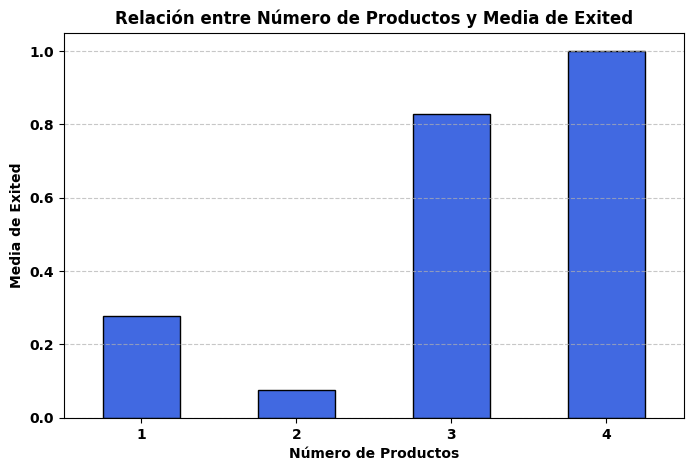

In [99]:
# Calcular la media de 'Exited' para cada número de productos
df_grouped = df.groupby('NumOfProducts')['Exited'].mean()

# Generar gráfico de barras
plt.figure(figsize=(8,5))
df_grouped.plot(kind='bar', color='royalblue', edgecolor='black')

# Personalización del gráfico
plt.xlabel("Número de Productos")
plt.ylabel("Media de Exited")
plt.title("Relación entre Número de Productos y Media de Exited")
plt.xticks(rotation=0)
plt.grid(axis='y', linestyle='--', alpha=0.7)

# Mostrar el gráfico
plt.show()

In [100]:
 df[df['NumOfProducts'] == 4]

,CreditScore,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited,Geography_France,Geography_Germany,Geography_Spain,Gender_Female,Gender_Male
7,376,29,4,115046.74,4,1,0,119346.88,1,0.0,1.0,0.0,1.0,0.0
70,738,58,2,133745.44,4,1,0,28373.86,1,0.0,1.0,0.0,0.0,1.0
1254,628,46,1,46870.43,4,1,0,31272.14,1,1.0,0.0,0.0,1.0,0.0
1469,819,49,1,120656.86,4,0,0,166164.30,1,0.0,1.0,0.0,1.0,0.0
1488,596,30,6,121345.88,4,1,0,41921.75,1,0.0,0.0,1.0,0.0,1.0
1701,792,50,9,0.00,4,1,1,194700.81,1,1.0,0.0,0.0,0.0,1.0
1876,640,39,9,131607.28,4,0,1,6981.43,1,0.0,1.0,0.0,0.0,1.0
2124,704,32,7,127785.17,4,0,0,184464.70,1,1.0,0.0,0.0,0.0,1.0
2196,773,47,2,118079.47,4,1,1,143007.49,1,0.0,1.0,0.0,0.0,1.0
2285,630,50,3,129370.91,4,1,1,47775.34,1,0.0,1.0,0.0,0.0,1.0
